In [1]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic (GPU/CPU) --
def get_system_info():
    if torch.cuda.is_available():
        return f"GPU: {torch.cuda.get_device_name(0)}"
    else:
        return f"CPU: {os.cpu_count()}"

get_system_info()

'CPU: 4'

In [2]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.auto import tqdm
import itertools

## -- Machine Learning --
import sklearn
from sklearn.base import clone
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, GroupKFold, train_test_split

from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import roc_auc_score, RocCurveDisplay, ConfusionMatrixDisplay

from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

In [3]:
try:
    import xgboost as xgb
    import lightgbm as lgb
    import catboost as cgb
except:
    !uv pip install -q -U xgboost lightgbm catboost
    import xgboost as xgb
    import lightgbm as lgb
    import catboost as cgb

In [4]:
## -- Global Settings --
# sklearn.set_config(transform_output='pandas')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
# sns.set_style("whitegrid")
# plt.style.use('ggplot')

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a', # Outer panel (figure)
    'axes.facecolor':   '#1a1a2e', # Inner panel (plot)
    'axes.edgecolor':   '#444466',
    'axes.labelcolor':  '#e0e0ff',
    'text.color':       'lightblue',
    'xtick.color':      '#e0e0ff',
    'ytick.color':      '#e0e0ff',
    'grid.color':       '#2a2a4a',
    'grid.alpha':       0.5,
    'font.family':      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RESET': '\033[0m'
}

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [5]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e8/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    # ORIG_PATH = '/kaggle/input/datasets/ziya07/college-student-health-behavior-dataset/'
    # orig = pd.read_csv(ORIG_PATH+'student_health_dataset_50k.csv')
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/-- shared_notebooks --/Ps6e8 | Phone Addiction/_phone_addiction_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')
    # orig = pd.read_csv(PATH+'student_health_dataset_50k.csv')

## =================================================================================

ID      = 'id'
TARGET  = 'addicted_label'
OBJECTS = train.select_dtypes(include=['object', 'category']).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

for (name, df) in {'Train': train, 'Test': test}.items(): # , 'Orig': orig
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (691369, 14)
Test shape: (296302, 13)

Total Numerical: 9
Total Categorical: 3
Total base features: 12


In [6]:
# ## -- Check if id is unique --
# print(f"Train ID column is unique: {train.id.is_unique}")
# print(f"Test  ID column is unique: {test.id.is_unique}")

In [7]:
display(train.head())
train.info()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [8]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,691369.0,345684.000000,199581.183466,0.00,172842.00,345684.00,518526.00,691368.00
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


In [9]:
train.describe(exclude=np.number).T

,count,unique,top,freq
gender,662335,3,Male,223662
stress_level,636221,3,High,220873
academic_work_impact,647145,2,Yes,330566


In [10]:
display(test.head())
test.info()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,691369,30.0,9.34,NaN,0.77,4.09,7.15,153.0,16.0,NaN,Other,Medium,Yes
1,691370,NaN,NaN,1.91,NaN,1.20,8.67,239.0,148.0,10.68,Female,High,No
2,691371,26.0,8.48,3.64,NaN,3.39,7.47,106.0,123.0,NaN,Male,NaN,No
3,691372,20.0,8.37,2.99,1.69,2.53,5.45,178.0,55.0,9.88,Male,High,Yes
4,691373,25.0,8.25,4.02,1.21,2.32,8.46,63.0,86.0,10.72,Male,Low,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296302 entries, 0 to 296301
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       296302 non-null  int64  
 1   age                      279164 non-null  float64
 2   daily_screen_time_hours  263514 non-null  float64
 3   social_media_hours       248905 non-null  float64
 4   gaming_hours             236882 non-null  float64
 5   work_study_hours         268525 non-null  float64
 6   sleep_hours              273847 non-null  float64
 7   notifications_per_day    262081 non-null  float64
 8   app_opens_per_day        270597 non-null  float64
 9   weekend_screen_time      245605 non-null  float64
 10  gender                   282090 non-null  object 
 11  stress_level             276676 non-null  object 
 12  academic_work_impact     270581 non-null  object 
dtypes: float64(9), int64(1), object(3)
memory usage: 29.4+ MB


In [11]:
# display(orig.head())
# orig.info()

In [12]:
# # Check if column names are the same regardless of order
# are_same_set = set(train.columns) == set(orig.columns)
# print(f"Are column names the same regardless of order (train vs orig)? {are_same_set}")

# # Check if column names are the same and in the same order
# are_same_exact = train.columns.equals(orig.columns)
# print(f"Are column names exactly the same and in the same order (train vs orig)? {are_same_exact}")

In [13]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    # ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         # pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.T.style.background_gradient()

,Train,Test
age,18,18
daily_screen_time_hours,1389,1349
social_media_hours,721,703
gaming_hours,401,401
work_study_hours,600,601
sleep_hours,451,451
notifications_per_day,231,231
app_opens_per_day,166,166
weekend_screen_time,1437,1404
gender,3,3


In [14]:
def get_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        class_weights = opt
        sample_weights = np.array([class_weights[label] for label in y])
        return sample_weights
    else:
        classes_ = np.unique(y_true)
        weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
        class_weights = dict(zip(classes_, weights_))
        sample_weights = np.array([class_weights[label] for label in y])
        return sample_weights

print('- Helper Functions Ready -')

- Helper Functions Ready -


### YDATA-PROFILE REPORT

In [15]:
# # %%capture
# ## -- Comprehensive EDA --
# !{sys.executable} -m pip install -qq -U ydata-profiling[notebook]
# !pip install -qq jupyter-contrib-nbextensions
# !jupyter nbextension enable --py widgetsnbextension

In [16]:
# from ydata_profiling import ProfileReport, compare

# ## -- Single EDA --
# # profile_df = ProfileReport(train, title="Insights into TARGET Types", explorative=True)
# # profile_df.to_notebook_iframe()

# # profile_df.to_file("Loan_EDA_Report.html")

# ## -- Create Profiles for Datasets --
# train_report = ProfileReport(train, title="Train", explorative=True)
# # test_report = ProfileReport(test, title="Test", explorative=True)
# orig_report = ProfileReport(orig, title="Original", explorative=True)

# ## -- Compare 2++ Datasets --
# comparison_report = compare([train_report, test_report])

# # ## -- Obtain merged statistics (Don't know its purpose yet)
# # statistics = comparison_report.get_description()
# ## -- Save report to file
# comparison_report.to_file("Student Test Scores | Train-Orig_Stats.html")
# comparison_report.to_notebook_iframe()

# EDA

## ~ NUMERIC

In [17]:
# ## -- PLOT TARGET DISTRIBUTION --
# # plt.figure(figsize=(16, 6))
# _, axs = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={'width_ratios':[0.7, 0.3], 'wspace':0.1})

# ## -- KDEs --
# sns.kdeplot(data=train, x=TARGET, color=PALETTE[0], linewidth=2, ax=axs[0], label='Train')
# sns.kdeplot(data=orig, x=TARGET, color=PALETTE[1], linewidth=2, ax=axs[0], label='Original')
# axs[0].legend()
# axs[0].set_xlabel('')

# # Boxplots
# # pd.concat([train[[TARGET]], orig[[TARGET]]], axis=1).boxplot(
# #     widths=0.6,
# #     showmeans=True,
# #     # meanline=True,
# #     # patch_artist=True,
# #     # notch=True,
# #     # labels=['Train', 'Original'],
# #     ax=axs[1])

# sns.violinplot(
#     data=[train[TARGET].values, orig[TARGET].values],
#     inner='quart',
#     width=0.6,
#     # size=1,
#     # width=0.6,
#     # linewidth=2,
#     # fliersize=.1,
#     ax=axs[1],
#     palette=PALETTE)

# axs[1].set_xticklabels(['Train', 'Original'], fontdict={'weight': 'bold'})

# plt.suptitle(f"- Target '{TARGET}' distribution -", fontsize=15, fontweight='bold')
# plt.tight_layout()
# plt.show()

In [18]:
def distplots_data(train=None, test=None, orig=None, features=None):
    # 1) Concatenate data
    df = pd.concat([
            train[features].assign(Source='Train'),
            test[features].assign(Source='Test'),
            # orig[features].assign(Source='Original') if orig is not None else None,
    ], ignore_index=True)

    for i, col in enumerate(features):
        _, axs = plt.subplots(1, 2, figsize=(18, 5),
            gridspec_kw={'hspace': 0.3, 'wspace': 0.15, 'width_ratios': [0.7, 0.3]},
        )
        ## -- KDE plots --
        # if train is not None:
        sns.kdeplot(data=train, x=col, linewidth=2, ax=axs[0], label='Train')
        # elif test is not None:
        sns.kdeplot(data=test, x=col, linewidth=2, ax=axs[0], label='Test')
        # elif orig is not None:
        # sns.kdeplot(data=orig, x=col, linewidth=2, ax=axs[0], label='Orig')

        axs[0].set_title(f'{col}', fontdict={'size': 15, 'weight': 'bold'})
        axs[0].set(xlabel='')
        axs[0].legend()

        ## -- BOX plots --
        sns.boxplot(data=df, y=col, x='Source', linecolor='white',
                     width=0.5, linewidth=1, ax=axs[1], palette=PALETTE)
        axs[1].set(xlabel='')
        axs[1].tick_params(axis='both', which='major')
        axs[1].set_xticklabels(['Train', 'Test', 'Original'], fontweight='semibold')

        # for ax in axs:
        #     ax.grid(axis='y')

        plt.tight_layout()
        plt.show()
        print()

print('✓ Numerical grid plot function ready!')

✓ Numerical grid plot function ready!


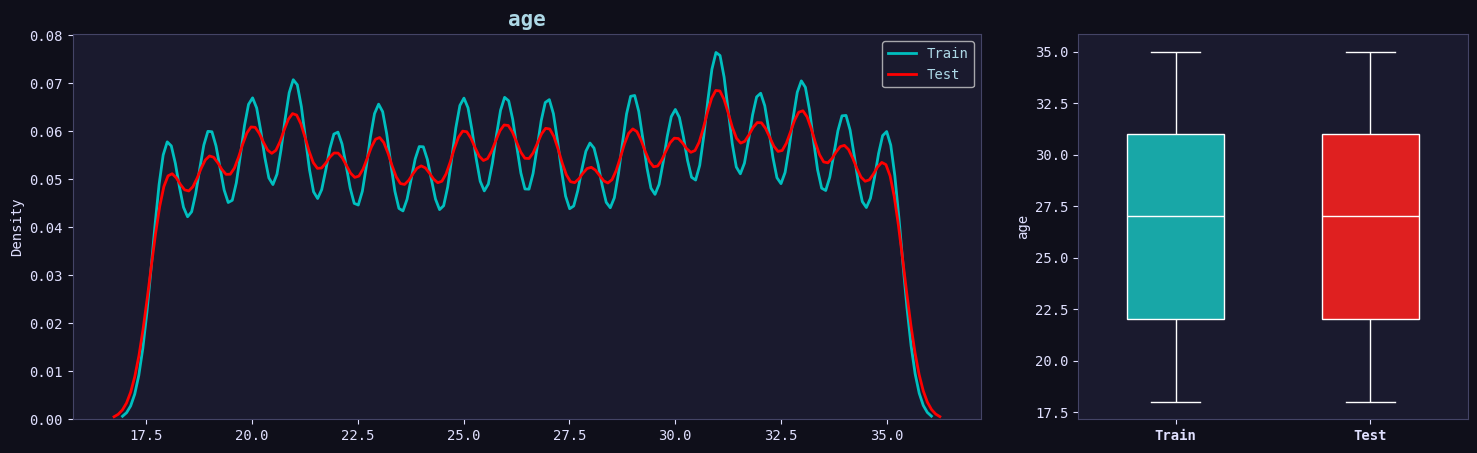

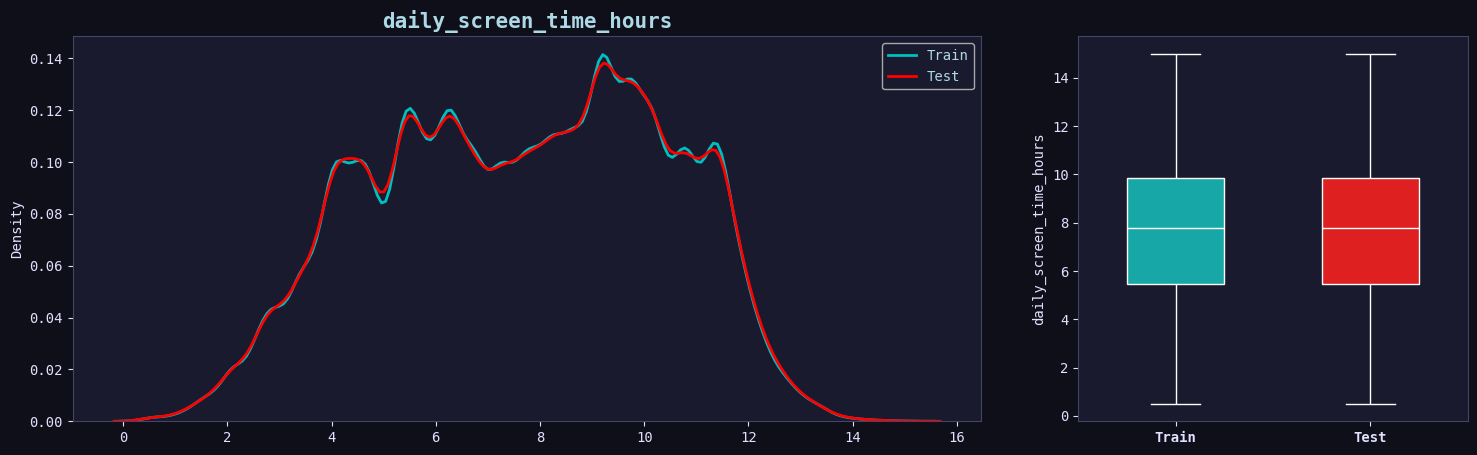

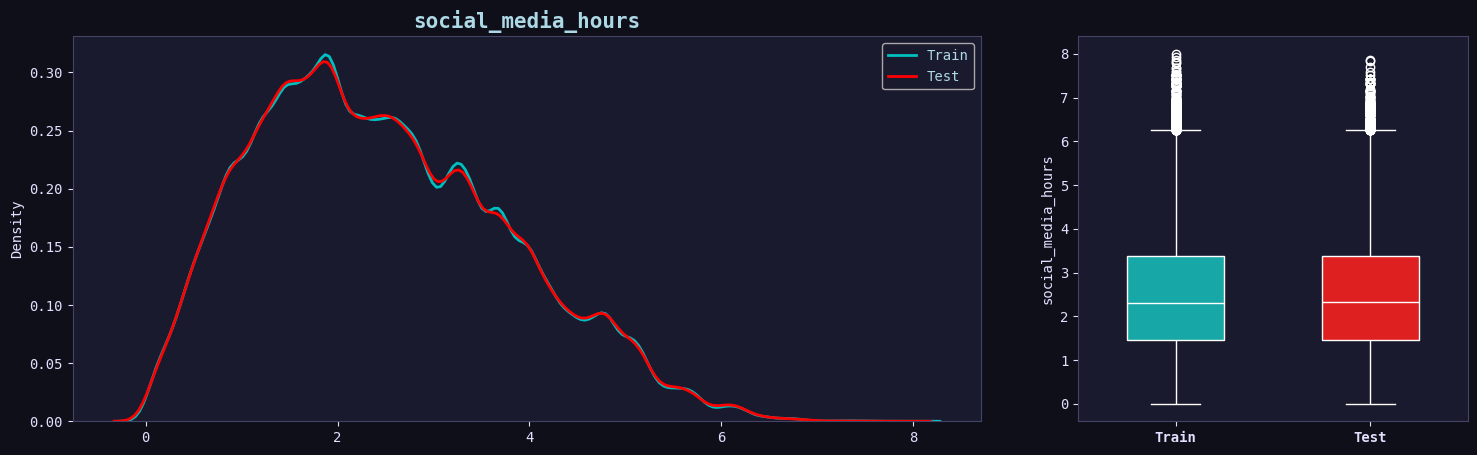

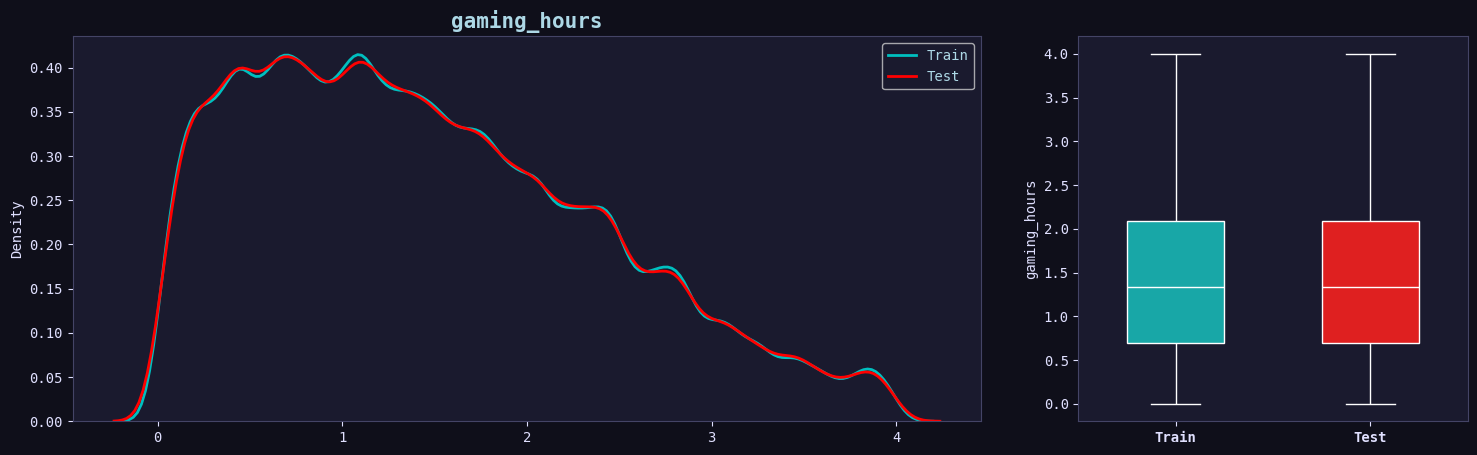

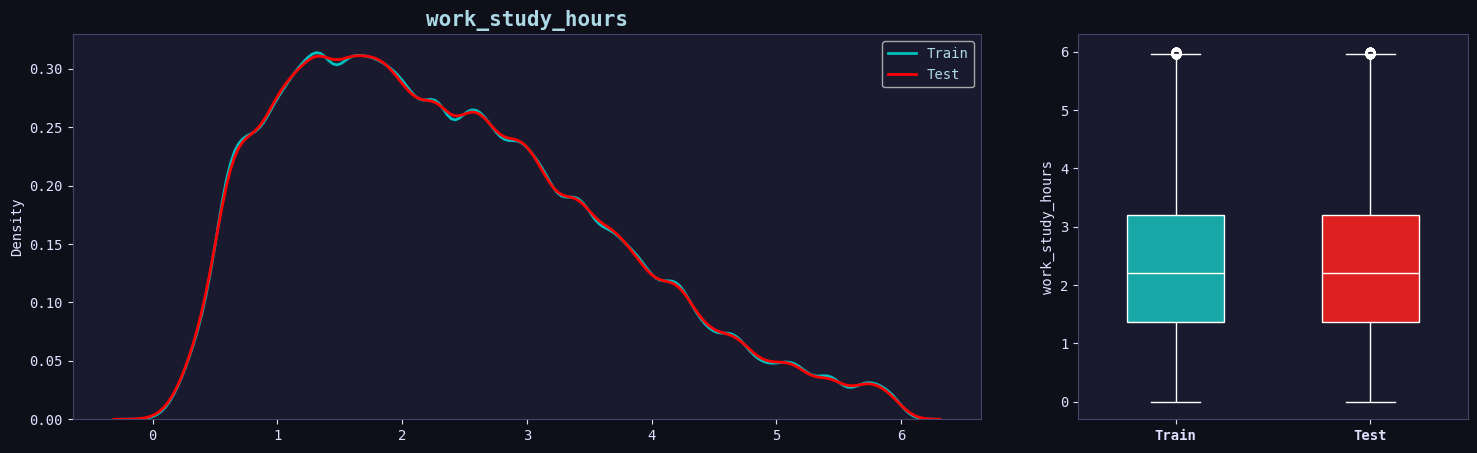

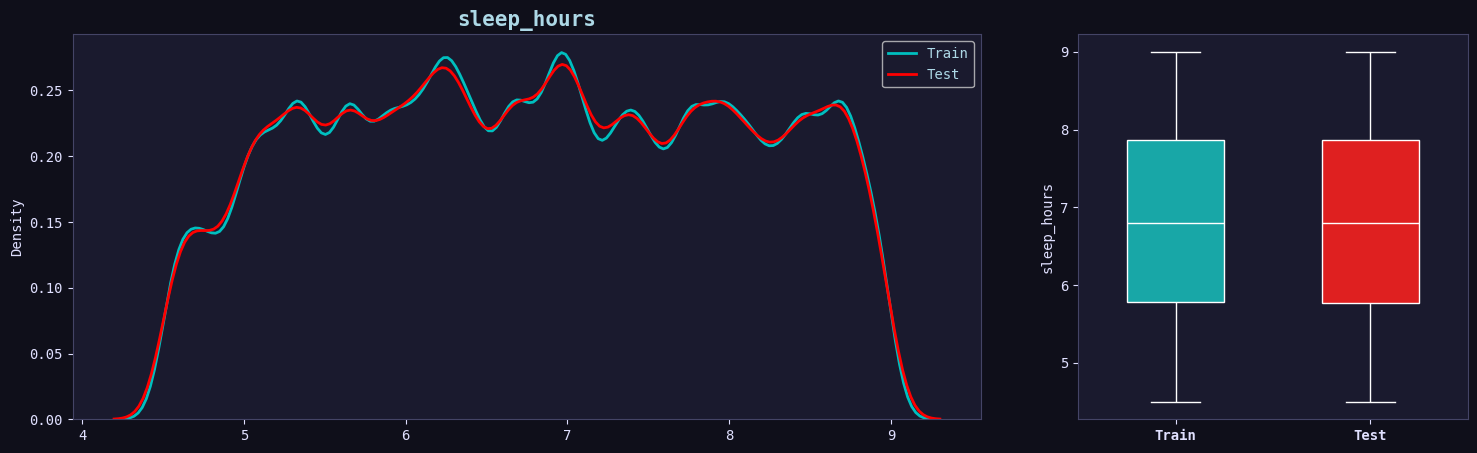

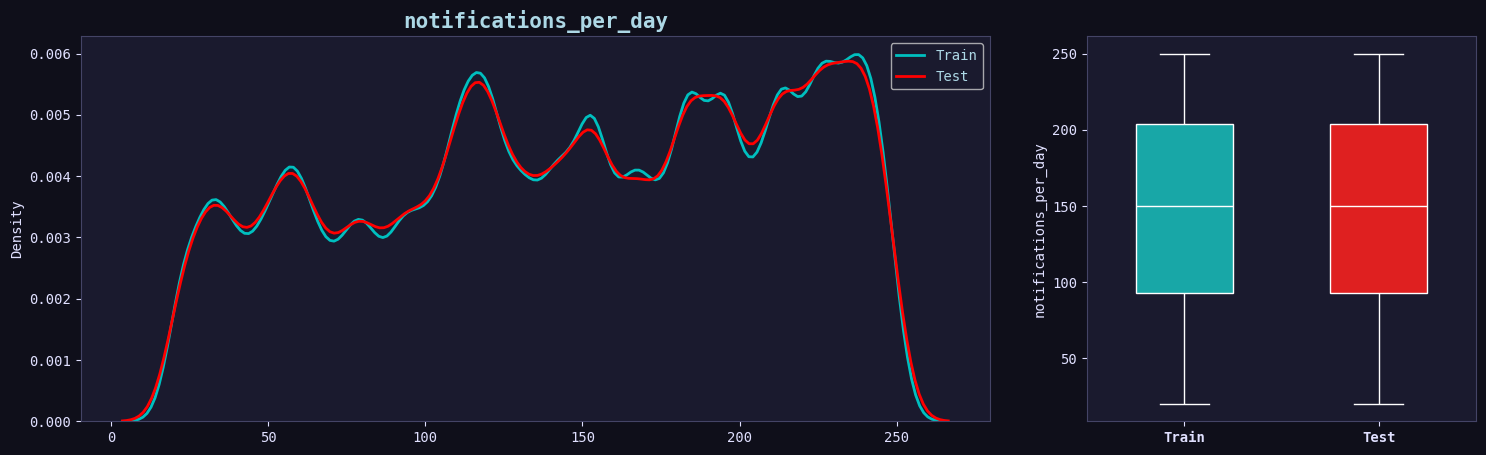

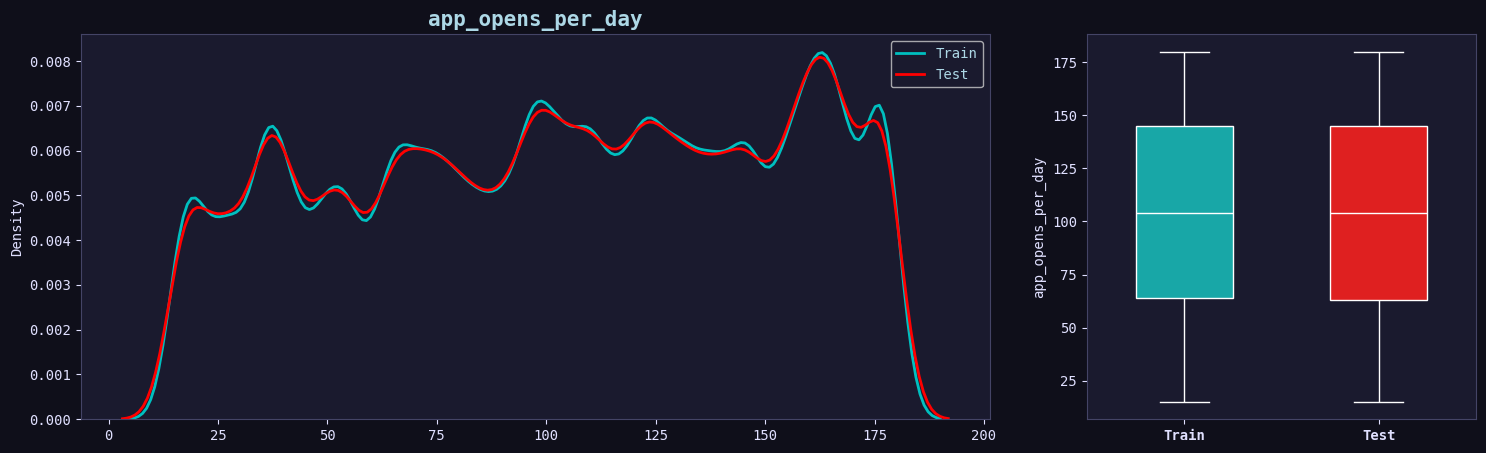

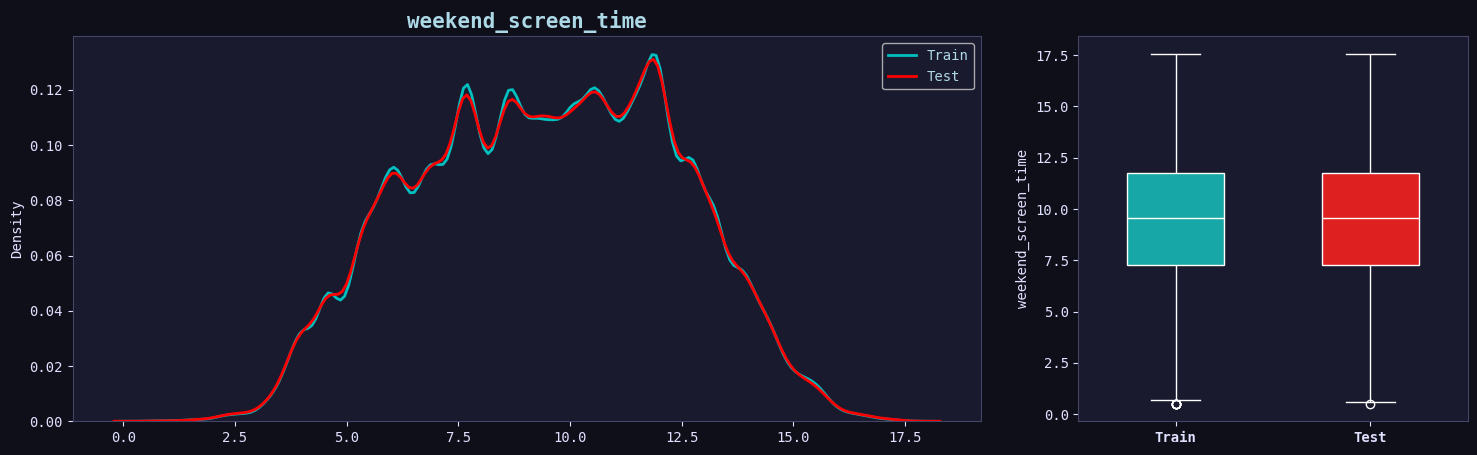

In [19]:
num_distplots = distplots_data(train=train, test=test, features=NUMS) # orig=orig

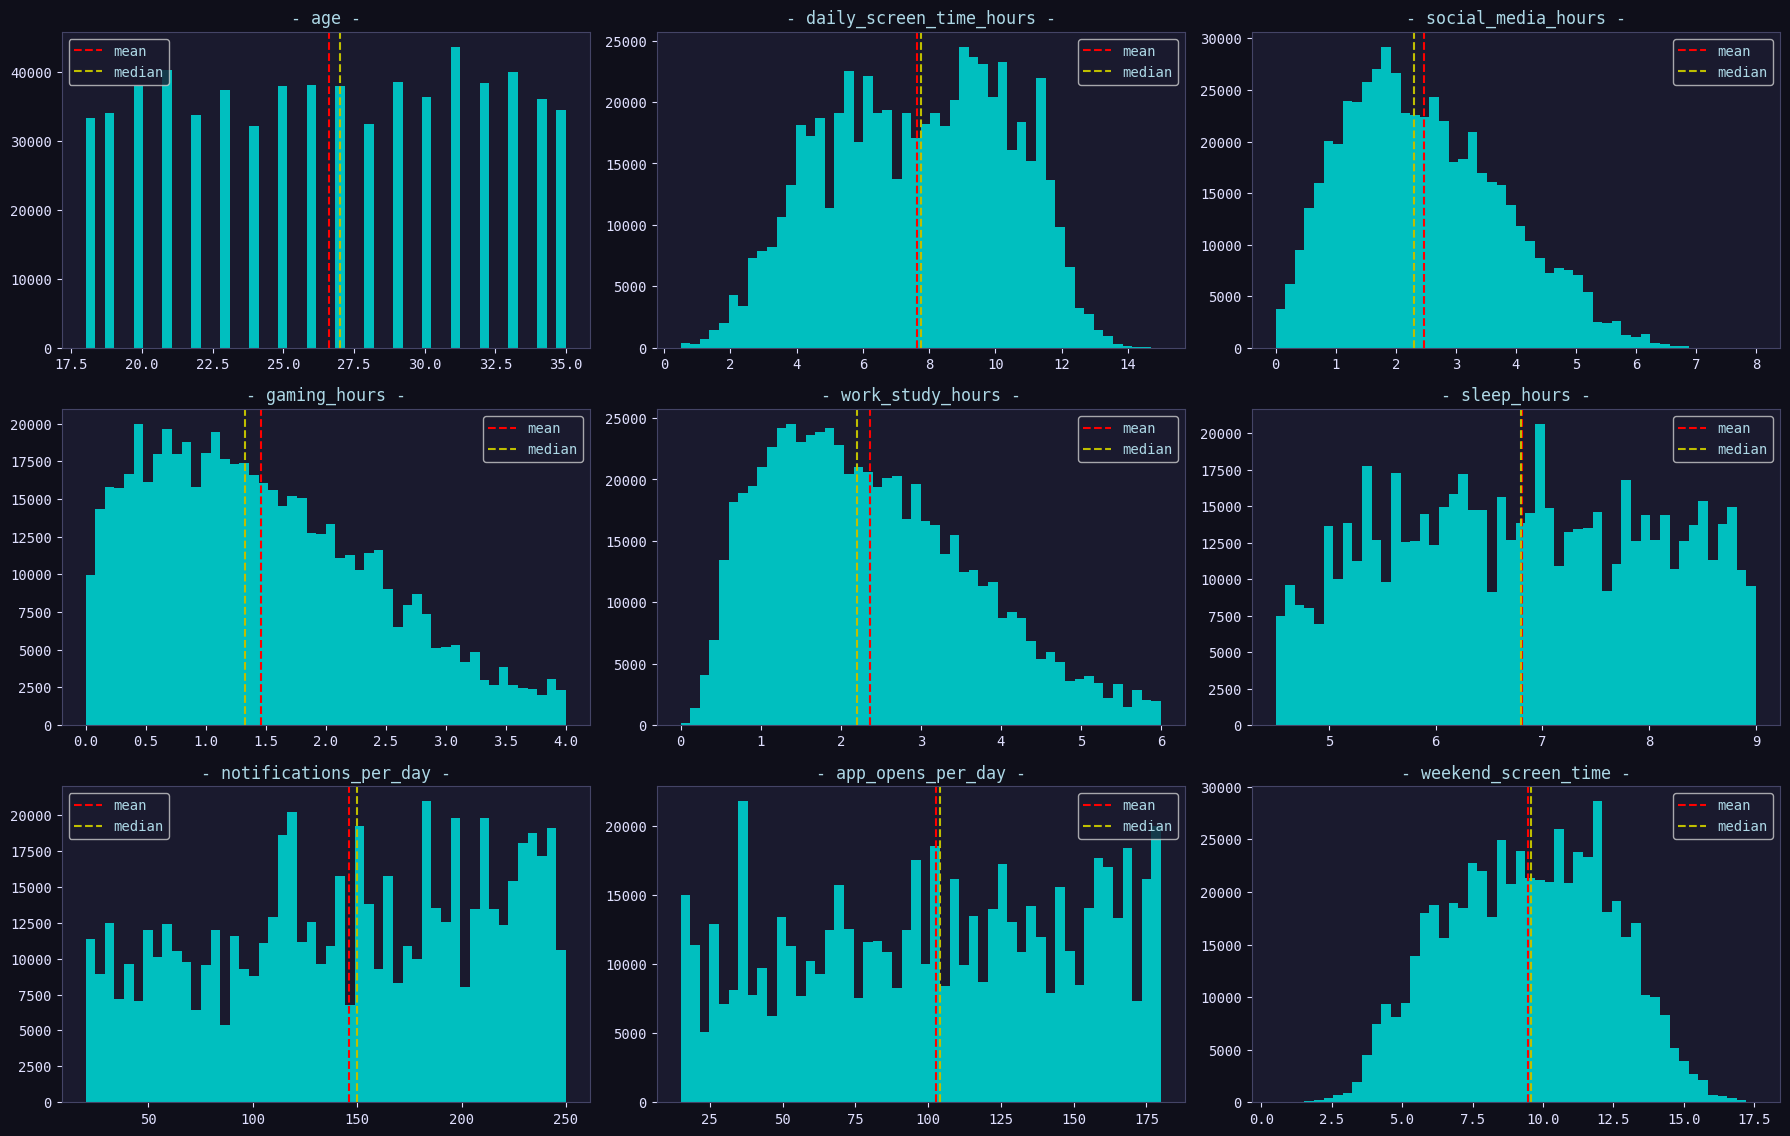

In [20]:
plt.figure(figsize=(18, 15))
for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='y', linestyle='--', label='median')
    plt.title(f'- {col} -')
    plt.legend()

plt.tight_layout()
plt.show()

## ~ CATEGORICAL

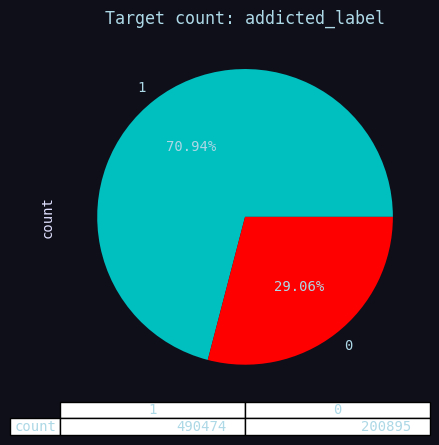

In [21]:
## -- Target count --
pie_target = train[TARGET].value_counts(dropna=False)
ax1 = pie_target.plot.pie(autopct='%1.2f%%', table=True)
ax1.set_title(f"Target count: {TARGET}")
plt.show()

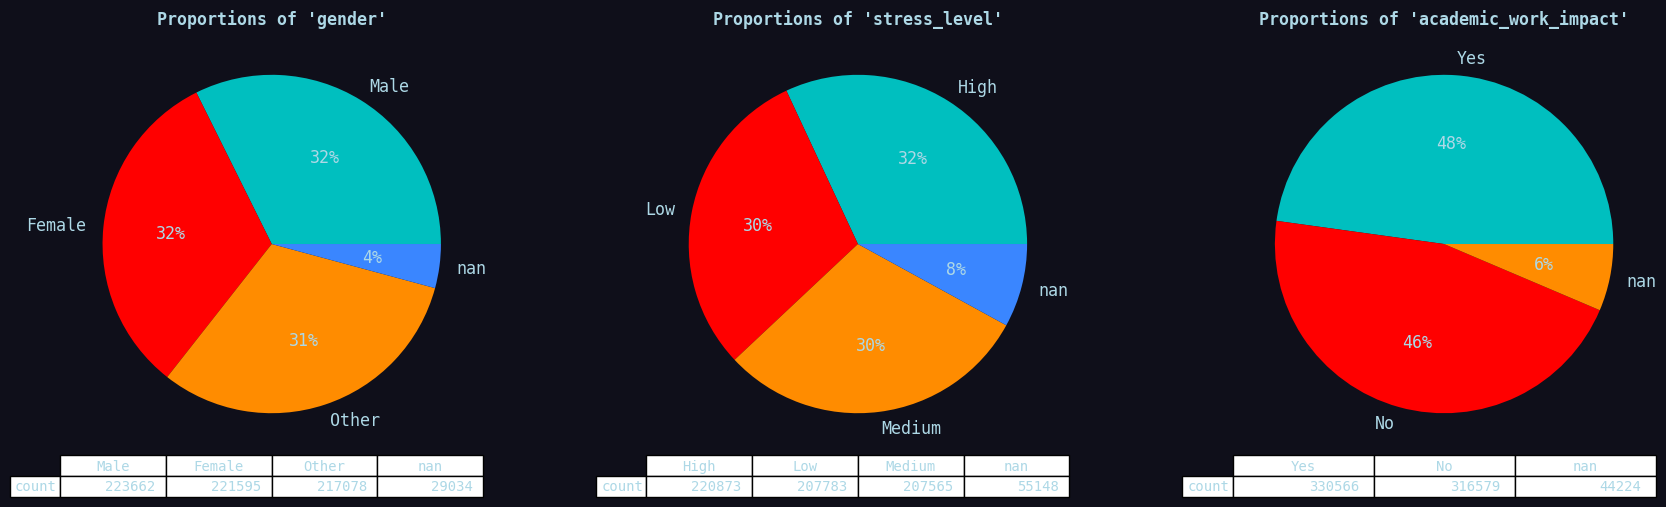

In [22]:
## -- Categorical Features --
plt.figure(figsize=(18, 15))
# for i, col in enumerate([c for c in BASE if train[c].nunique() <= 20]):
for i, col in enumerate(CATS):
    plt.subplot(3, 3, i+1)
    values=train[col].value_counts(dropna=False)
    values.plot.pie(autopct='%1.0f%%', fontsize=12, table=True)
    plt.title(f"Proportions of '{col}'", fontdict={'size':12, 'weight': 'bold'})
    plt.axis('off')

plt.tight_layout(h_pad=4.0, w_pad=0.25)
plt.show()

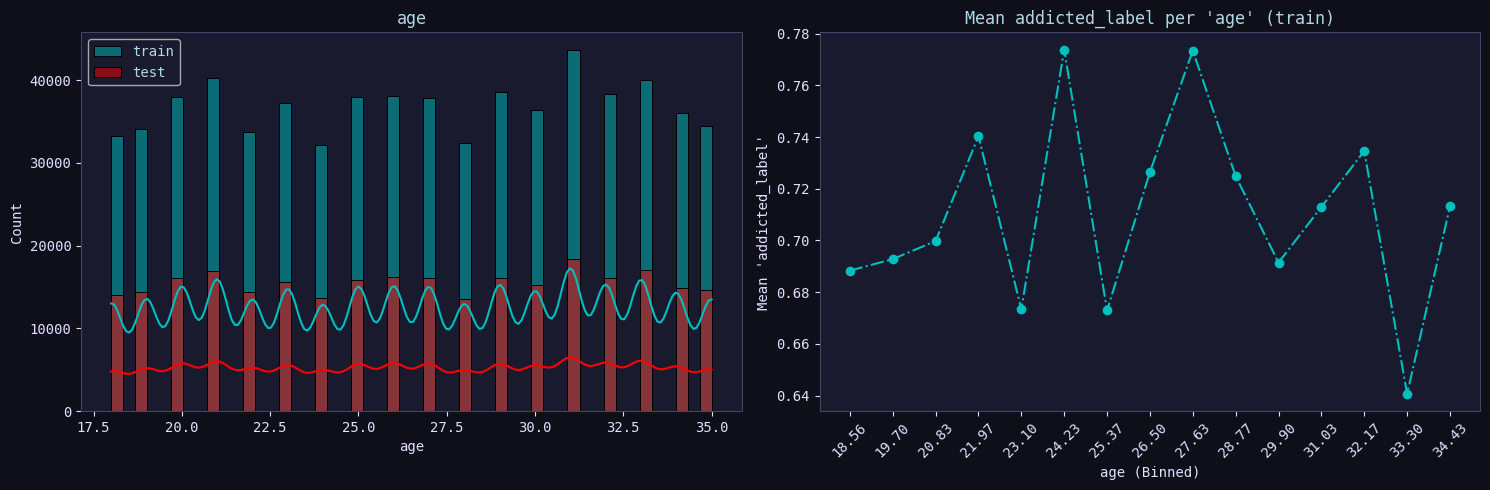

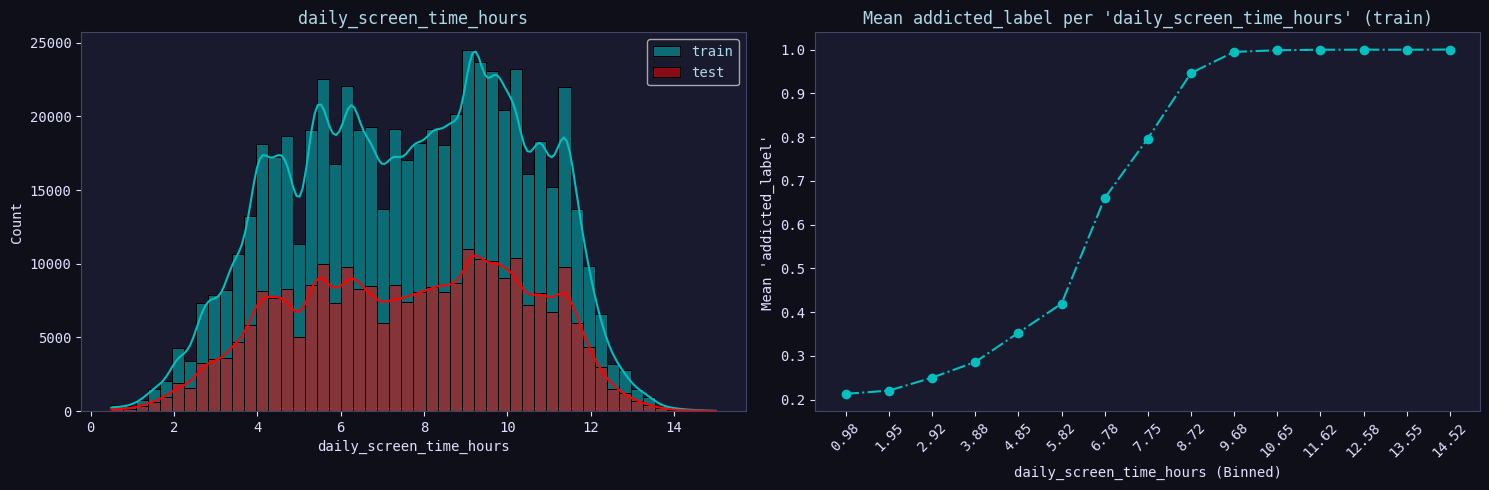

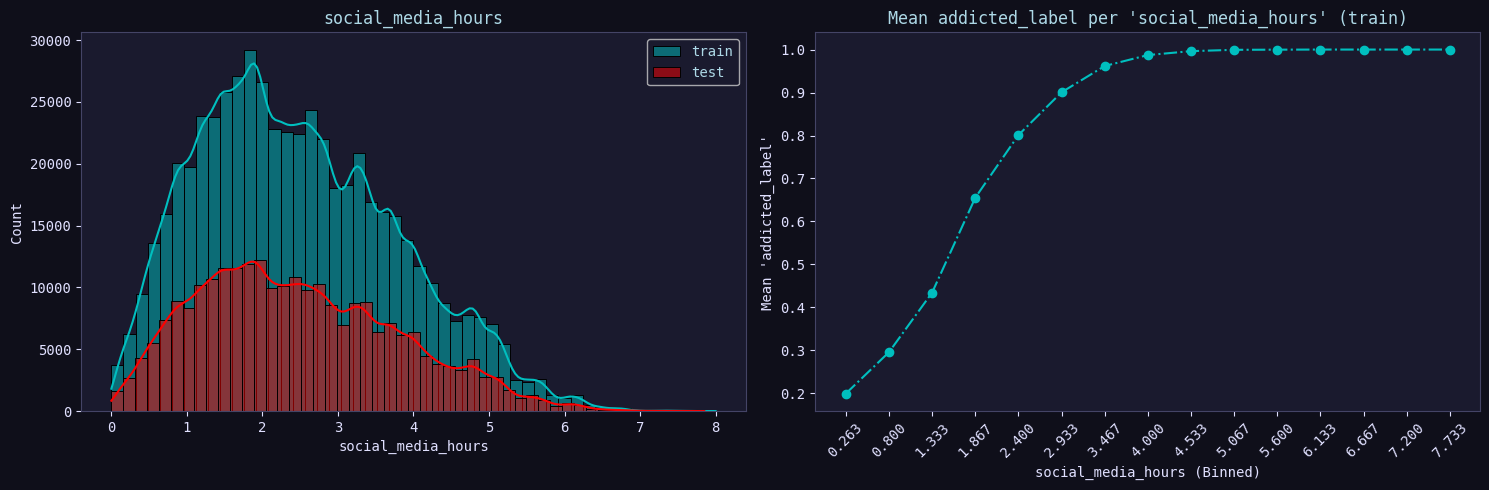

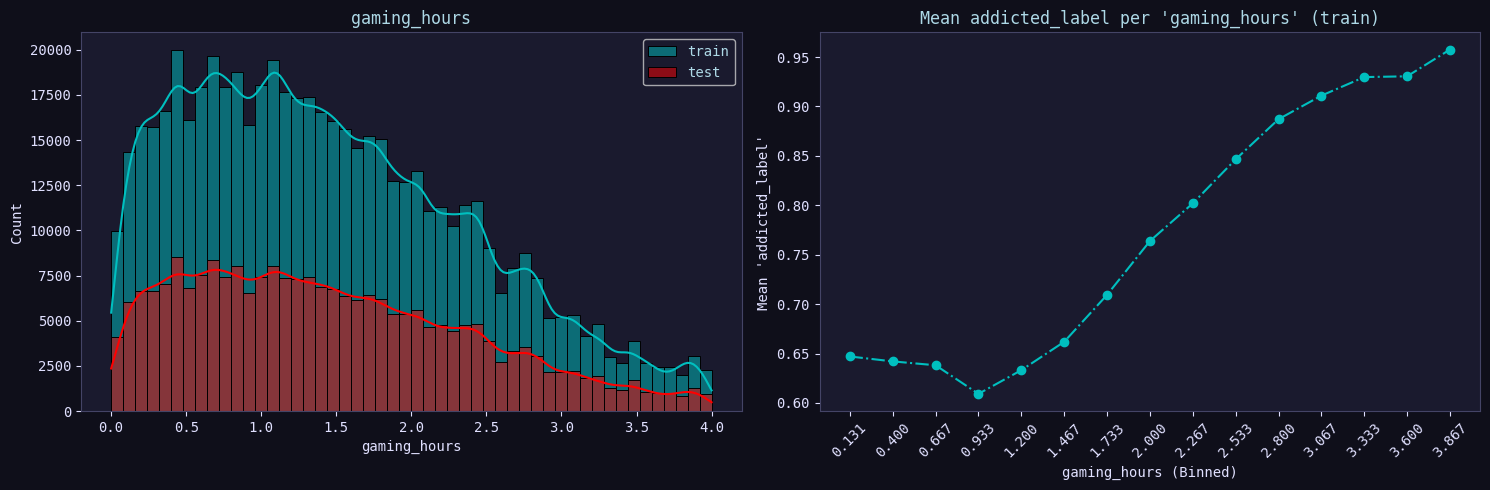

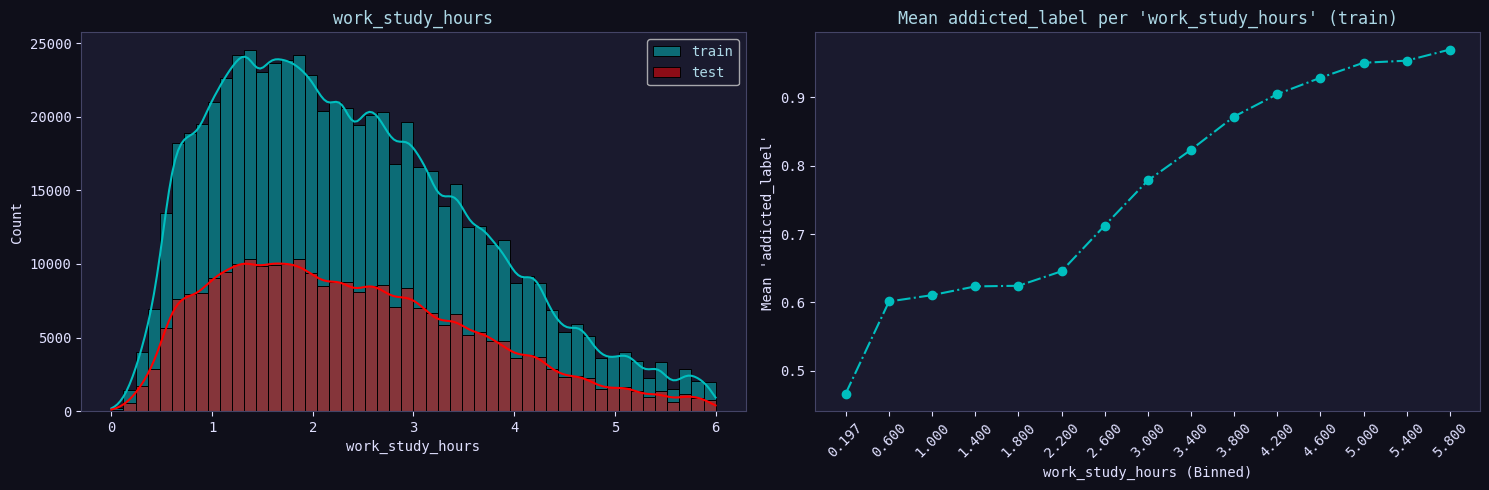

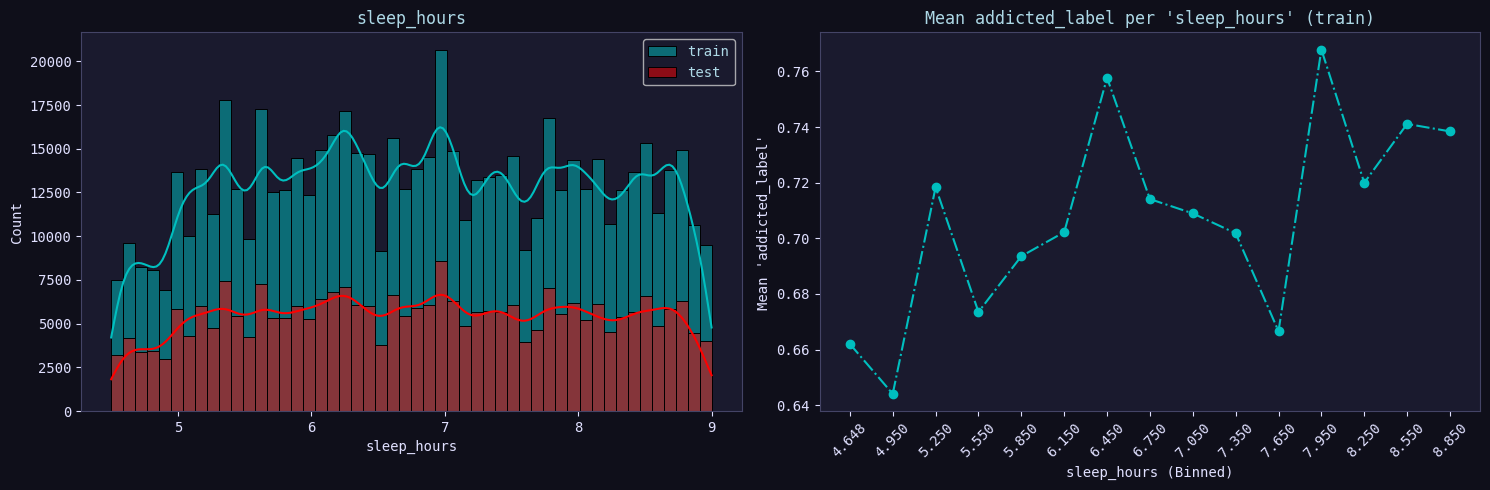

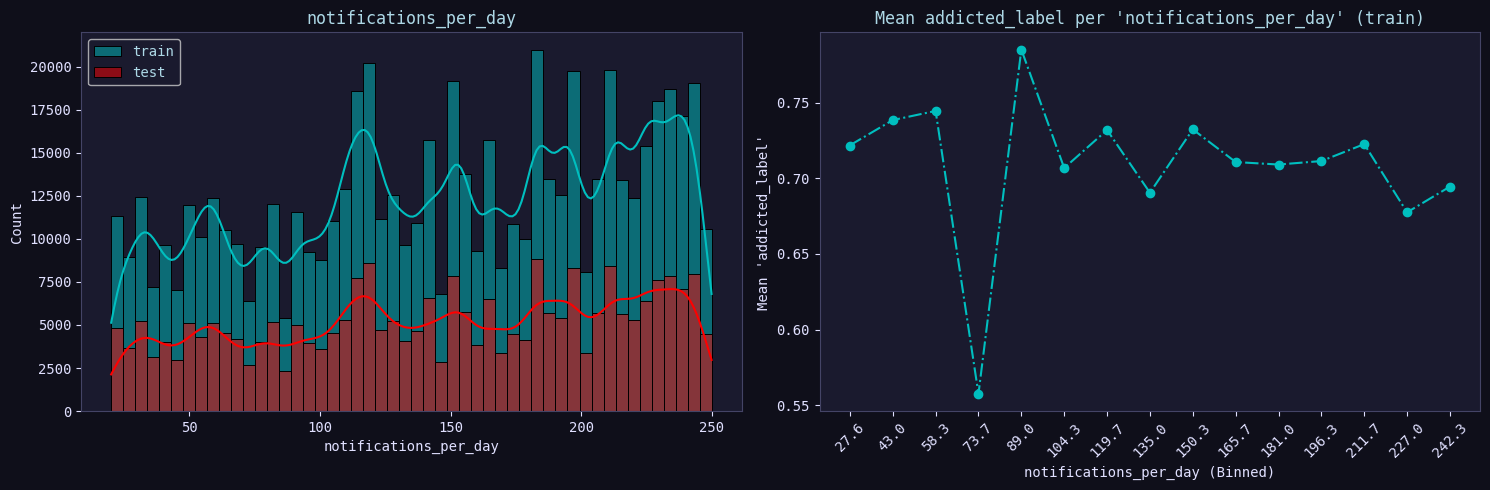

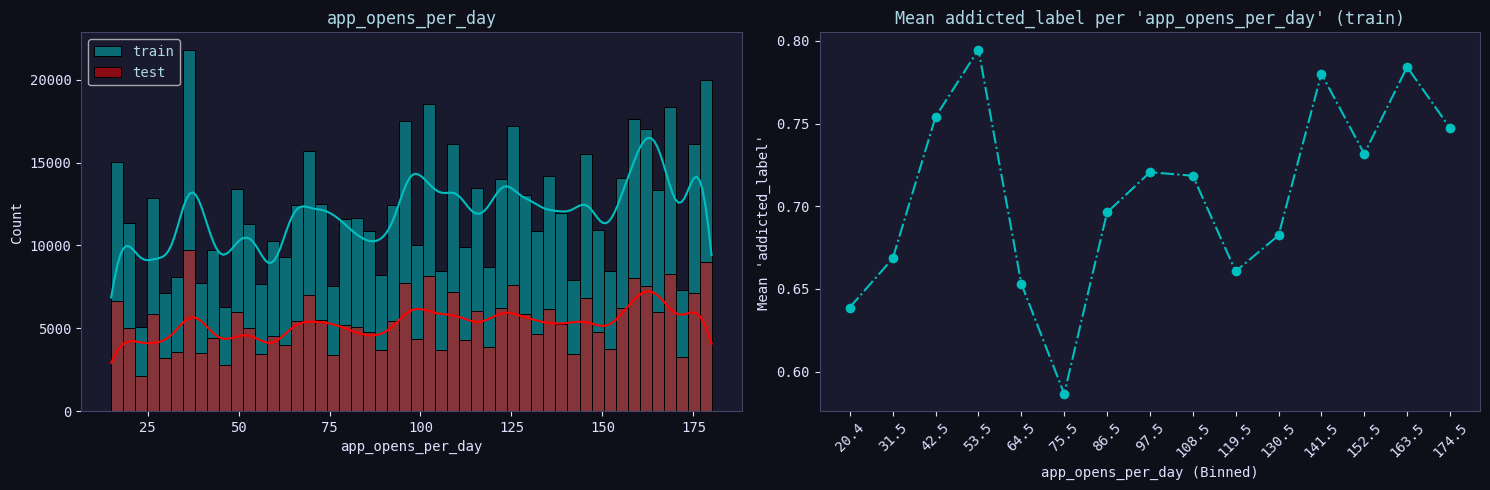

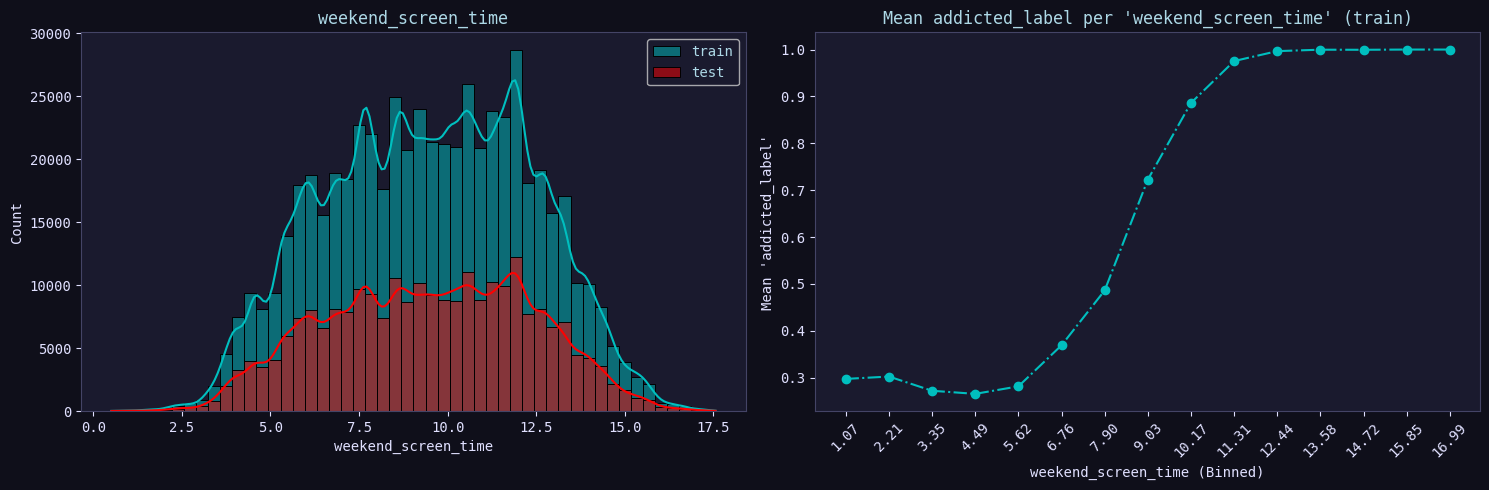

In [23]:
BINS = 15

for c in NUMS: #, 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation']:
    # Plot 'train' & 'test' distributions
    plt.figure(figsize=(15, 5))
    plt.subplot(121)
    sns.histplot(train[c], kde=True, bins=50, label='train')
    sns.histplot(test[c], kde=True, bins=50, label='test')
    plt.legend()
    plt.title(f"{c}")
    # plt.xticks('')
    ## -- Plot relationship between 'target' and bins
    plt.subplot(122)
    train['bucket'], edges = pd.cut(train[c],bins=BINS,include_lowest=True,retbins=True,labels=False)
    # train['bucket'], edges = pd.qcut(train[c],q=BINS,retbins=True,labels=False)
    bucket_means = train.groupby('bucket')[TARGET].mean()
    bin_midpoints = (edges[:-1] + edges[1:]) / 2
    plt.plot(bin_midpoints, bucket_means, marker='o',linestyle='-.',color='c')
    plt.xlabel(f'{c} (Binned)')
    plt.ylabel(f"Mean '{TARGET}'")
    plt.title(f"Mean {TARGET} per '{c}' (train)")
    plt.xticks(bin_midpoints, rotation=45)

    plt.tight_layout()
    plt.show()

train.drop(['bucket'], axis=1, inplace=True)

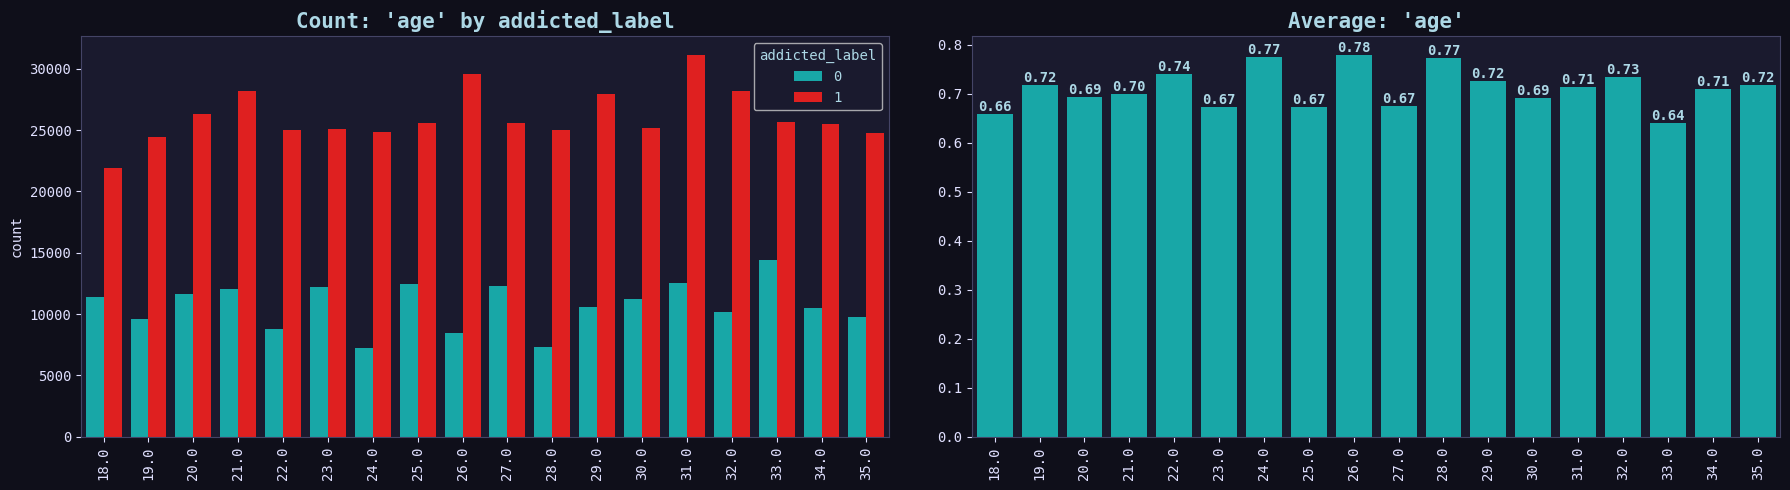

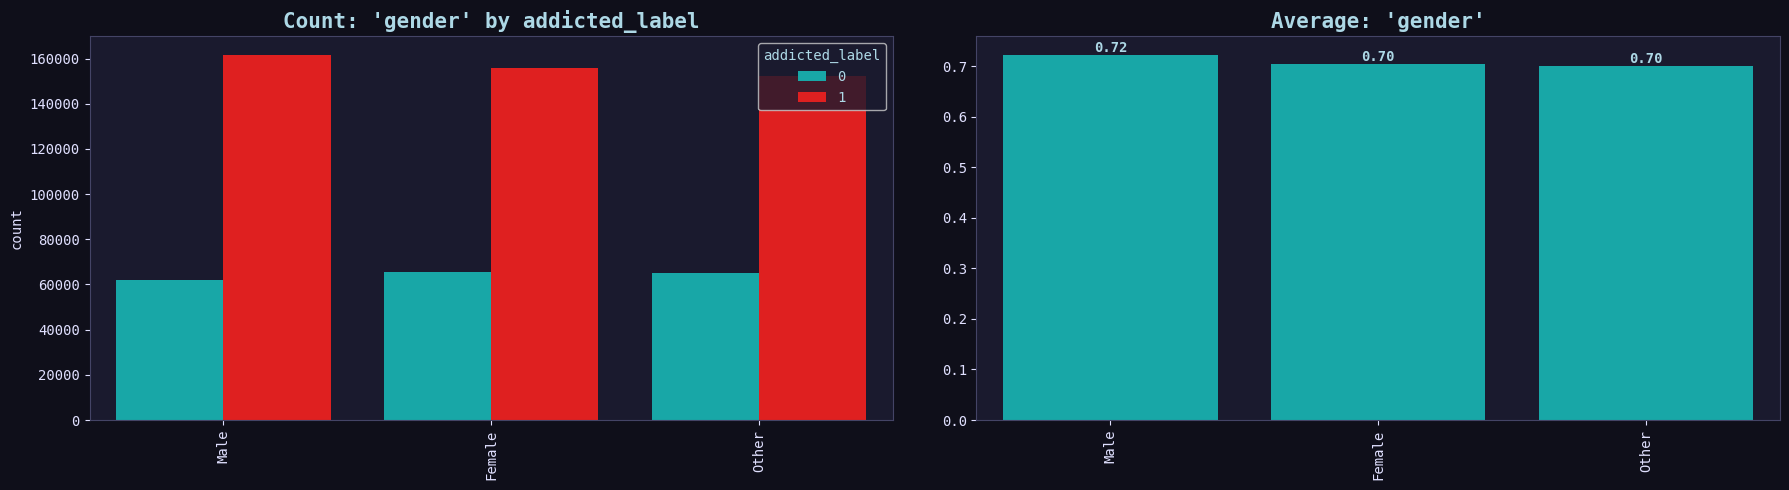

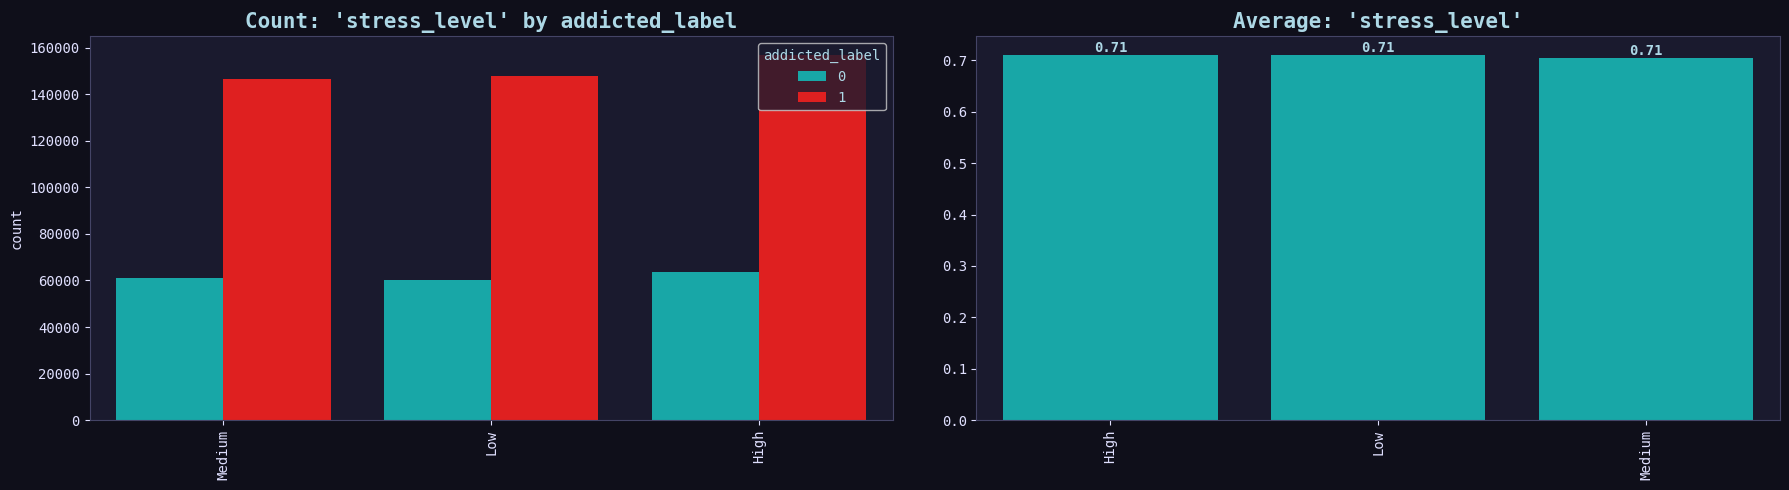

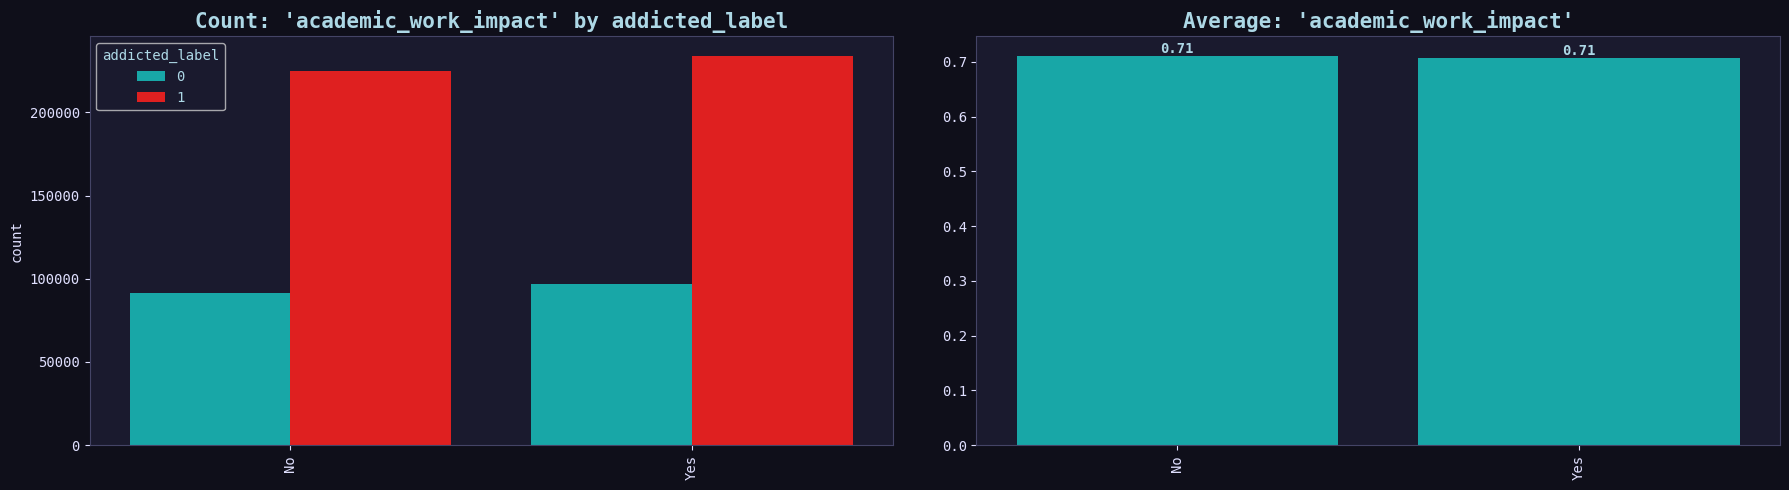

In [24]:
## -- Categorical Features: Counts and Mean by TARGET --
## -- Features with unique count <= 100
CATS_100 = [c for c in BASE if train[c].nunique() <= 20]

for i, c in enumerate(CATS_100):
    fig, axs = plt.subplots(1, 2, figsize=(18, 5))

    sns.countplot(train, x=c, hue=TARGET, ax=axs[0])
    axs[0].set_title(f"Count: '{c}' by {TARGET}", fontdict={'size': 15, 'weight': 'semibold'})
    axs[0].set_xlabel('')
    axs[0].tick_params(axis='x', rotation=90)

    v_mean = train.groupby(c)[TARGET].mean().sort_values(ascending=False)
    sns.barplot(x=v_mean.index, y=v_mean.values, ax=axs[1])
    axs[1].set_title(f"Average: '{c}'", fontdict={'size': 15, 'weight': 'semibold'})
    axs[1].set_xlabel('')
    axs[1].tick_params(axis='x', rotation=90)

    for container in axs[1].containers: # Display values on bars
        axs[1].bar_label(container, fmt='%.2f', fontsize=10, fontweight='semibold')


    _ = fig.tight_layout(w_pad=3.5)
    plt.show()
    print()

## ~ PAIRWISE (CATEGORICAL) ANALYSIS

In [25]:
n_unique = train[BASE].nunique().sort_values()
n_unique

academic_work_impact          2
gender                        3
stress_level                  3
age                          18
app_opens_per_day           166
notifications_per_day       231
gaming_hours                401
sleep_hours                 451
work_study_hours            600
social_media_hours          721
daily_screen_time_hours    1389
weekend_screen_time        1437
dtype: int64

In [26]:
# if train[combo[0]].nunique() > train[combo[1]].nunique():
#     print(f'a: {combo[0]} has more nunique values than b: {combo[1]}')
#     combo = [combo[0], combo[0]]
#     print(combo)
# else:
#     print(f'b: {combo[1]} has more nunique values than a: {combo[0]}')
#     combo = [combo[1], combo[0]]
#     print(combo)

('academic_work_impact', 'gender')| gender has more unique variables | ['gender', 'academic_work_impact']


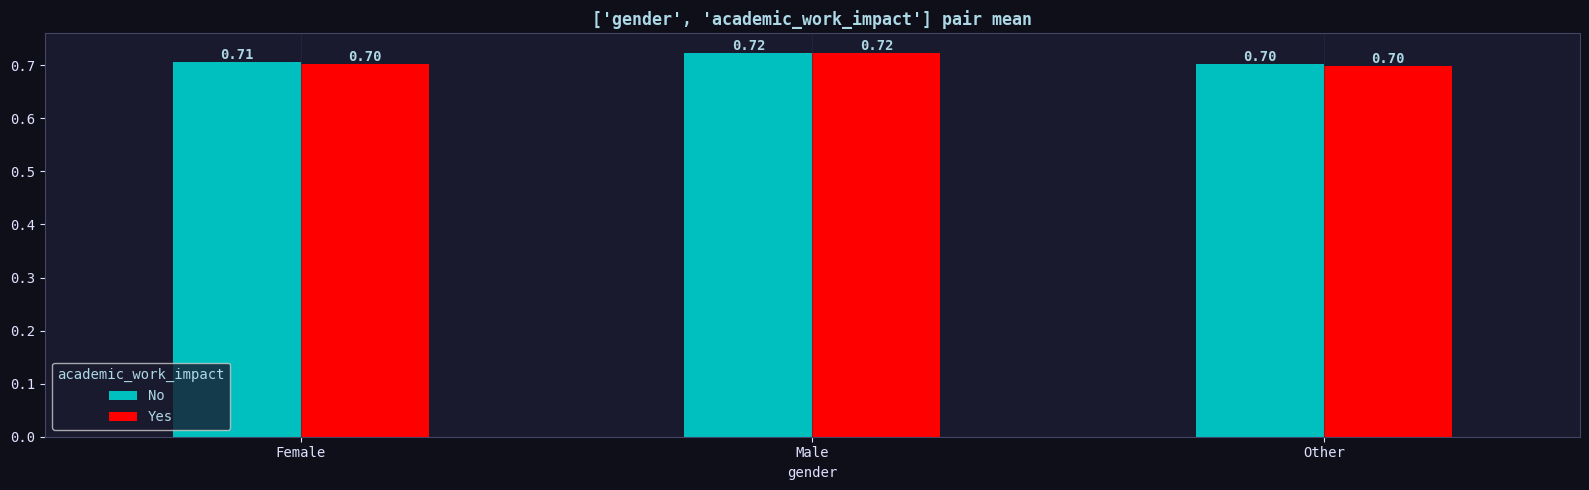


('academic_work_impact', 'stress_level')| stress_level has more unique variables | ['stress_level', 'academic_work_impact']


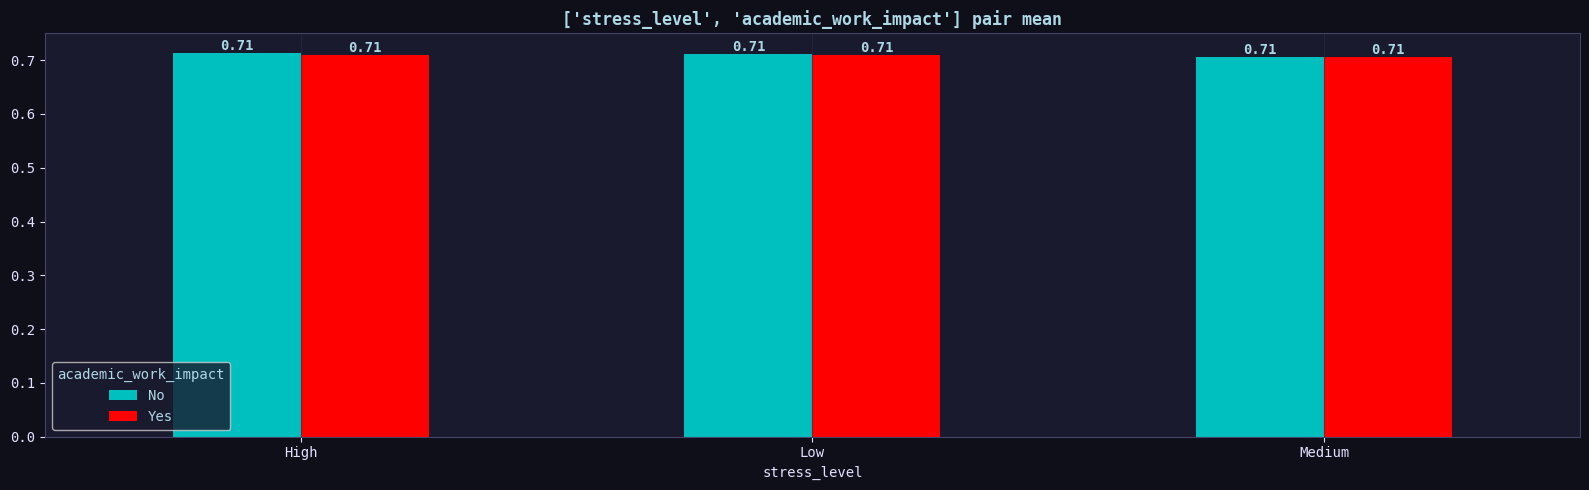


('gender', 'stress_level')| stress_level has more unique variables | ['stress_level', 'gender']


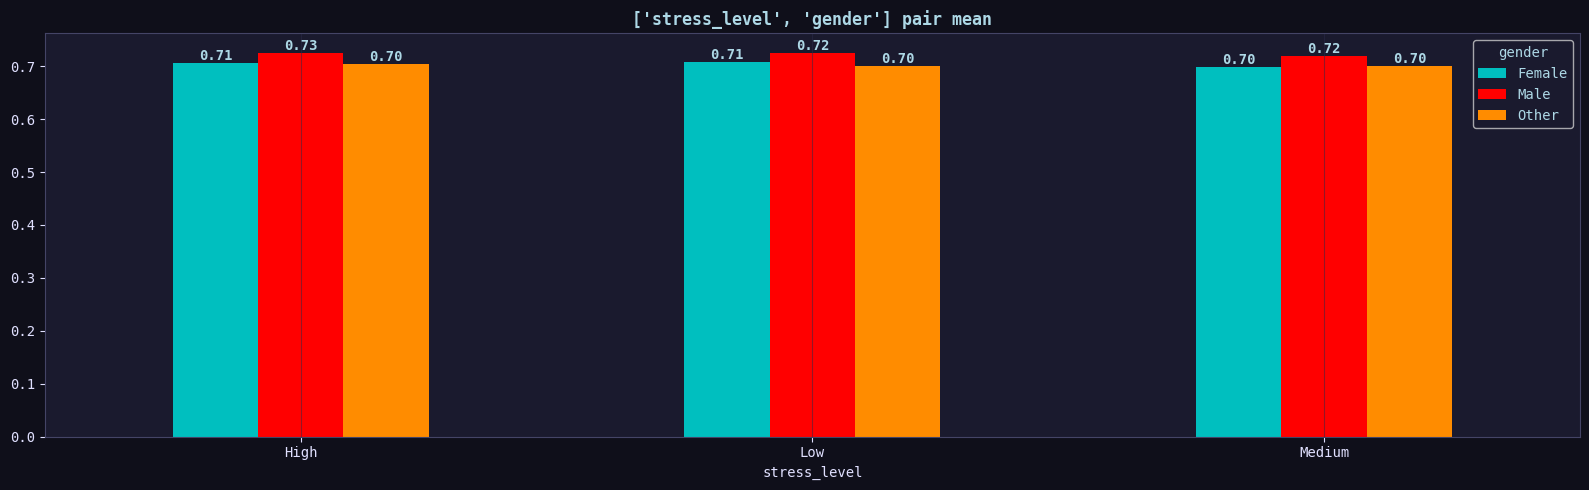

In [27]:
## -- Pairwise feature-mean (binary target) --
PAIRS = itertools.combinations(n_unique[n_unique < 10].index, 2)

for i, combo in enumerate(PAIRS):
    if train[combo[0]].nunique() > train[combo[1]].nunique():
        print(combo, end='')
        print(f'| {combo[0]} has more unique variables | ', end='')
        combo = [combo[0], combo[1]]
        print(combo)
    else:
        print(combo, end='')
        print(f'| {combo[1]} has more unique variables | ', end='')
        combo = [combo[1], combo[0]]
        print(combo)

    group_mean = train.groupby(combo)[TARGET].mean().unstack()
    ax1 = group_mean.plot.bar(figsize=(16, 5))
    ax1.set_title(f'{combo} pair mean', fontweight='semibold')
    ax1.tick_params('x', rotation=0)
    ax1.grid(axis='x')

    for container in ax1.containers: # Show values on bars
        ax1.bar_label(container, fmt='%.2f', fontsize=10, fontweight='semibold')

    plt.tight_layout()
    plt.show()
    print()

In [28]:
n_unique

academic_work_impact          2
gender                        3
stress_level                  3
age                          18
app_opens_per_day           166
notifications_per_day       231
gaming_hours                401
sleep_hours                 451
work_study_hours            600
social_media_hours          721
daily_screen_time_hours    1389
weekend_screen_time        1437
dtype: int64

In [29]:
try:
    from labellines import labelLines
except:
    !uv pip install -q matplotlib-label-lines
    from labellines import labelLines

In [30]:
# ## -- Pairwise 'Position' against others --
# PAIRS = itertools.product(['gender'], n_unique[n_unique <= 10].index)
# PLOT_LINE = True

# for i, combo in enumerate(PAIRS):
#     # fig, axs = plt.subplots(1, 1, figsize=(15, 5), facecolor='#0f0f1a')
#     group_mean = train.groupby([*combo])[TARGET].mean().unstack()
#     if PLOT_LINE:
#         ax1 = group_mean.plot.line(figsize=(16, 5), marker='o')
#     else:
#         ax1 = group_mean.plot.bar(figsize=(16, 5))
#     ax1.set_title(f'{combo} pair mean', fontweight='semibold')
#     ax1.tick_params('x', rotation=0)
#     ax1.grid()

#     if PLOT_LINE:
#         labelLines(ax1.get_lines(), align=True)
#     else:
#         for container in ax1.containers: # Add values on bars
#             ax1.bar_label(container, fmt='%.2f', fontsize=10, fontweight='semibold')

#     plt.tight_layout()
#     plt.show()
#     print()

In [31]:
# ## -- Pairwise 'Race' against others --
# PAIRS = itertools.product(['age'], n_unique[n_unique < 10].index)
# PLOT_LINE = False

# for i, combo in enumerate(PAIRS):
#     group_mean = train.groupby([*combo])[TARGET].mean().unstack()
#     if PLOT_LINE:
#         ax1 = group_mean.plot.line(figsize=(18, 8))
#     else:
#         ax1 = group_mean.plot.bar(figsize=(18, 8))
#     ax1.set_title(f'{combo} pair mean', fontweight='semibold')
#     ax1.tick_params('x', rotation=90)
#     ax1.grid()

#     if PLOT_LINE:
#         labelLines(ax1.get_lines(), align=True)
#     else:
#         for container in ax1.containers: # Add values on bars
#             ax1.bar_label(container, fmt='%.2f', fontsize=10, fontweight='semibold')

#     plt.tight_layout()
#     plt.show()
#     print()

In [32]:
# ## -- Pairwise 'Position_Change' against others --
# PAIRS = itertools.product(['stress_level'], n_unique[n_unique < 10].index)
# PLOT_LINE = True

# for i, combo in enumerate(PAIRS):
#     # fig, axs = plt.subplots(1, 1, figsize=(15, 5), facecolor='#0f0f1a')
#     group_mean = train.groupby([*combo])[TARGET].mean().unstack()
#     if PLOT_LINE:
#         ax1 = group_mean.plot.line(figsize=(16, 5), marker='o')
#     else:
#         ax1 = group_mean.plot.bar(figsize=(16, 5))
#     ax1.set_title(f'{combo} pair mean', fontweight='semibold')
#     ax1.tick_params('x', rotation=0)
#     ax1.grid()

#     if PLOT_LINE:
#         labelLines(ax1.get_lines(), align=True)
#     else:
#         for container in ax1.containers: # Add values on bars
#             ax1.bar_label(container, fmt='%.2f', fontsize=10, fontweight='semibold')

#     plt.tight_layout()
#     plt.show()
#     print()

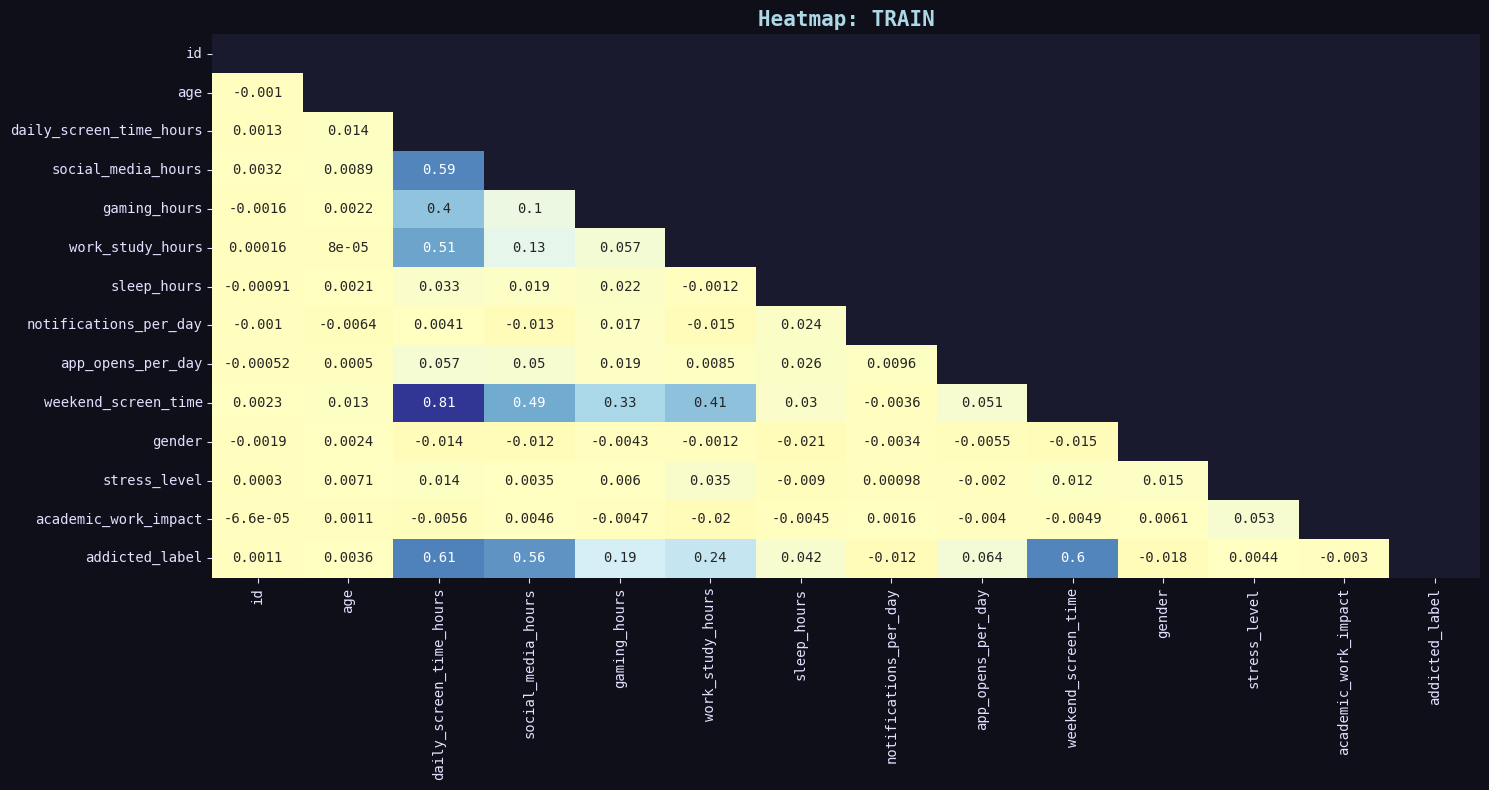

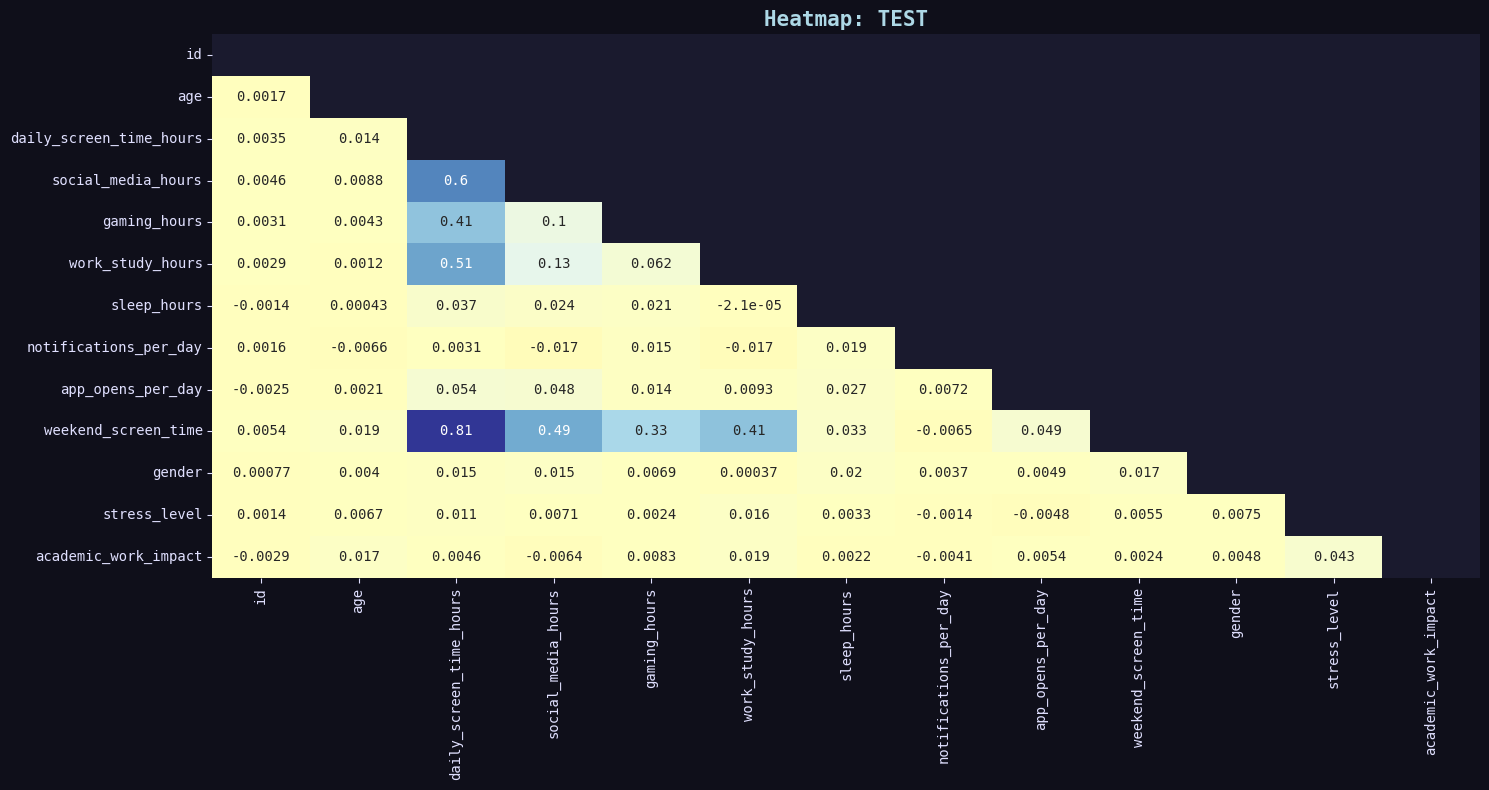

In [33]:
def plot_heatmap(df_, name='Data'):
    df = df_.copy()
    cat_cols = [c for c in df.columns if df[c].dtype in ['str', 'object', 'category']]
    for c in cat_cols:
        df[c] = pd.factorize(df[c])[0]

    CORR = df.corr('spearman')
    plt.figure(figsize=(15, 8))
    sns.heatmap(CORR, mask=np.triu(CORR), annot=True, cmap='RdYlBu', cbar=False, center=0)
    plt.title(f"Heatmap: {name}", fontdict={'size':15, 'weight': 'semibold'})
    plt.tight_layout()
    plt.show()

    del df

plot_heatmap(train, 'TRAIN')
# plot_heatmap(orig, 'ORIGINAL')
plot_heatmap(test, 'TEST')

In [34]:
# ## -- VIOLIN PLOT --
# plt.figure(figsize=(18, 5))
# for i, col in enumerate(NUMS):
#     plt.subplot(1, len(NUMS), i+1)
#     sns.violinplot(train[col])

# plt.tight_layout()
# plt.show()

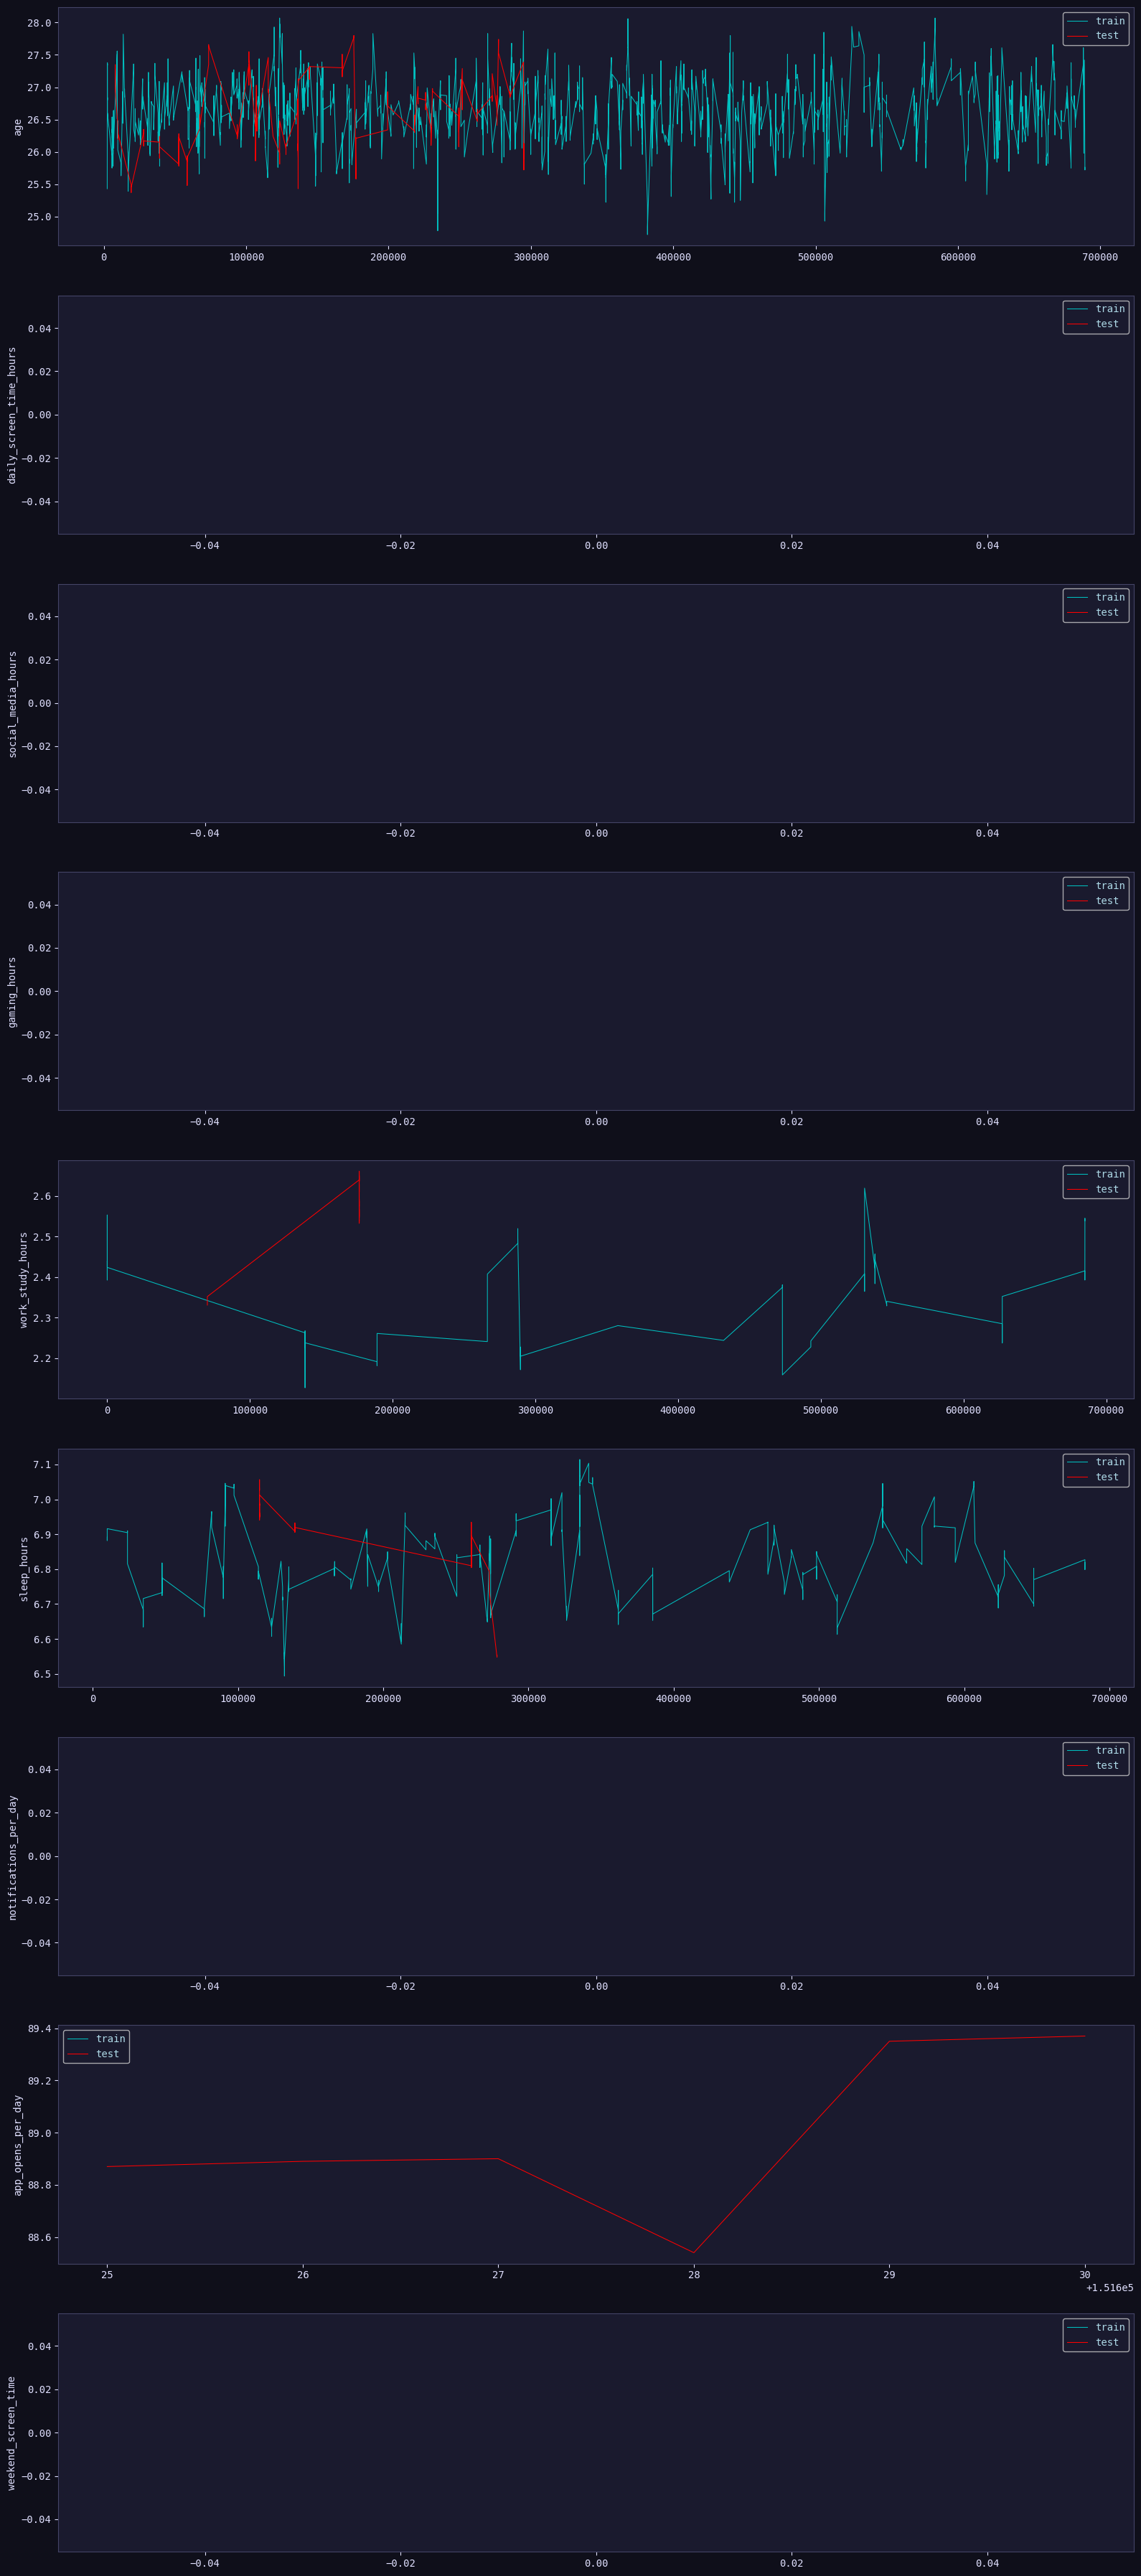

In [35]:
## -- Drift check--
rolling = 100
line_w = 0.75

plt.figure(figsize=(16, len(NUMS) * 4))
for i, col in enumerate(NUMS):
    plt.subplot(len(NUMS), 1, i + 1)
    sns.lineplot(train[col].rolling(rolling).mean(), linewidth=line_w, label='train')
    sns.lineplot(test[col].rolling(rolling).mean(),  linewidth=line_w, label='test')
    # sns.lineplot(orig[col].rolling(1000).mean(),  linewidth=line_w, label='orig')

plt.legend()
plt.tight_layout(h_pad=2)
plt.show()

In [36]:
# %%time

# ## -- FEATURE MUTUAL INFO --
# mutual_info = mutual_info_regression(train[BASE], train[TARGET])
# mutual_info_df = pd.DataFrame.from_dict(
#     dict(zip(test.columns.tolist(), list(mutual_info))),
#     orient='index', columns=['Score'],
# ).sort_values(by='Score', ascending=False)

# plt.figure(figsize=(18, 8))
# sns.barplot(data=mutual_info_df, x='Score', y=mutual_info_df.index)
# plt.title('-- Univariate Analysis: Top predictors --')
# plt.show()

## 1. Kolmogorov-Smirnov (K-S) test

In [37]:
from scipy.stats import ks_2samp

def ks_driftcheck(df_1, df_2, df2_mame: str, features):
    df_train = df_1.copy()
    df_test  = df_2.copy()

    ks_stats_all = []
    cols = []
    threshold = 0.05

    print(f"{'feature':>25}\t{'ks-stat':>10}\t{'drift'}")
    print(f"{'-'*20:>25}\t{'-------':>10}\t{'-------'}")
    RED = '\033[33m'
    for c in features:
        ks_stat, p_val = np.round(ks_2samp(df_train[c].values, df_test[c].values), 6)
        if ks_stat >= threshold:
            print(f"{CFG['YELLOW']}{c:>25}\t{ks_stat:>10}\t⚠️ Drift{CFG['RESET']}")
        else:
            print(f"{c:>25}\t{ks_stat:>10}\t✅ Safe!")

        ks_stats_all.append(ks_stat)
        cols.append(c)

    print()
    plt.barh(cols, ks_stats_all, color=['r' if c >= threshold else 'gray'for c in ks_stats_all])
    plt.axvline(x=threshold, linestyle='--', color='y', label=f'Drift threshold: {threshold}')
    plt.title(f"(K-S) drift test: TRAIN vs {df2_mame}", fontweight='semibold')
    plt.legend()
    plt.show()

    gc.collect()

                  feature	   ks-stat	drift
     --------------------	   -------	-------
                      age	       nan	✅ Safe!
  daily_screen_time_hours	       nan	✅ Safe!
       social_media_hours	       nan	✅ Safe!
             gaming_hours	       nan	✅ Safe!
         work_study_hours	       nan	✅ Safe!
              sleep_hours	       nan	✅ Safe!
    notifications_per_day	       nan	✅ Safe!
        app_opens_per_day	       nan	✅ Safe!
      weekend_screen_time	       nan	✅ Safe!
                   gender	       nan	✅ Safe!
             stress_level	       nan	✅ Safe!
     academic_work_impact	       nan	✅ Safe!



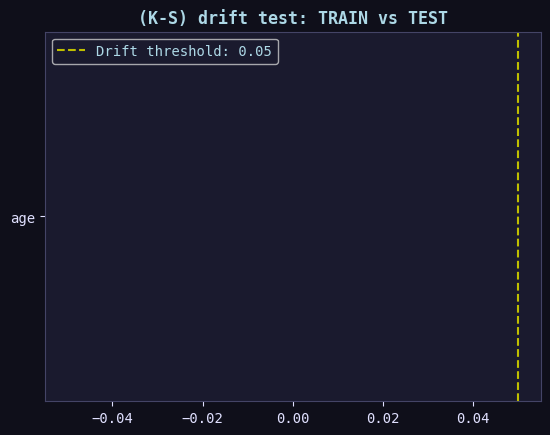

In [38]:
## -- Drift test for TRAIN & TEST --
ks_driftcheck(train, test, 'TEST', BASE)

In [39]:
# ## -- Drift test for TRAIN & ORIGINAL --
# ks_driftcheck(train, orig, 'ORIGINAL', BASE+[TARGET])

## 2. GAM Partial Effects

In [40]:
len(BASE)

12

In [41]:
try:
    from pygam import LogisticGAM, s, f
except:
    !uv pip install -q pygam
    from pygam import LogisticGAM, s, f

def gam_dependence_effect(df, features, target, cats):
    df1 = df.copy()
    for c in cats:
        df1[c] = df1[c].factorize()[0]

    for c in features:
        df1[c] = df1[c].fillna(-1.0)

    X_gam = df1[features]
    y_gam = df1[target].values

    # Dynamically build the GAM formula based on feature types
    gam_terms = []
    for i, feature_name in enumerate(features):
        if feature_name in cats:
            gam_terms.append(f"f({i})")
        else:
            gam_terms.append(f"s({i})")
    gam_formula = " + ".join(gam_terms)

    # Evaluate the string formula into actual pygam Term objects
    gam = LogisticGAM(eval(gam_formula))
    gam.fit(X_gam.values, y_gam)
    display(gam.summary())

    rows = (len(features) + 2) // 3 # Calculate rows for subplots dynamically
    fig, axs = plt.subplots(rows, 3, figsize=(18, rows*4))
    axs = axs.ravel()

    for i, col in enumerate(features):
        XX = gam.generate_X_grid(term=i)
        pdep = gam.partial_dependence(term=i, X=XX)

        axs[i].plot(XX[:, i], pdep)
        axs[i].set_title(f"GAM partial effect: {col}")
        axs[i].set_xlabel(col)
        axs[i].set_ylabel('partial effect')

    # Hide any unused subplots
    for j in range(len(features), len(axs)):
        fig.delaxes(axs[j])

    plt.tight_layout(pad=2.0)
    plt.show()

print("GAM Dependency function ready!")

GAM Dependency function ready!


LogisticGAM                                                                                               
=============================================== ==========================================================
Distribution:                      BinomialDist Effective DoF:                                    132.9129
Link Function:                        LogitLink Log Likelihood:                               -210591.3428
Number of Samples:                       691369 AIC:                                           421448.5114
                                                AICc:                                          421448.5636
                                                UBRE:                                               2.6097
                                                Scale:                                                 1.0
                                                Pseudo R-Squared:                                   0.4946
Feature Function                  Lam

None

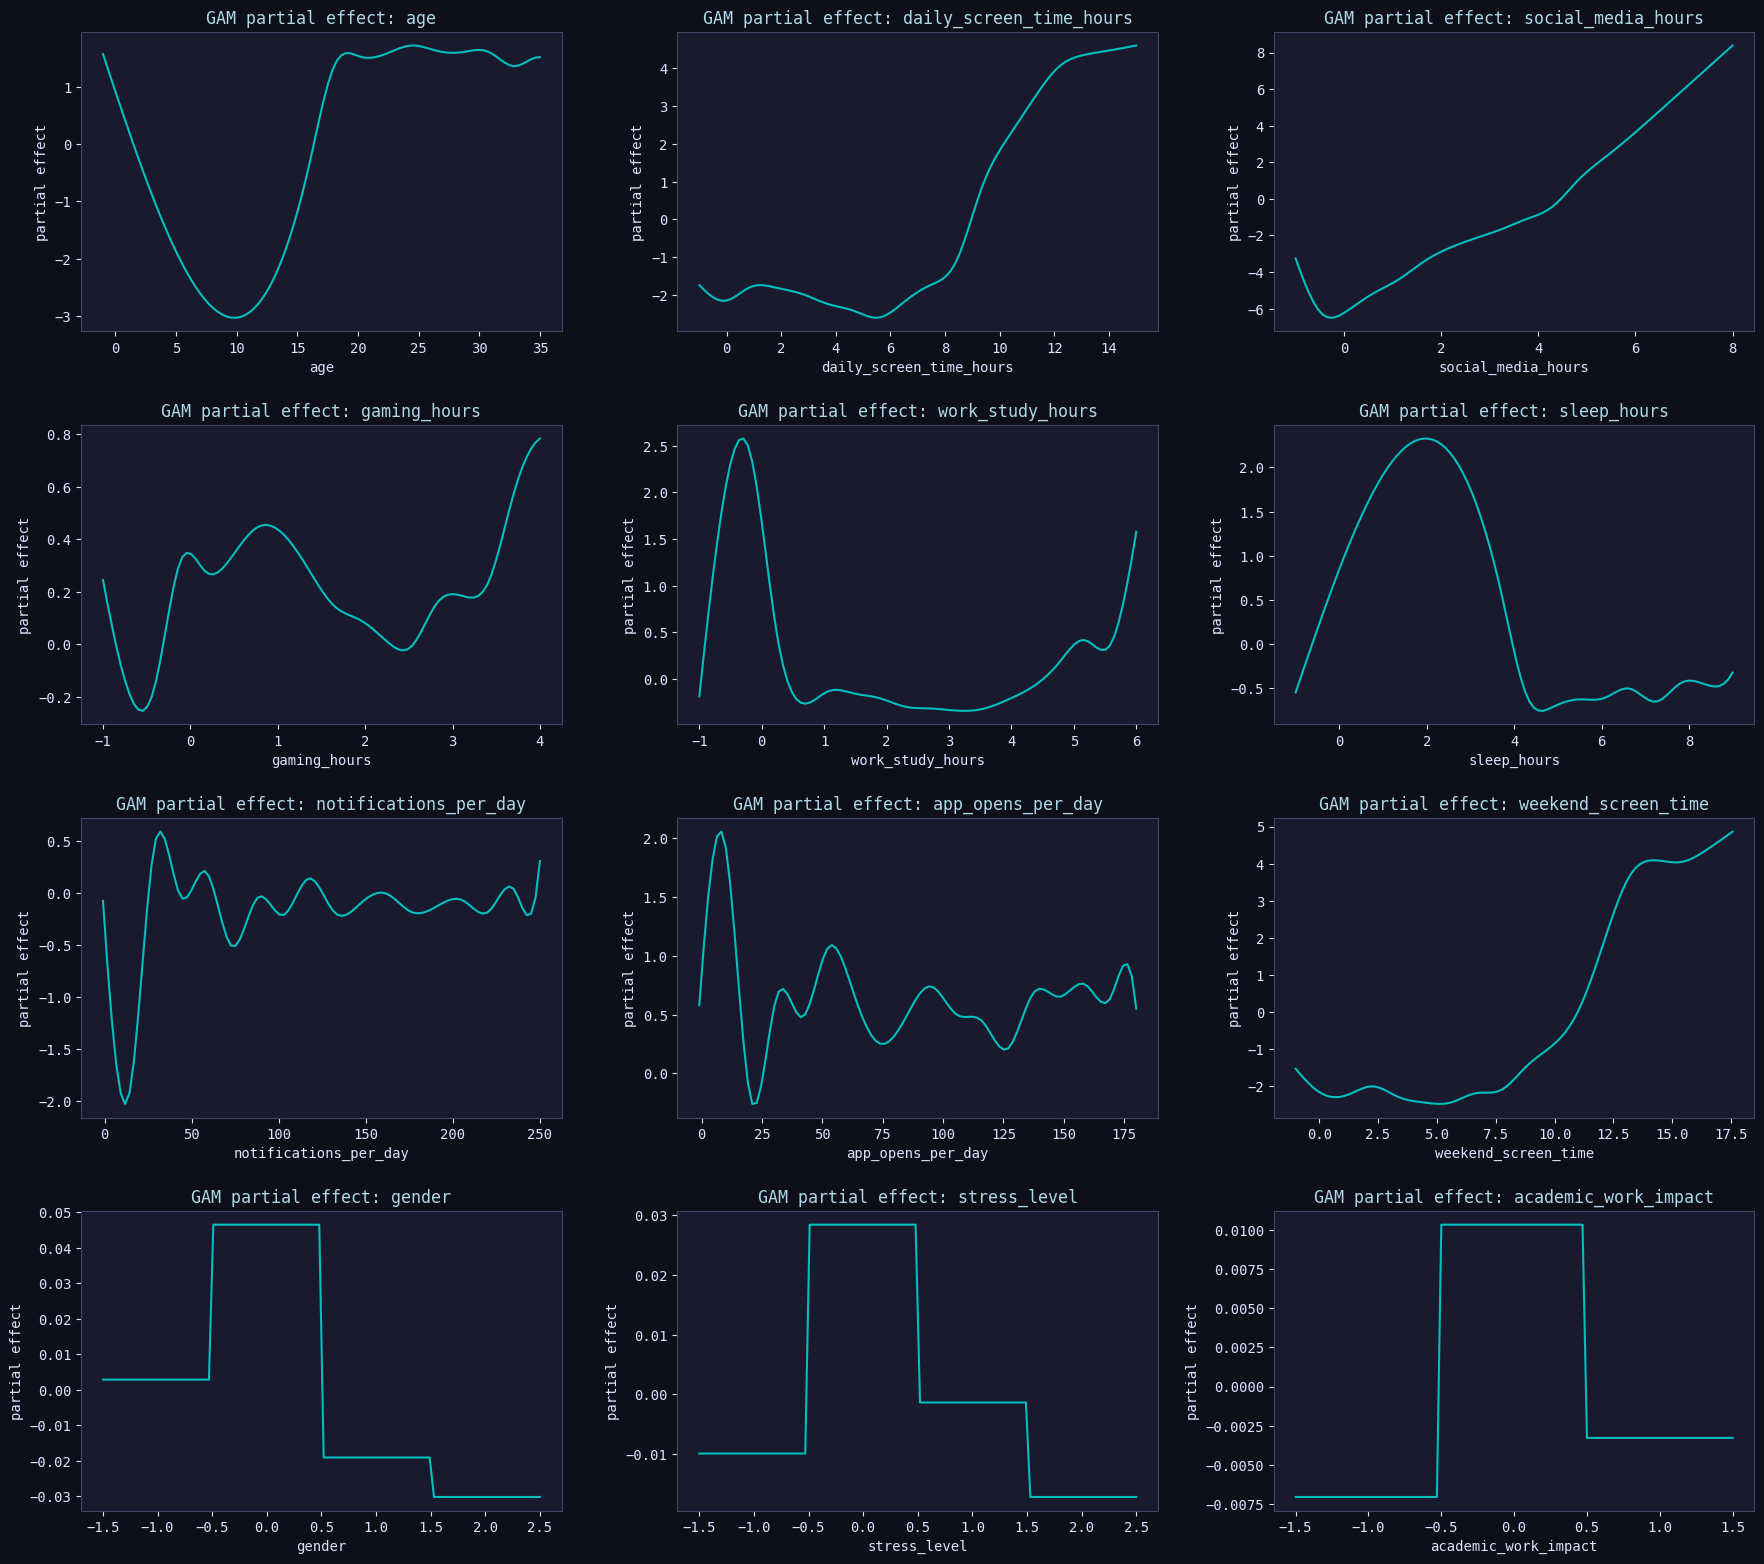

CPU times: user 10min 10s, sys: 40.6 s, total: 10min 50s
Wall time: 4min 52s


In [42]:
%%time

gam_plot = gam_dependence_effect(train, BASE, TARGET, CATS)

In [43]:
# ## -- Duplicate all numerics as categories --
# CATS_2 = []

# for c in NUMS:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     orig[n]  = orig[c].copy()
#     CATS_2.append(n)

#     ## -- FACTORIZE CATS_2 --
#     combine  = pd.concat([train[n], test[n], orig[n]])
#     v = combine.factorize()[0]
#     train[n] = v[:len(train)].astype('int32')
#     test[n]  = v[len(train):len(train)+len(test)].astype('int32')
#     orig[n]  = v[len(train)+len(test):].astype('int32')

# print(f'Numericals to Categoricals: {len(CATS_2)}')

## 3. Permutation Importances

In [44]:
from sklearn.inspection import permutation_importance

def plot_permutation_importance(model, X, y, categories=None):
    if categories != None:
        for c in categories:
            X[c] = X[c].factorize()[0]
            X[c] = X[c].astype("category")

    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

    ## -- Compute Model Importances --
    print("Base model training... ", end="")
    model.fit(X_train, y_train)
    model_importances = pd.Series(model.feature_importances_, index=X.columns)
    print("Complete!")

    ## -- Compute Permutation Importances --
    print("Permutation training... ", end="")
    result = permutation_importance(
        model, X_test, y_test,
        n_repeats=10, #max_samples=0.95,
        # sample_weight=get_weights(y_test, y),
        scoring="roc_auc",
        random_state=0,
        #n_jobs=-1
    )
    perm_sorted_idx = result.importances_mean.argsort()
    print("Complete!")

    fig, axs = plt.subplots(1, 2, figsize=(15, 8))

    model_importances.sort_values().plot.barh(ax=axs[0])
    axs[0].set_xlabel("Model importance")

    axs[1].boxplot(
        result.importances[perm_sorted_idx].T,
        tick_labels=X.columns[perm_sorted_idx],
        orientation="horizontal", whis=(0, 100)
    )

    axs[1].axvline(x=0, linestyle="--", color="y")
    axs[1].set_xlabel("Permutaion importance")

    fig.suptitle("Impurity-based vs. Permutation on valid data")
    _ = fig.tight_layout()

    df = pd.Series(
        result.importances_mean[perm_sorted_idx],
        index=X.columns[perm_sorted_idx],
        ).sort_values(ascending=False)

    return df

print("Permutation function ready!")

Permutation function ready!


Base model training... Complete!
Permutation training... Complete!
CPU times: user 1min 55s, sys: 94 ms, total: 1min 55s
Wall time: 1min 1s


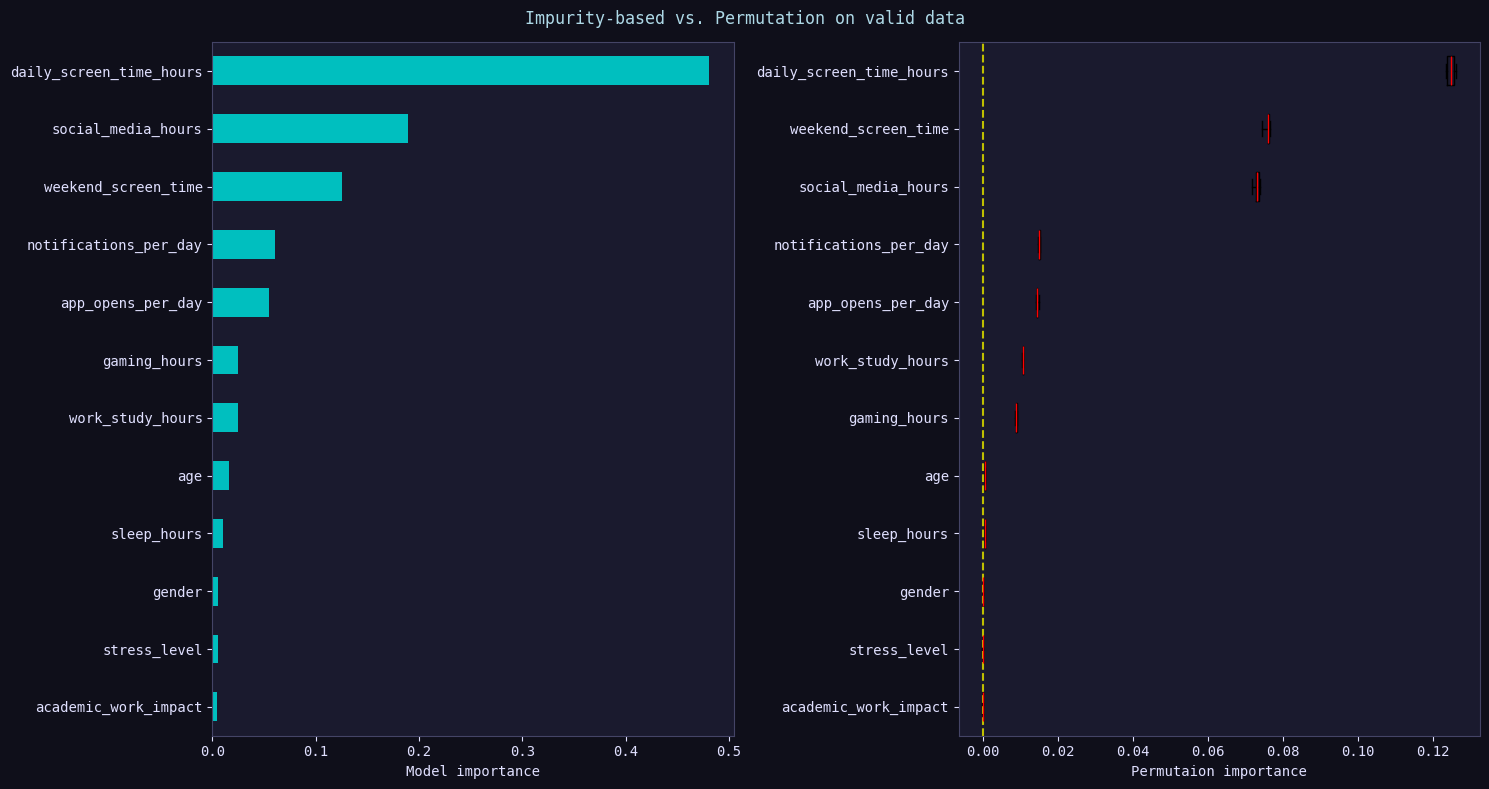

In [45]:
%%time

params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'enable_categorical': True,
    'random_state': CFG['SEED'],
    'verbosity': 0,
    'n_jobs': 64 if os.cpu_count() > 4 else 3,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
}

xgb_model = xgb.XGBClassifier(**params)

perm_df = plot_permutation_importance(xgb_model, train[BASE], train[TARGET], CATS)

In [46]:
# try:
#     from evidently import Dataset, DataDefinition, Report
#     from evidently.presets import DataDriftPreset, DataSummaryPreset
# except:
#     %pip install -q -U evidently
#     from evidently import Dataset, DataDefinition, Report
#     from evidently.presets import DataDriftPreset, DataSummaryPreset

# def evid_driftcheck(df_1, df_2, features, nums, cats):

#     schema = DataDefinition(
#         numerical_columns=nums,
#         categorical_columns=cats,
#         # classification=[BinaryClassification(target="target", prediction_labels="prediction")]
#     )

#     train_df = Dataset.from_pandas(df_1[features], data_definition=schema)
#     test_df  = Dataset.from_pandas(df_2[features], data_definition=schema)

#     report   = Report([DataDriftPreset()])
#     my_eval  = report.run(train_df, test_df)

#     return my_eval

In [47]:
# ## -- Drift: 'train' & 'test' datasets --
# drift_train_test = evid_driftcheck(train, test, BASE, NUMS, CATS)
# display(drift_train_test)

In [48]:
# ## -- Drift: 'train' & 'orig' datasets --
# drift_train_orig = evid_driftcheck(train, orig, BASE, NUMS, CATS)
# display(drift_train_orig)

In [49]:
# from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

# class TargetEncoder(BaseEstimator, TransformerMixin):
#     """
#     Target Encoder that supports multiple aggregation functions,
#     internal cross-validation for leakage prevention, and smoothing.

#     Parameters
#     ----------
#     cols_to_encode : list of str
#         List of column names to be target encoded.

#     aggs : list of str, default=['mean']
#         List of aggregation functions to apply. Any function accepted by
#         pandas' `.agg()` method is supported, such as:
#         'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
#         'count', 'sum', 'median'.
#         Smoothing is applied only to the 'mean' aggregation.

#     cv : int, default=5
#         Number of folds for cross-validation in fit_transform.

#     smooth : float or 'auto', default='auto'
#         The smoothing parameter `m`. A larger value puts more weight on the
#         global mean. If 'auto', an empirical Bayes estimate is used.

#     drop_original : bool, default=False
#         If True, the original columns to be encoded are dropped.
#     """
#     def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
#         self.cols_to_encode = cols_to_encode
#         self.aggs = aggs
#         self.cv = cv
#         self.smooth = smooth
#         self.drop_original = drop_original
#         self.mappings_ = {}
#         self.global_stats_ = {}

#     def fit(self, X, y):
#         """
#         Learn mappings from the entire dataset.
#         These mappings are used for the transform method on validation/test data.
#         """
#         temp_df = X.copy()
#         temp_df['target'] = y

#         # Learn global statistics for each aggregation
#         for agg_func in self.aggs:
#             self.global_stats_[agg_func] = y.agg(agg_func)

#         # Learn category-specific mappings
#         for col in self.cols_to_encode:
#             self.mappings_[col] = {}
#             for agg_func in self.aggs:
#                 mapping = temp_df.groupby(col)['target'].agg(agg_func)
#                 self.mappings_[col][agg_func] = mapping

#         return self

#     def transform(self, X):
#         """
#         Apply learned mappings to the data.
#         Unseen categories are filled with global statistics.
#         """
#         X_transformed = X.copy()
#         for col in self.cols_to_encode:
#             for agg_func in self.aggs:
#                 new_col_name = f'TE_{col}_{agg_func}'
#                 map_series = self.mappings_[col][agg_func]
#                 X_transformed[new_col_name] = X[col].map(map_series)
#                 X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

#         if self.drop_original:
#             X_transformed.drop(columns=self.cols_to_encode, inplace=True)

#         return X_transformed

#     def fit_transform(self, X, y):
#         """
#         Fit and transform the data using internal cross-validation to prevent leakage.
#         """
#         # First, fit on the entire dataset to get global mappings for transform method
#         self.fit(X, y)

#         # Initialize an empty DataFrame to store encoded features
#         encoded_features = pd.DataFrame(index=X.index)

#         kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

#         for train_idx, val_idx in kf.split(X, y):
#             X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
#             X_valid = X.iloc[val_idx]

#             temp_df_train = X_train.copy()
#             temp_df_train['target'] = y_train

#             for col in self.cols_to_encode:
#                 # --- Calculate mappings only on the training part of the fold ---
#                 for agg_func in self.aggs:
#                     new_col_name = f'TE_{col}_{agg_func}'

#                     # Calculate global stat for this fold
#                     fold_global_stat = y_train.agg(agg_func)

#                     # Calculate category stats for this fold
#                     mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

#                     # --- Apply smoothing only for 'mean' aggregation ---
#                     if agg_func == 'mean':
#                         counts = temp_df_train.groupby(col)['target'].count()

#                         m = self.smooth
#                         if self.smooth == 'auto':
#                             # Empirical Bayes smoothing
#                             variance_between = mapping.var()
#                             avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
#                             if variance_between > 0:
#                                 m = avg_variance_within / variance_between
#                             else:
#                                 m = 0  # No smoothing if no variance between groups

#                         # Apply smoothing formula
#                         smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
#                         encoded_values = X_valid[col].map(smoothed_mapping)
#                     else:
#                         encoded_values = X_valid[col].map(mapping)

#                     # Store encoded values for the validation fold
#                     encoded_features.loc[X_valid.index, new_col_name] = encoded_values.fillna(fold_global_stat)

#         # Merge with original DataFrame
#         X_transformed = X.copy()
#         for col in encoded_features.columns:
#             X_transformed[col] = encoded_features[col]

#         if self.drop_original:
#             X_transformed.drop(columns=self.cols_to_encode, inplace=True)

#         return X_transformed


# class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
#     def __init__(self, cat_cols=None):
#         self.cat_cols = cat_cols
#         self.mappings_ = {}
#     def fit(self, X, y):
#         X = X.copy()
#         if self.cat_cols is None:
#             self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
#         self.mappings_ = {}
#         for col in self.cat_cols:
#             df_temp = pd.DataFrame({col: X[col], 'y': y})
#             group_means = df_temp.groupby(col, dropna=False)['y'].mean()
#             sorted_categories = group_means.sort_values().index
#             self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
#         return self

#     def transform(self, X, y=None):
#         X = X.copy()
#         for col, mapping in self.mappings_.items():
#             if col in X.columns:
#                 X[col] = X[col].map(mapping)
#         return X

In [50]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_valid: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_valid.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_valid.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_valid.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [51]:
# train, test, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:1000],
#     features=BASE,
#     target=TARGET,
#     # - (count, mean, count, std, nunique, median, max, min)
#     aggs=['mean'],
#     fill_nan=True,
# )

# print(ORIG_COLS)

In [52]:
## -- Factorize using combined data --

# for c in CATS:
#     print(c)
#     combine  = pd.concat([train[c], test[c]]) # , orig[c]
#     combine  = combine.factorize()[0]
#     # combine  = pd.Series(combine).astype('category')
#     train[c] = pd.Series(combine[:len(train)], index=train.index).astype('category')
#     test[c]  = pd.Series(combine[len(train):len(train)+len(test)], index=test.index).astype('category')
#     # orig[c]  = combine[-len(orig):]

# print('Label encoding complete!')

In [53]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print('✓ Total Features:', len(FEATURES))

# if 'age' in NUMS:
#     NUMS.remove('age')
# if 'age' not in CATS:
#     CATS.append('age')

# group = train['Stint'].to_numpy()
# gkf = GroupKFold(n_splits=len(np.unique(group)), shuffle=True, random_state=CFG.SEED)

oof_final    = pd.DataFrame()
test_final   = pd.DataFrame()
model_scores = pd.Series()

CFG['FOLDS'] = 5
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

✓ Total Features: 12


# ML TRAINING

In [54]:
## -- TREE MODELS --
tree_models = {
    'xgb_': xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        random_state=CFG['SEED'],
        enable_categorical=True,
        n_jobs=-1,
        verbosity=0,
        device='cuda' if torch.cuda.is_available() else 'cpu',
    ),
    'lgb_': lgb.LGBMClassifier(
        objective='binary',
        metric='auc',
        verbose=-1,
        random_state=CFG['SEED'],
        nthreads=-1,
        device='gpu' if torch.cuda.is_available() else 'cpu',
    ),
    'cat_': cgb.CatBoostClassifier(
        loss_function='Logloss', # -> also 'CrossEntropy'
        eval_metric='AUC',
        cat_features=CATS,
        verbose=0,
        random_state=CFG['SEED'],
        allow_writing_files=False,
        thread_count=-1,
        task_type='GPU' if torch.cuda.is_available() else 'CPU',
    ),
    'rfc_': RandomForestClassifier(
        # n_estimators=20,
        # max_depth=5,
        n_jobs=-1,
        random_state=CFG['SEED'],
    ),
    'hist_': HistGradientBoostingClassifier(random_state=CFG['SEED']),
}

print(f"Tree Models to train: {len(tree_models)} -> ", end='')
print(list(tree_models.keys()))

Tree Models to train: 5 -> ['xgb_', 'lgb_', 'cat_', 'rfc_', 'hist_']


## ~ TREE MODELS

Training Models:   0%|          | 0/5 [00:00<?, ?it/s]


[1] XGB_ ██████████ | (553095, 12)
• Fold 1/5 Score: 0.959850
• Fold 2/5 Score: 0.960370
• Fold 3/5 Score: 0.960896
• Fold 4/5 Score: 0.961134
• Fold 5/5 Score: 0.960009
OOF Score: 0.960448
AVG Score: 0.960452 ± 0.000495
Time: 0.56 mins


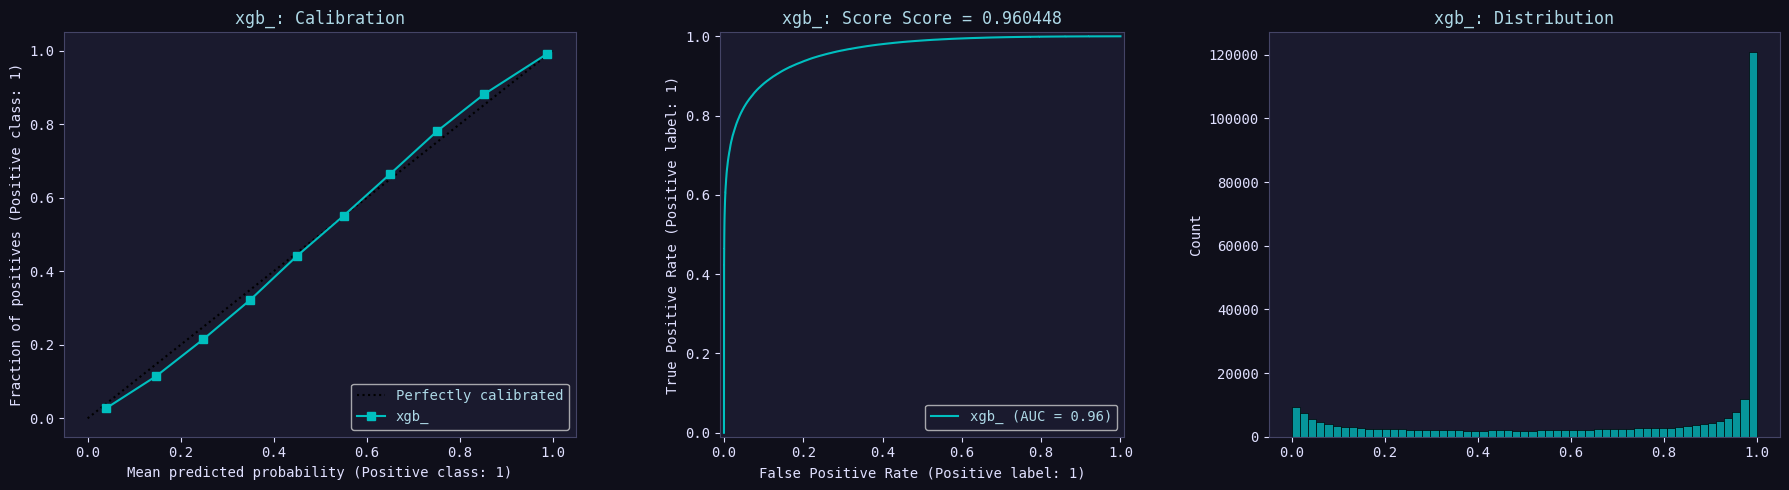


[2] LGB_ ██████████ | (553095, 12)
• Fold 1/5 Score: 0.954053
• Fold 2/5 Score: 0.954552
• Fold 3/5 Score: 0.955218
• Fold 4/5 Score: 0.955882
• Fold 5/5 Score: 0.954825
OOF Score: 0.954902
AVG Score: 0.954906 ± 0.000618
Time: 0.60 mins


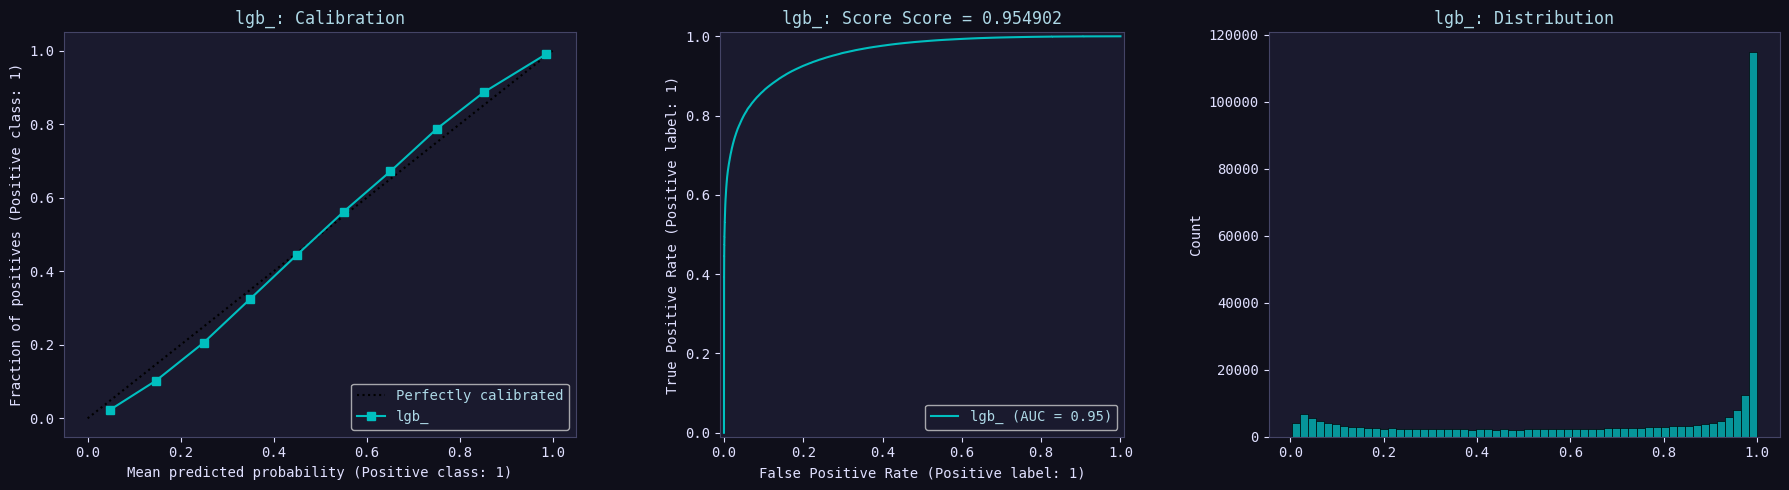


[3] CAT_ ██████████ | (553095, 12)
• Fold 1/5 Score: 0.962213
• Fold 2/5 Score: 0.962584
• Fold 3/5 Score: 0.962989
• Fold 4/5 Score: 0.963551
• Fold 5/5 Score: 0.962635
OOF Score: 0.962795
AVG Score: 0.962795 ± 0.000451
Time: 29.33 mins


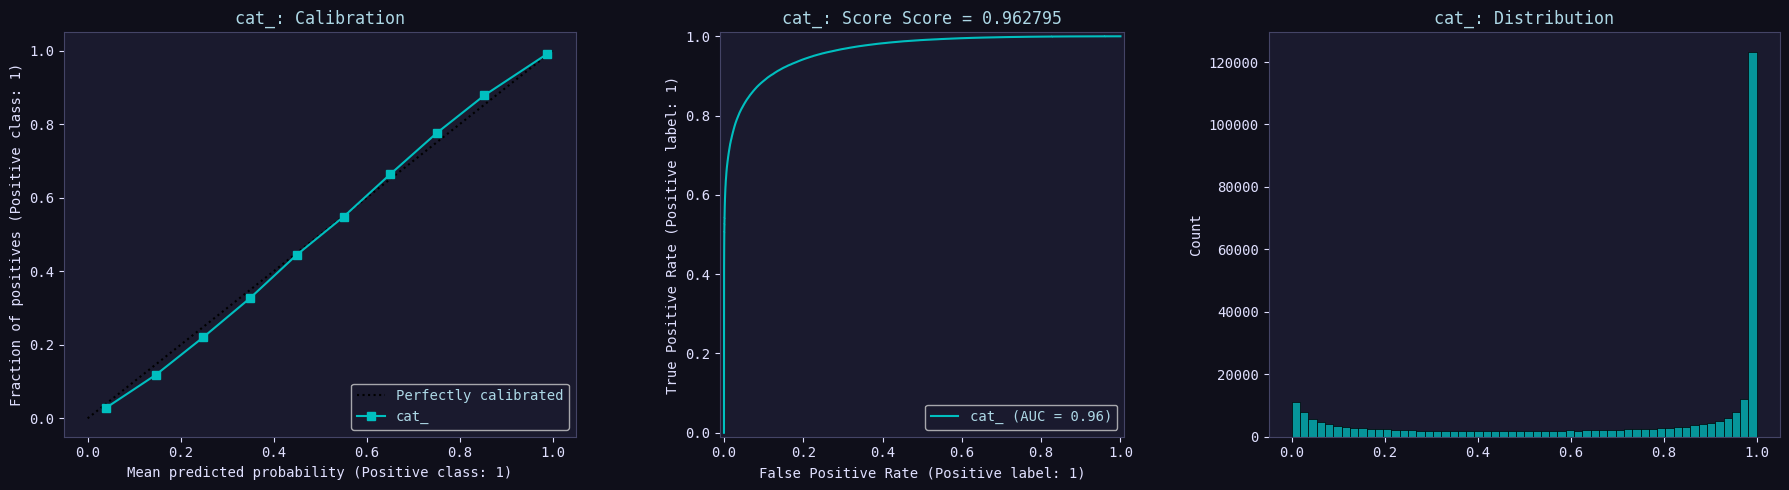


[4] RFC_ ██████████ | (553095, 12)
• Fold 1/5 Score: 0.940470
• Fold 2/5 Score: 0.941048
• Fold 3/5 Score: 0.942009
• Fold 4/5 Score: 0.942437
• Fold 5/5 Score: 0.941718
OOF Score: 0.941533
AVG Score: 0.941536 ± 0.000699
Time: 7.44 mins


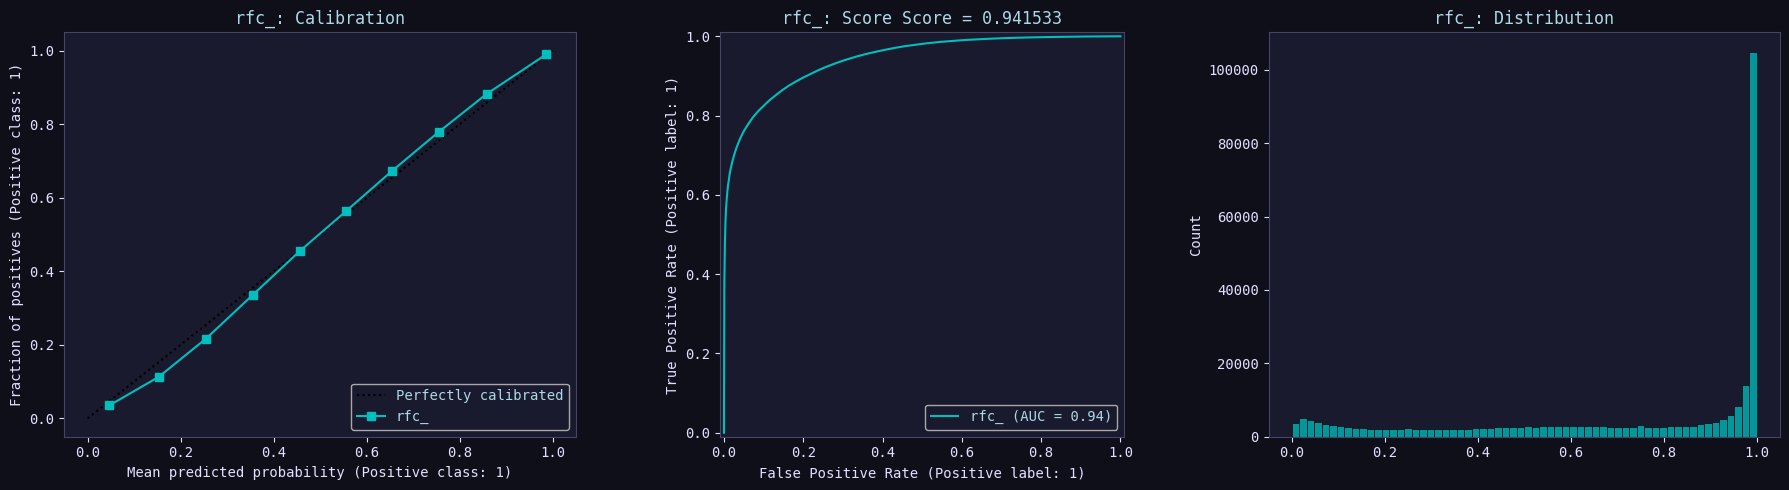


[5] HIST_ ██████████ | (553095, 12)
• Fold 1/5 Score: 0.953966
• Fold 2/5 Score: 0.954015
• Fold 3/5 Score: 0.955326
• Fold 4/5 Score: 0.955772
• Fold 5/5 Score: 0.954457
OOF Score: 0.954704
AVG Score: 0.954707 ± 0.000722
Time: 0.83 mins


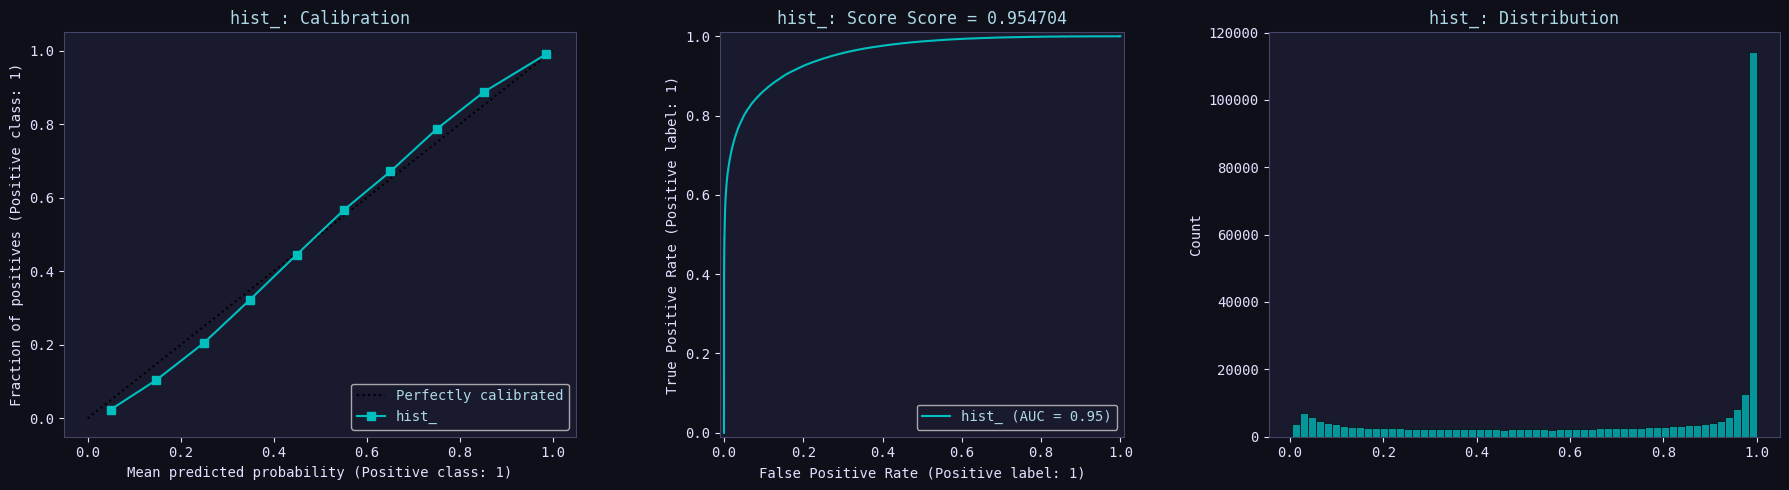

In [55]:
## -- Initiate GBDTs Training --
TREE_MODELS = {}

X = train[FEATURES].copy()
y = train[TARGET].copy()

desc = 'Training Models'
for i, (name, model) in tqdm(enumerate(tree_models.items(), 1), total=len(tree_models), desc=desc):
    print(f"\n[{i}] {(name.upper())} {'█'*10} | ", end="")
    t0 = time()

    oof_preds   = np.zeros(len(X))
    test_preds  = np.zeros(len(test))
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_train, X_valid = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_train, y_valid = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()
        X_test = test[FEATURES].copy()

        # ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        # y_train = pd.concat([y_train, orig[TARGET]], ignore_index=True)

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_valid, X_test, NEW_COLS = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_valid,
        #     X_test,
        #     features=FEATURES,
        #     target=TARGET,
        #     aggs=['mean'], # (mean, count, std, nunique, median, max, min)
        #     # fill_nan=True,
        # )

        ## -- TE Opt1. -> Using CUSTOM --
        # te_cols = [c for c in FEATURES if X_train[c].nunique()<=1000]
        # TE = TargetEncoder(te_cols, cv=5, smooth='auto', aggs=['mean'], drop_original=False)
        # X_train = TE.fit_transform(X_train, y_train)
        # X_valid = TE.transform(X_valid)
        # X_test  = TE.transform(X_test)

        if 'cat' in name:
            combined = pd.concat([X_train, X_valid, X_test])
            for c in CATS:
                combined[c] = combined[c].factorize()[0]
            X_train = combined[:len(X_train)]
            X_valid = combined[len(X_train):len(X_train)+len(X_valid)]
            X_test  = combined[len(X_train)+len(X_valid):]
        else:
            combined = pd.concat([X_train, X_valid, X_test])
            for c in CATS:
                combined[c] = combined[c].factorize()[0]
                combined[c] = combined[c].astype('category')
            X_train = combined[:len(X_train)]
            X_valid = combined[len(X_train):len(X_train)+len(X_valid)]
            X_test  = combined[len(X_train)+len(X_valid):]

        if fold == 1:
            print(f"{X_train.shape}")

        print(f"• Fold {fold}/{skf.n_splits} ", end='')

        model.fit(X_train, y_train)
        oof_preds[val_idx] = model.predict_proba(X_valid)[:, 1]
        test_preds += model.predict_proba(X_test)[:, 1] / skf.n_splits

        fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f"Score: {fold_score:.6f}")

    # test_preds /= skf.n_splits

    ## -- After all folds --
    overall_score = np.round(roc_auc_score(y, oof_preds), 6)
    print(f"{'='*30}")
    print(f"OOF Score: {overall_score}")
    print(f"AVG Score: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print(f"{'='*30}")

    print(f"Time: {(time() - t0)/60:.2f} mins")

    _, axs = plt.subplots(1, 3, figsize=(18, 5)) #, width_ratios=[0.6,0.4]

    CalibrationDisplay.from_predictions(y, oof_preds, n_bins=10, name=name, ax=axs[0])
    axs[0].set_title(f"{name}: Calibration")

    RocCurveDisplay.from_predictions(y, oof_preds, name=name, ax=axs[1])
    axs[1].set_title(f"{name}: Score Score = {overall_score}")
    ## -- axs[1].grid(False)

    sns.histplot(test_preds, ax=axs[2])
    axs[2].set_title(f"{name}: Distribution")

    plt.tight_layout()
    plt.show()

    n = name + str(overall_score).split('.')[1]
    oof_final[n]    = oof_preds
    test_final[n]   = test_preds
    TREE_MODELS[n]  = model
    model_scores[n] = overall_score

    gc.collect()

In [56]:
# 5 FOLDS ✅
# xgb = 0.960452 ± 0.000495
# lgb = 0.954906 ± 0.000618
# his = 0.954707 ± 0.000722

# 8 FOLDS
# xgb = 0.960555 ± 0.000425
# lgb = 0.954853 ± 0.000454
# his = 0.954764 ± 0.000703

# 10 FOLDS
# xgb = 0.960555 ± 0.000425
# lgb = 0.954853 ± 0.000454
# his = 0.954764 ± 0.000703

In [57]:
display(oof_final.head(3))
print()
display(test_final.head(3))

,xgb_960448,lgb_954902,cat_962795,rfc_941533,hist_954704
0,0.843310,0.802104,0.849571,0.63,0.758197
1,0.038319,0.078133,0.040705,0.09,0.080940
2,0.393804,0.465878,0.449288,0.31,0.467459


,xgb_960448,lgb_954902,cat_962795,rfc_941533,hist_954704
0,0.998750,0.996985,0.999332,0.994,0.996671
1,0.933783,0.960547,0.942565,0.848,0.943556
2,0.941250,0.954297,0.935687,0.994,0.957091


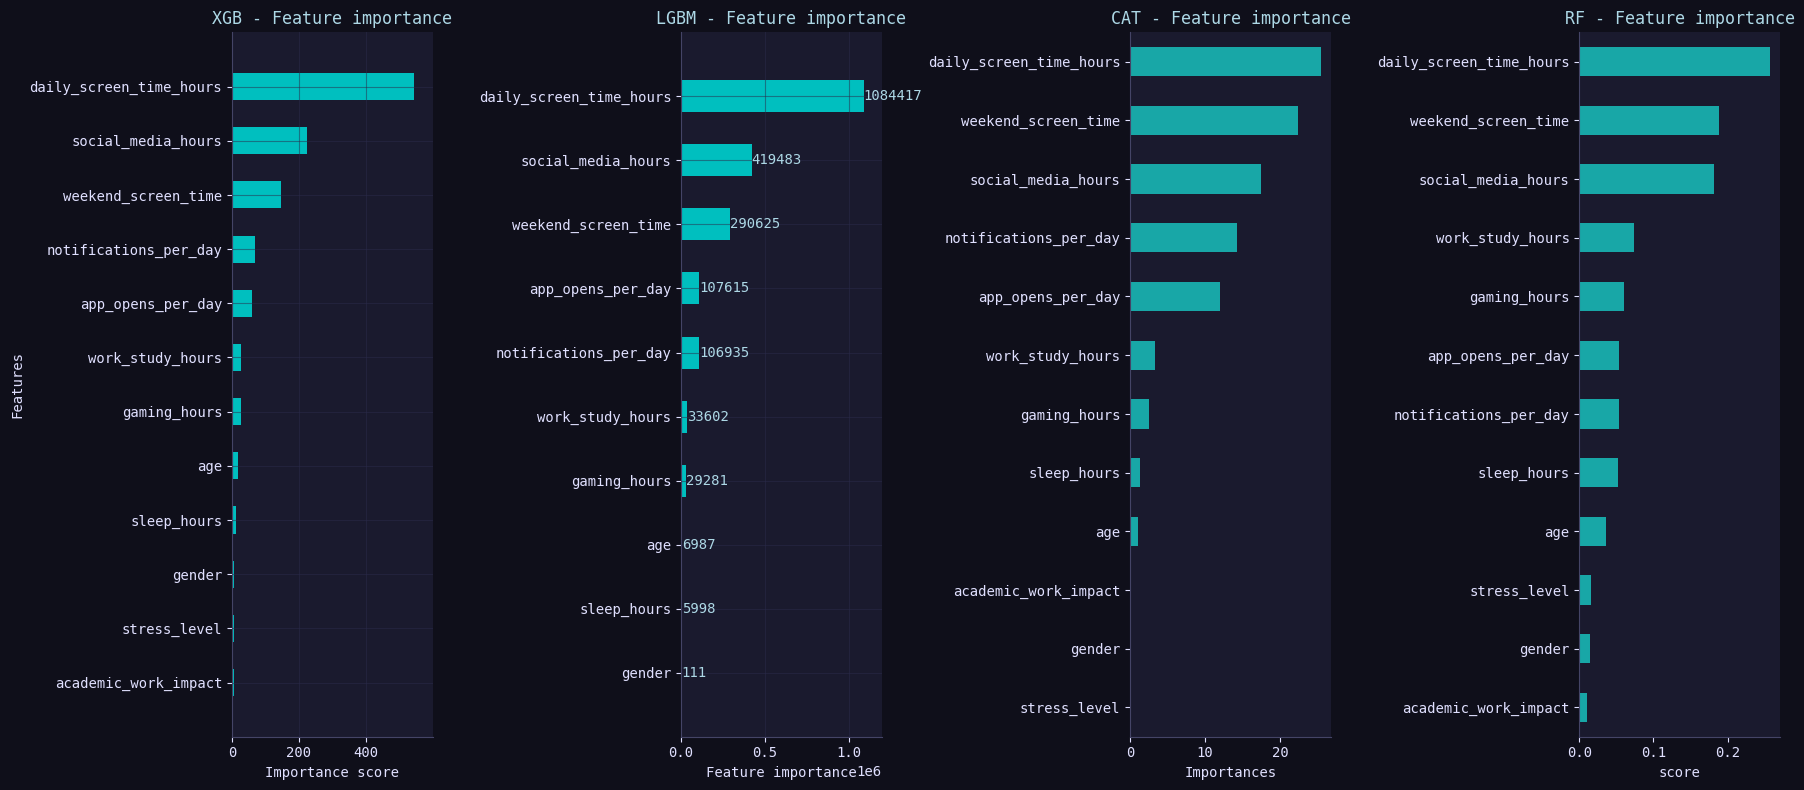

In [58]:
## -- Plot Feature Importances --
MAX = 15
fig, axs = plt.subplots(1, 4, figsize=(18, 8))

## -- XGBoost --
for k, v in TREE_MODELS.items():
    if 'xgb' in k:
        xgb.plot_importance(
            v, max_num_features=MAX,
            importance_type='gain',
            title='XGB - Feature importance',
            height=0.5, show_values=False, ax=axs[0],
        )

    ## -- LightGBM --
    elif 'lgb' in k:
        lgb.plot_importance(
            v, max_num_features=MAX,
            importance_type='gain',
            title='LGBM - Feature importance',
            height=0.5, precision=0, ax=axs[1],
        )
        axs[1].set_ylabel('')

    ## -- CatBoost --
    elif 'cat' in k:
        cat_imp_df = v.get_feature_importance(prettified=True).iloc[:MAX]
        sns.barplot(data=cat_imp_df, x='Importances', y='Feature Id', width=0.5, ax=axs[2])
        axs[2].set_title('CAT - Feature importance')
        axs[2].set_ylabel('')

    ## -- RandomForest --
    elif 'rfc' in k:
        rf_dicts = dict(zip(X_train.columns, v.feature_importances_))
        rf_imp_df = pd.DataFrame.from_dict(rf_dicts, orient='index', columns=['score'])\
                                .sort_values('score', ascending=False).iloc[:MAX]
        sns.barplot(rf_imp_df, x=rf_imp_df.score, y=rf_imp_df.index, width=0.5, ax=axs[3])
        axs[3].set_title('RF - Feature importance')
        axs[3].set_ylabel('')

    for ax in axs:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [59]:
try:
    import shap
except:
    !uv pip install -q -U shap
    import shap

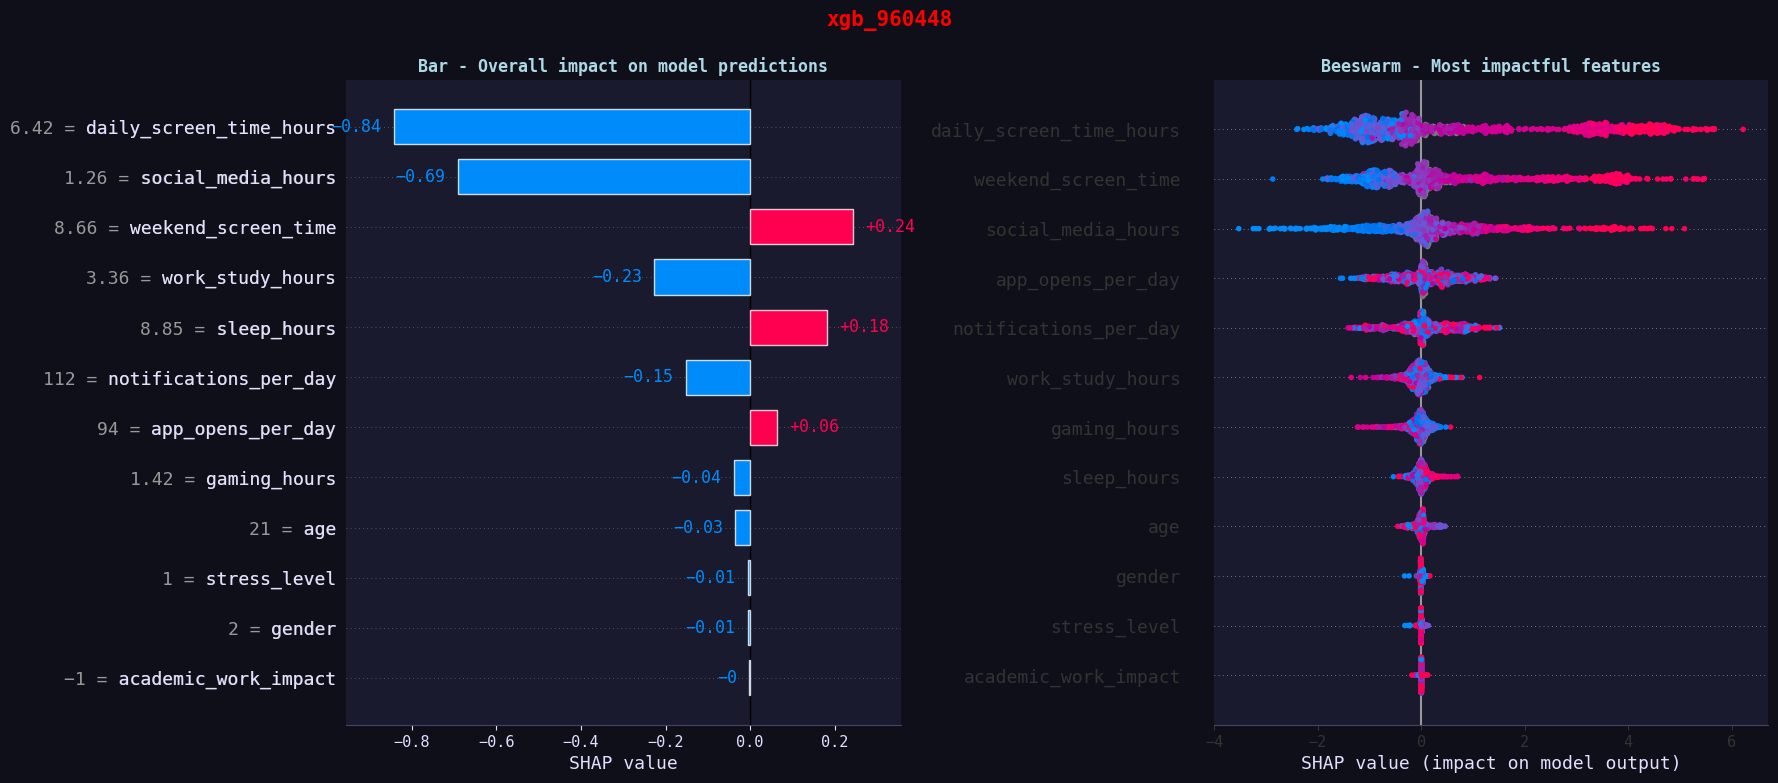

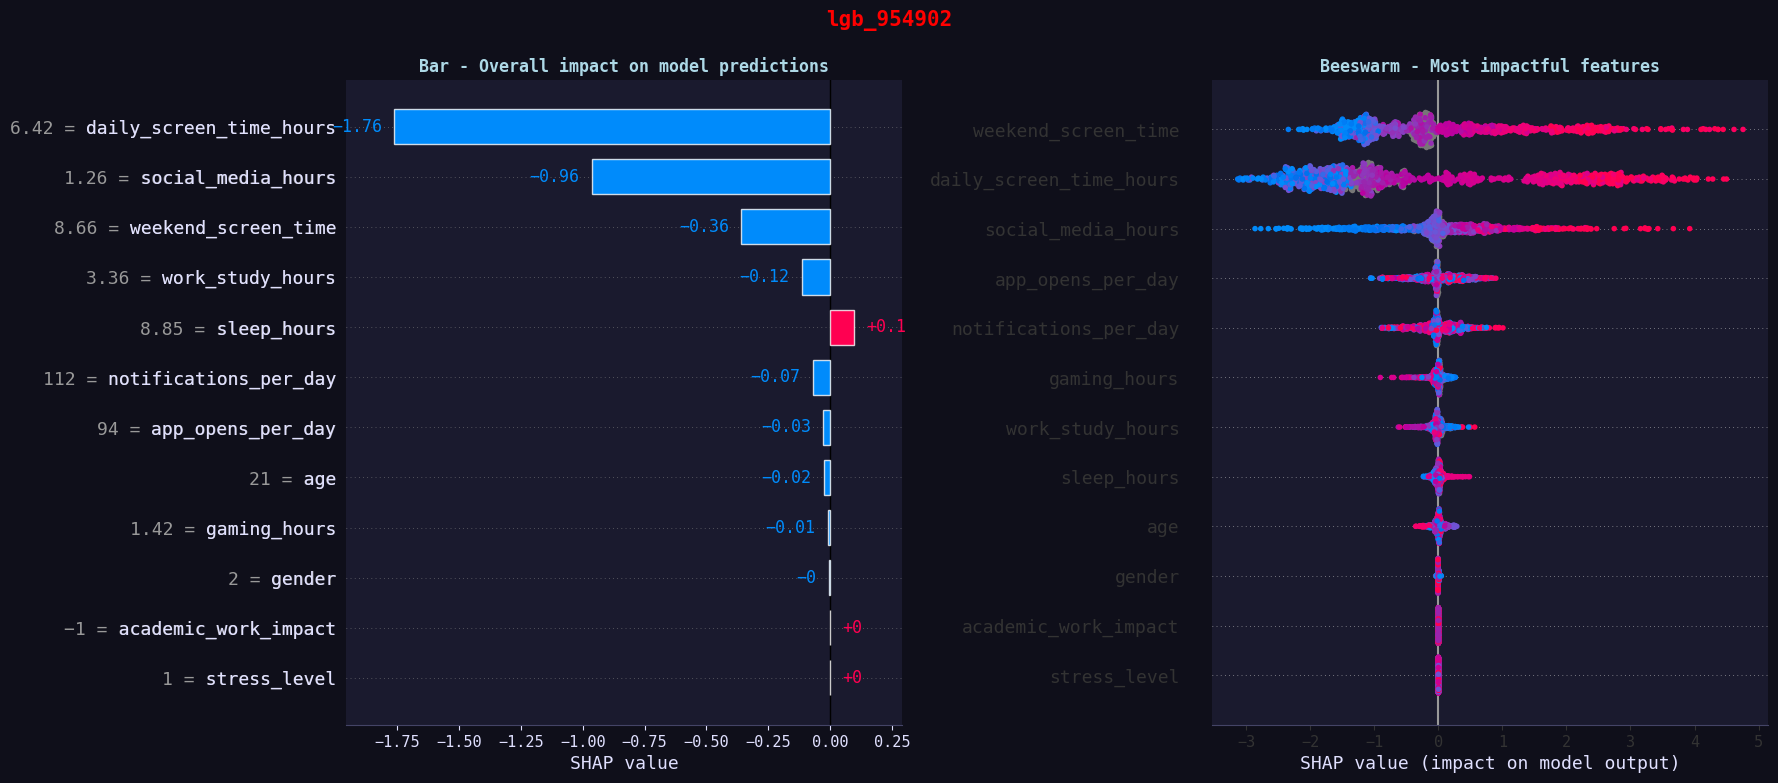

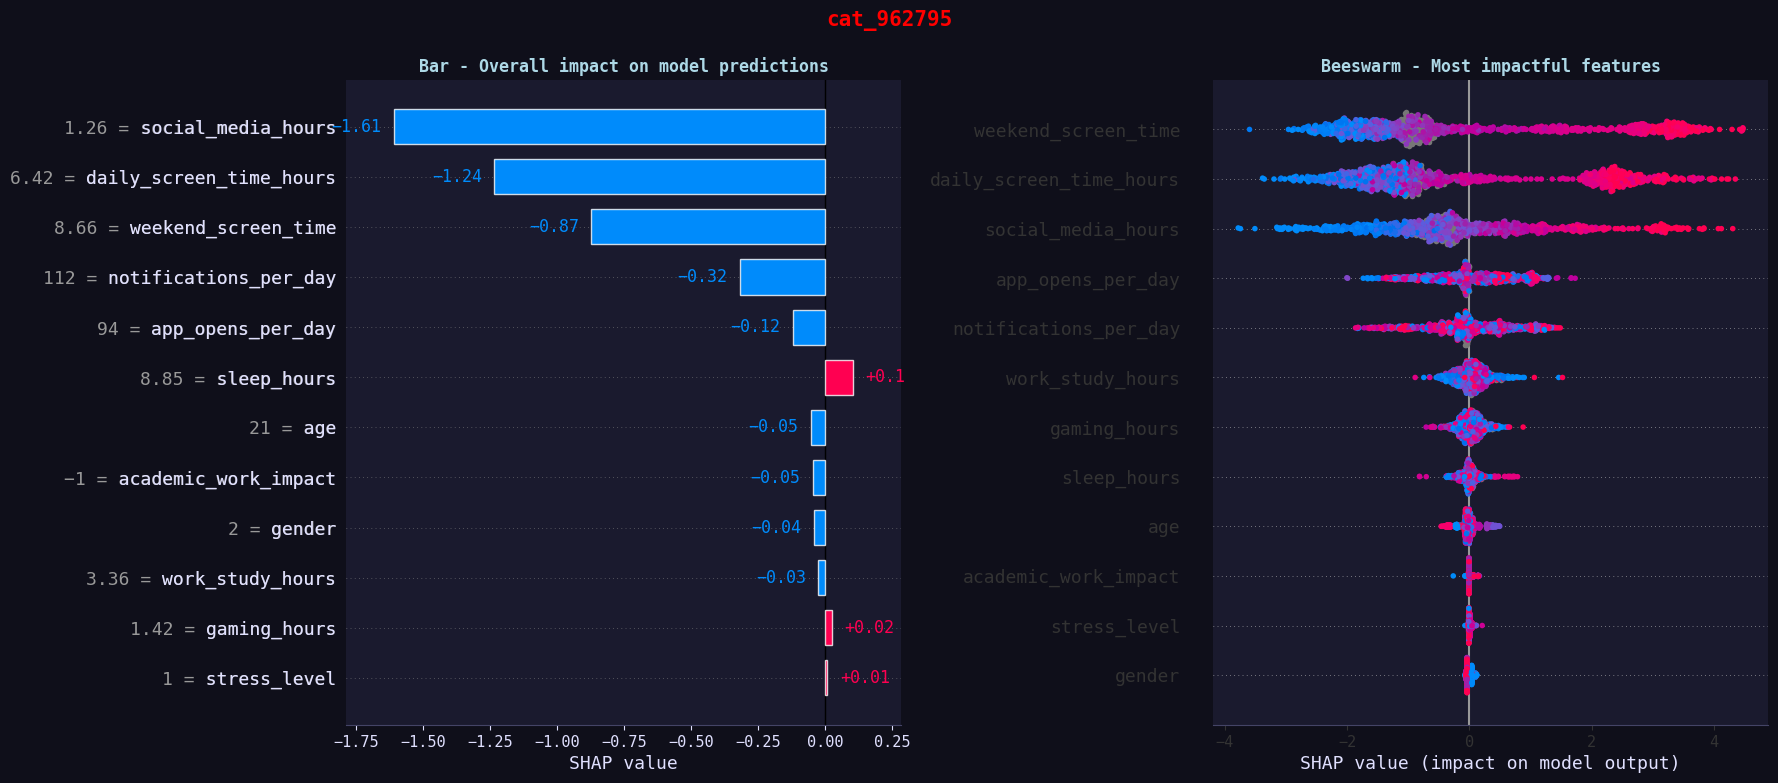

In [60]:
## -- Plot SHAP values --
MAX = 15

for i, (name, model) in enumerate(TREE_MODELS.items()):
    if 'xgb' in name or 'lgb' in name or 'cat' in name:
        explainer = shap.TreeExplainer(model)
        explanation = explainer(X_valid.iloc[:1000])

        ## -- Bar plot --
        plt.subplot(121)
        shap.plots.bar(explanation[0], max_display=MAX, show=False)
        plt.title('Bar - Overall impact on model predictions', fontweight='semibold')

        ## -- Beeswarm plot --
        plt.subplot(122)
        shap.plots.beeswarm(
            explanation, max_display=MAX, order=explanation.abs.max(0),
            plot_size=(18, 8), color_bar=False, show=False,
        )

        plt.title('Beeswarm - Most impactful features', fontweight='semibold')
        plt.suptitle(f"{name}", fontweight='bold', fontsize=15, color='r')

        plt.tight_layout(pad=1.5)
        plt.show()
        print()

## ~ LINEAR MODELS

In [61]:
train_2 = train.copy()
test_2  = test.copy()

FEATURES_2 = [c for c in train_2.columns if c not in [ID, TARGET]]
print('✓ Total Features:', len(FEATURES_2))

train_2

✓ Total Features: 12


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,NaN,No,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,1
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,1
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,1


In [62]:
# ## -- Ohe-Hot encode categoricals --
# combined = pd.concat([train_2[FEATURES], test_2[FEATURES]])
# combine_ohe = pd.get_dummies(combined, columns=CATS, dummy_na=True, dtype=float, drop_first=False)

# train_2 = pd.concat([combine_ohe[:len(train_2)], train_2[TARGET]], axis=1)
# test_2  = combine_ohe[len(train_2):]

# FEATURES_2 = [c for c in train_2.columns if c not in [ID, TARGET]]
# print('✓ Total Features:', len(FEATURES_2))

# OHE_COLS = [c for c in FEATURES_2 if c not in CATS+NUMS]
# print('✓ Total One-Hot-Features:', len(OHE_COLS))

# train_2

In [63]:
# ## -- Fill categorical --
# # train[CATS] = train[CATS].fillna('missing')
# # test[CATS]  = test[CATS].fillna('missing')
# # orig[CATS]  = orig[CATS].fillna('missing')

# ## -- Get NaN indicators --
# def appy_nan_indicator(df):
#     df1 = df.copy()
#     cols_with_nan = df1.columns[df1.isna().any()]
#     indicators = df1[cols_with_nan].isna().astype(float).add_prefix('isna_')
#     indi_cols = indicators.columns.tolist()
#     df1 = df1.join(indicators)

#     return df1, indi_cols

# train_2, INDI_COLS = appy_nan_indicator(train_2)
# test_2, _  = appy_nan_indicator(test_2)
# # orig, _  = appy_nan_indicator(orig)

# print(INDI_COLS)
# train_2

In [64]:
## -- LINEAR MODELS --
linear_models = {
    "log_": LogisticRegression(
        # max_iter=5000,
        # tol=1e-4,
        # C=0.1,
        # class_weight='balanced',
        n_jobs=-1,
        random_state=CFG["SEED"],
    ),
    "mlp_": MLPClassifier(
        # max_iter=100,
        # tol=1e-4,
        random_state=CFG["SEED"],
    ),
    "knn_": KNeighborsClassifier(
        # algorithm="auto",
        n_jobs=-1,
    ),
}

print(f"Linear Models ({len(linear_models)}): ", end="")
print(list(linear_models.keys()))

Linear Models (3): ['log_', 'mlp_', 'knn_']


In [65]:
# ## -- LINEAR MODEL TRAINER --
# model_id = 0
# name = [*linear_models.keys()][model_id]

# X = train_2[FEATURES_2].copy()
# y = train_2[TARGET].copy()

# oof_preds   = np.zeros(len(X))
# test_preds  = np.zeros(len(test_2))
# fold_scores = []

# t0 = time()
# print(f"\n[1] {name.upper()} {'█'*10} | ", end="")

# for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
#     X_train, y_train = X.iloc[train_idx], y[train_idx]
#     X_valid, y_valid = X.iloc[val_idx], y[val_idx]
#     X_test = test_2[FEATURES_2].copy()

#     if fold == 1:
#         print(X_train.shape)

#     ## ------------------------------------------------------------------------
#     # ## -- Define encoders --
#     # scaler_enc  = StandardScaler()
#     # one_h_enc   = OneHotEncoder(handle_unknown="ignore", sparse_output=False, drop="if_binary")
#     # num_imputer = IterativeImputer(max_iter=50, tol=1e-4, add_indicator=False, random_state=0)
#     # cat_imputer = SimpleImputer(strategy="constant", fill_value="MISSING", add_indicator=False)
    
#     # num_cols = X_train.columns.difference(CATS, sort=False)

#     # num_sub_pipeline = Pipeline([('sca', scaler_enc), ('imp', num_imputer)])
#     # # cat_sub_pipeline = Pipeline([('imp', cat_imputer), ('ohe', one_h_enc)])
#     # preprocessor = ColumnTransformer(
#     #     [
#     #         # ('cat_prep', cat_sub_pipeline, CATS),
#     #         ('num_prep', num_sub_pipeline, NUMS),
#     #     ],
#     #     remainder='passthrough',
#     #     n_jobs=8 if os.cpu_count() > 4 else 1,
#     #     )
#     # ## -- Create pipeline --
#     # m = LogisticRegression(
#     #     max_iter=5000,
#     #     # tol=1e-4,
#     #     # cv=5,
#     #     # scoring='roc_auc',
#     #     # class_weight='balanced',
#     #     n_jobs=64 if os.cpu_count() > 4 else 3,
#     #     random_state=CFG['SEED'],
#     # )
#     # model = Pipeline([('prep_cols', preprocessor), (name, m)]).set_output(transform='pandas')
#     # ## ------------------------------------------------------------------------
#     for col in NUMS:
#         scaler = StandardScaler()
#         X_train[col] = scaler.fit_transform(X_train[[col]], y_train)
#         X_valid[col] = scaler.transform(X_valid[[col]])
#         X_test[col]  = scaler.transform(X_test[[col]])

#     iter_imputer = IterativeImputer(max_iter=50, tol=1e-4, add_indicator=False, random_state=0)
#     X_train.loc[:, NUMS] = iter_imputer.fit_transform(X_train[NUMS])
#     X_valid.loc[:, NUMS] = iter_imputer.transform(X_valid[NUMS])
#     X_test.loc[:, NUMS]  = iter_imputer.transform(X_test[NUMS])

#     model = [*linear_models.values()][model_id]
#     model.fit(X_train, y_train)

#     # if fold == 1:
#     #     print(f"-> Total expanded features: {len(model[:-1].get_feature_names_out())}")

#     oof_preds[val_idx] = model.predict_proba(X_valid)[:, 1]
#     test_preds += model.predict_proba(X_test)[:, 1] / skf.n_splits

#     fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
#     fold_scores.append(fold_score)
#     print(f"\tFold {fold}/{skf.n_splits} Score: {fold_score:.6f}")

#     del X_train, y_train, X_valid, y_valid, X_test

# # test_preds /= skf.n_splits

# ## -- After all folds --
# overall_score = np.round(roc_auc_score(y, oof_preds), 6)

# print(f"{'-'*31}")
# print(f"OOF Score: {overall_score}")
# print(f"AVG Score: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
# print(f"{'-'*31}")

# print(f"Duration: {(time() - t0)/60:.2f} mins")

# _, axs = plt.subplots(1, 3, figsize=(18, 5)) #, width_ratios=[0.6,0.4]
# # Right: Confusion matrix (threshold = 0.5)
# pred_labels = (oof_preds >= 0.5).astype('int8')

# CalibrationDisplay.from_predictions(y, oof_preds, n_bins=10, name=name, ax=axs[0])
# axs[0].set_title(f"{name}: Calibrated predictions")

# # Left: ROC curve
# RocCurveDisplay.from_predictions(y, oof_preds, name=name, ax=axs[1])
# axs[1].set_title(f"{name}: Score = {overall_score}")
# # axs[1].grid(False)

# sns.histplot(test_preds, ax=axs[2])
# axs[2].set_title(f"{name}: Distribution")

# plt.tight_layout()
# plt.show()

# n = name + str(overall_score).split('.')[1]
# oof_final[n]     = oof_preds
# test_final[n]    = test_preds
# model_scores[n]  = overall_score
# LINEAR_MODELS[n] = model

# gc.collect()

Training Models:   0%|          | 0/3 [00:00<?, ?it/s]


[1] LOG_ ██████████ | (553095, 12)
-> Total expanded features: 29
	Fold 1/5 Score: 0.917792
	Fold 2/5 Score: 0.917730
	Fold 3/5 Score: 0.919091
	Fold 4/5 Score: 0.919466
	Fold 5/5 Score: 0.918709
-------------------------------
OOF Score: 0.918556
AVG Score: 0.918558 ± 0.000693
-------------------------------
Duration: 6.91 mins


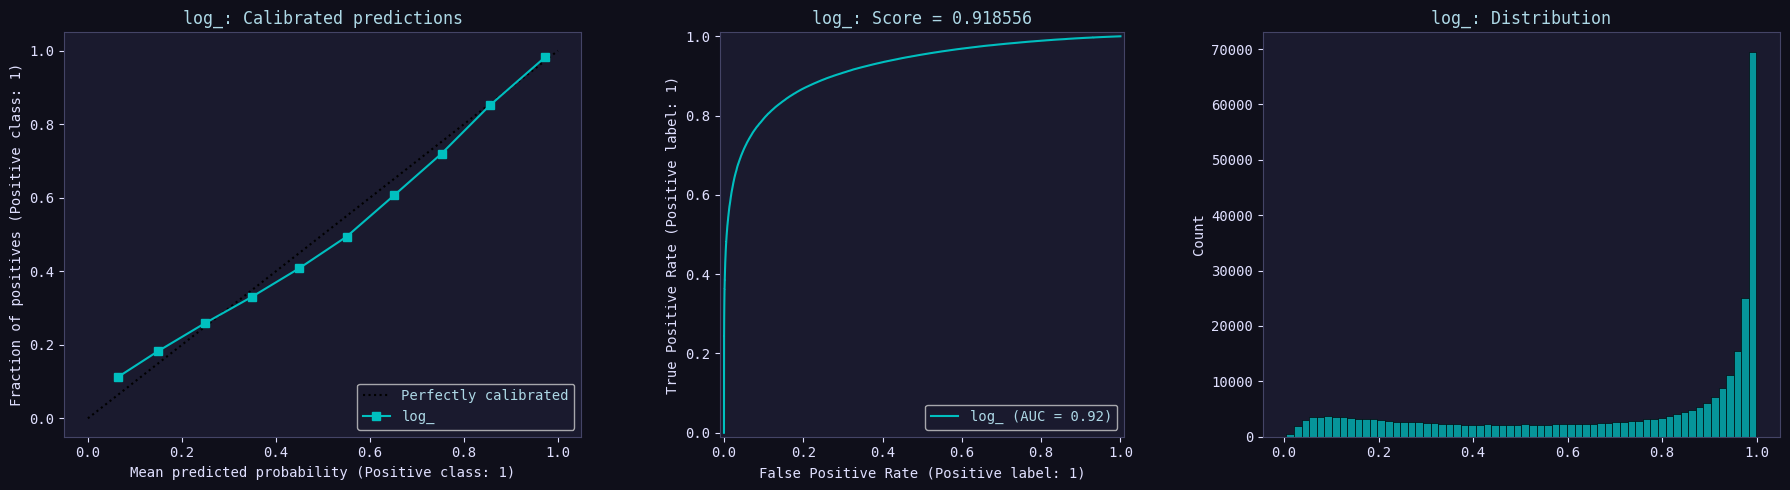


[2] MLP_ ██████████ | (553095, 12)
-> Total expanded features: 29
	Fold 1/5 Score: 0.937902
	Fold 2/5 Score: 0.938582
	Fold 3/5 Score: 0.939829
	Fold 4/5 Score: 0.940441
	Fold 5/5 Score: 0.939534
-------------------------------
OOF Score: 0.939198
AVG Score: 0.939258 ± 0.000905
-------------------------------
Duration: 22.99 mins


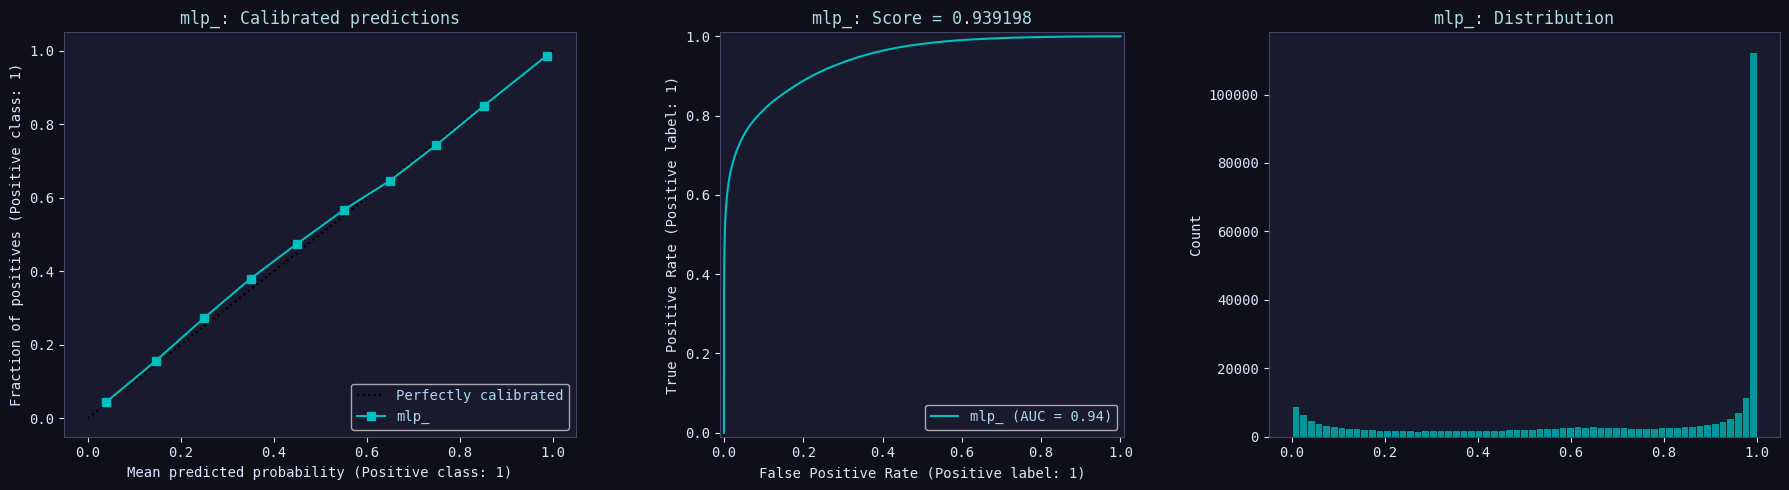


[3] KNN_ ██████████ | (553095, 12)
-> Total expanded features: 29
	Fold 1/5 Score: 0.887885
	Fold 2/5 Score: 0.889512
	Fold 3/5 Score: 0.890097
	Fold 4/5 Score: 0.890322
	Fold 5/5 Score: 0.888458
-------------------------------
OOF Score: 0.889254
AVG Score: 0.889255 ± 0.000941
-------------------------------
Duration: 67.99 mins


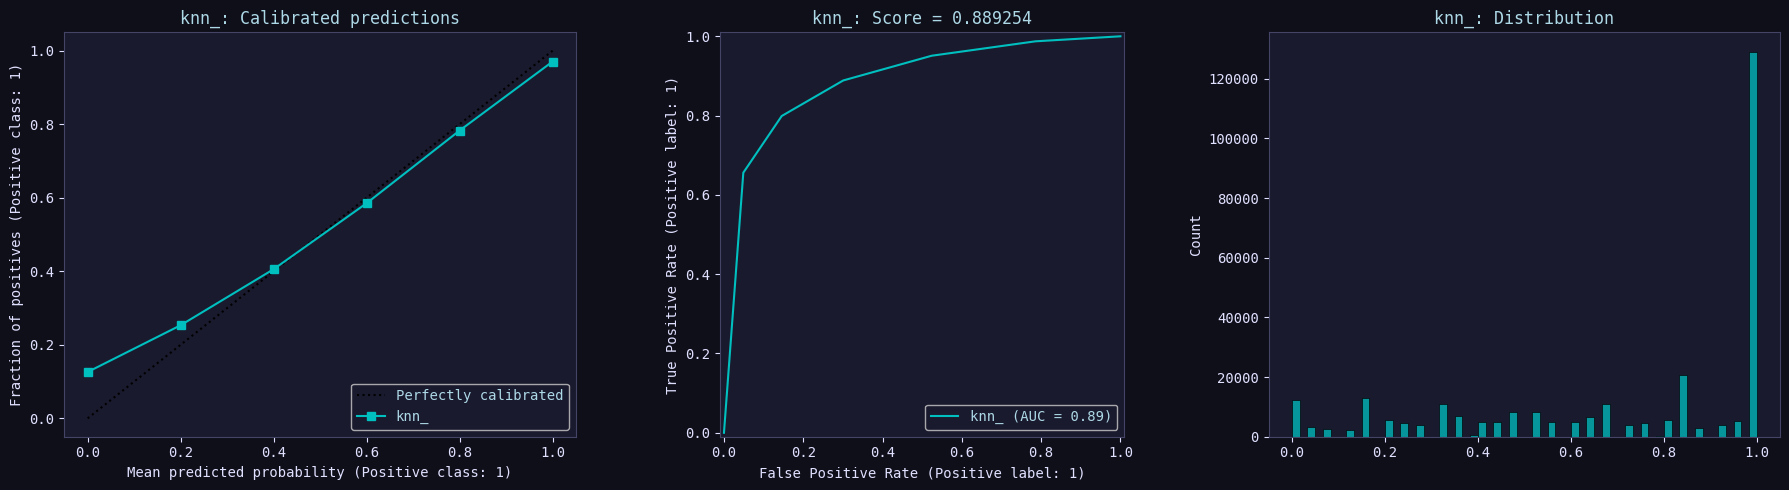

In [66]:
## -- Initiate LINEAR Training --
LINEAR_MODELS = {}

for i, (name, mod) in tqdm(enumerate(linear_models.items(), 1), total=len(linear_models), desc=desc):
    print(f"\n[{i}] {name.upper()} {'█'*10} | ", end="")
    t0 = time()

    X = train_2[FEATURES_2].copy()
    y = train_2[TARGET].copy()

    oof_preds   = np.zeros(len(X))
    test_preds  = np.zeros(len(test_2))
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_train, y_train = X.iloc[train_idx], y[train_idx]
        X_valid, y_valid = X.iloc[val_idx], y[val_idx]
        X_test = test_2[FEATURES_2].copy()

        if fold == 1:
            print(X_train.shape)

        ## -- Define encoders --
        scaler_enc  = StandardScaler()
        one_hot_enc = OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False)
        num_imputer = IterativeImputer(max_iter=50, tol=1e-4, random_state=0, add_indicator=True)
        cat_imputer = SimpleImputer(strategy="constant", fill_value="MISSING", add_indicator=False)
        
        ## ------------------------------------------------------------------------
        # num_cols = X_train.columns.difference(CATS, sort=False)

        # cat_sub_pipeline = Pipeline([('cat_imp', cat_imputer), ('one_hot', one_h_enc)])
        # num_sub_pipeline = Pipeline([("scaler", scaler_enc), ("num_imp", num_imputer)])
        # preprocessor = ColumnTransformer(
        #     [
        #         ('cat_prep', cat_sub_pipeline, CATS),
        #         ("num_prep", num_sub_pipeline, NUMS),
        #     ],
        #     remainder="passthrough",
        #     n_jobs=8 if os.cpu_count() > 4 else 2,
        #     )
        # model = Pipeline([("prep_cols", preprocessor), (name, clone(model))]).set_output(transform='pandas')
        # model.fit(X_train, y_train)
        # if fold == 1:
        #     print(f"-> Total expanded features: {len(model[:-1].get_feature_names_out())}")
        ## ------------------------------------------------------------------------
        # for col in NUMS:
        #     scaler = StandardScaler()
        #     X_train[col] = scaler.fit_transform(X_train[[col]], y_train)
        #     X_valid[col] = scaler.transform(X_valid[[col]])
        #     X_test[col]  = scaler.transform(X_test[[col]])

        # imputer = IterativeImputer(
        #     initial_strategy='most_frequent', # fill_value=None, 
        #     max_iter=20, tol=1e-4, n_nearest_features=5, random_state=0,
        #     add_indicator=False).set_output(transform='pandas')

        # # imputer = SimpleImputer(strategy="mean", add_indicator=False).set_output(transform='pandas')
        # X_train = imputer.fit_transform(X_train, y_train)
        # X_valid = imputer.transform(X_valid)
        # X_test  = imputer.transform(X_test)
        # model.fit(X_train, y_train)
        ## ------------------------------------------------------------------------
        num_transformer = make_pipeline(scaler_enc, num_imputer)
        cat_transformer = make_pipeline(cat_imputer, one_hot_enc)
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', num_transformer, NUMS),
                ('cat', cat_transformer, CATS),
            ], n_jobs=-1,
        )
        
        model = make_pipeline(preprocessor, mod)
        model.fit(X_train, y_train)
        if fold == 1:
            print(f"-> Total expanded features: {len(model[:-1].get_feature_names_out())}")
        ## ------------------------------------------------------------------------
        oof_preds[val_idx] = model.predict_proba(X_valid)[:, 1]
        test_preds += model.predict_proba(X_test)[:, 1] / skf.n_splits

        fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f"\tFold {fold}/{skf.n_splits} Score: {fold_score:.6f}")

    # test_preds /= skf.n_splits

    ## -- After all folds --
    overall_score = np.round(roc_auc_score(y, oof_preds), 6)

    print(f"{'-'*31}")
    print(f"OOF Score: {overall_score}")
    print(f"AVG Score: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print(f"{'-'*31}")
    # if 'log' in name:
    #     print(f"Best 'C': {lr_model[-1].C_}")
    print(f"Duration: {(time() - t0)/60:.2f} mins")

    _, axs = plt.subplots(1, 3, figsize=(18, 5)) #, width_ratios=[0.6,0.4]
    # Right: Confusion matrix (threshold = 0.5)
    pred_labels = (oof_preds >= 0.5).astype('int8')

    CalibrationDisplay.from_predictions(y, oof_preds, n_bins=10, name=name, ax=axs[0])
    axs[0].set_title(f"{name}: Calibrated predictions")

    # Left: ROC curve
    RocCurveDisplay.from_predictions(y, oof_preds, name=name, ax=axs[1])
    axs[1].set_title(f"{name}: Score = {overall_score}")
    # axs[1].grid(False)

    sns.histplot(test_preds, ax=axs[2])
    axs[2].set_title(f"{name}: Distribution")

    plt.tight_layout()
    plt.show()

    n = name + str(overall_score).split(".")[1]

    oof_final[n]     = oof_preds
    test_final[n]    = test_preds
    model_scores[n]  = overall_score
    LINEAR_MODELS[n] = model

    gc.collect()

In [67]:
# [1] LOG_ ██████████ | (553095, 12)
# -> Total expanded features: 29
# 	Fold 1/5 Score: 0.917792
# 	Fold 2/5 Score: 0.917730
# 	Fold 3/5 Score: 0.919091
# 	Fold 4/5 Score: 0.919466
# 	Fold 5/5 Score: 0.918709
# -------------------------------
# OOF Score: 0.918556
# AVG Score: 0.918558 ± 0.000693
# -------------------------------
# Duration: 7.21 mins

# [2] MLP_ ██████████ | (553095, 12)
# -> Total expanded features: 29
# 	Fold 1/5 Score: 0.937902
# 	Fold 2/5 Score: 0.938582
# 	Fold 3/5 Score: 0.939829
# 	Fold 4/5 Score: 0.940441
# 	Fold 5/5 Score: 0.939534
# -------------------------------
# OOF Score: 0.939198
# AVG Score: 0.939258 ± 0.000905
# -------------------------------
# Duration: 21.23 mins

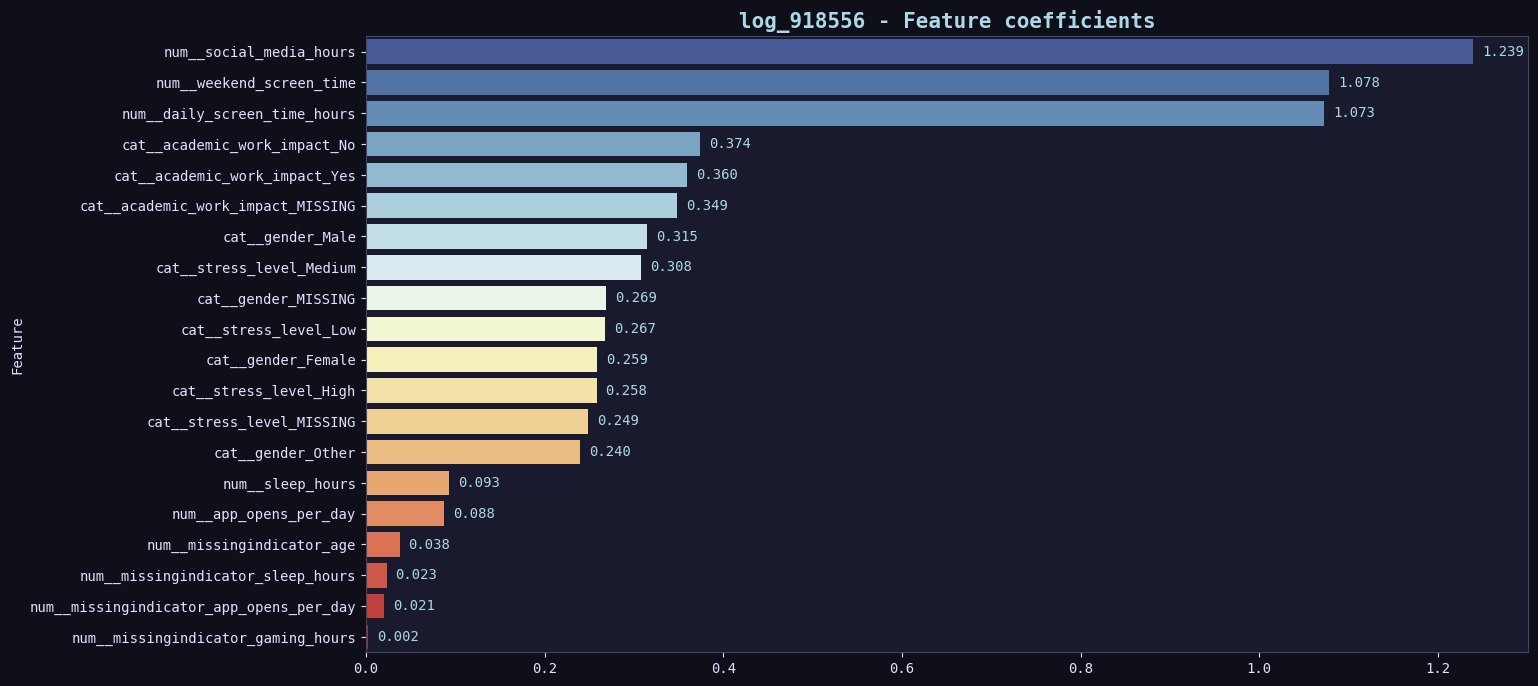

In [68]:
## -- Feature Importances: Linear Model --
for i, name in enumerate(list(LINEAR_MODELS.keys())):
    if 'log' in name:
        coef_dict = dict(zip(
            LINEAR_MODELS[name][0].get_feature_names_out(),
            LINEAR_MODELS[name][-1].coef_[0],
            # X_valid.columns.tolist(),
            # LINEAR_MODELS[name].coef_[0],
        ))

        reg_imp = pd.Series(coef_dict).sort_values(ascending=False).iloc[:20] # Top n features

        plt.figure(figsize=(15, 8))
        sns.barplot(reg_imp, orient='h', palette='RdYlBu_r')
        plt.ylabel('Feature')
        plt.title(f'{name} - Feature coefficients', fontdict={'size': 15, 'weight': 'bold'})

        for i, t in enumerate(reg_imp.values):
            plt.text(t+1e-2, i, f'{t:.3f}', va='center', )

        plt.show()

In [69]:
model_scores.sort_values(ascending=False)

cat_962795     0.962795
xgb_960448     0.960448
lgb_954902     0.954902
hist_954704    0.954704
rfc_941533     0.941533
mlp_939198     0.939198
log_918556     0.918556
knn_889254     0.889254
dtype: float64

### ~ LINEAR MODELS 2: OHE ALL FEATURES

In [70]:
# ## -- Define Models --
# linear_models2 = {
#     'log2v_': LogisticRegressionCV(
#         max_iter=10_000,
#         tol=1e-4,
#         cv=5,
#         scoring='neg_log_loss',
#         # class_weight='balanced',
#         n_jobs=os.cpu_count(),
#         random_state=CFG.SEED,
#     ),
#     'mlp2v_': MLPClassifier(
#         max_iter=100,
#         tol=1e-4,
#         random_state=CFG.SEED,
#     ),
# }

# print(f"Linear Models to train: {len(linear_models2)} -> ", end="")
# print(list(linear_models2.keys()))

In [71]:
# ## -- Initiate LINEAR Training 2 --
# LINEAR_MODELS_2 = {}

# for i, (name, model) in tqdm(enumerate(linear_models2.items()), total=len(linear_models2), desc=desc):
#     print(f"\n[{i+1}] {name} {'█'*25}")
#     tik = time()

#     oof_preds  = np.zeros(len(X))
#     test_preds = np.zeros(len(test))
#     fold_scores  = []

#     for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
#         X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
#         y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
#         X_test = test[FEATURES].copy()

#         combine = pd.concat([X_train, X_valid, X_test])
#         for c in [c for c in X_train.columns if X_train[c].dtype != np.number]:
#             combine[c] = combine[c].factorize()[0]

#         for c in CATS:
#             combine[c] = combine[c].factorize()[0]

#         X_train = combine.iloc[:len(X_train)]
#         X_valid   = combine.iloc[len(X_train):len(X_train)+len(X_valid)]
#         X_test  = combine.iloc[len(X_train)+len(X_valid):]

#         ## -- Create pipeline --
#         lr_model_2 = make_pipeline(
#             make_column_transformer(
#                 (OneHotEncoder(
#                     handle_unknown='ignore',
#                     # sparse_output=False,
#                     drop=None,
#                 ), CATS_100),
#                 remainder='passthrough',
#                 n_jobs=os.cpu_count(),
#             ),
#             StandardScaler(with_mean=False),
#             model,
#         )

#         lr_model_2.fit(X_train, y_train)

#         oof_preds[val_idx] = lr_model_2.predict_proba(X_valid)[:, 1]
#         test_preds += lr_model_2.predict_proba(X_test)[:, 1]

#         fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
#         fold_scores.append(fold_score)
#         print(f"Fold {fold+1}/{skf.n_splits} Score: {fold_score:.5f}")


#     test_preds /= skf.n_splits

#     tok = time()
#     tiktok = tok-tik

#     ## -- After all folds --
#     overall_score = np.round(roc_auc_score(y, oof_preds), 5)

#     print(f"{'-'*30}")
#     print(f"OOF Score: {overall_score}")
#     print(f"AVG Score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
#     print(f"{'-'*30}")
#     print(f"Best 'C' value: {lr_model_2[-1].C_}")
#     print(f"Time: {tiktok:.2f} secs")

#     _, axs = plt.subplots(1, 3, figsize=(18, 5))

#     CalibrationDisplay.from_predictions(y, oof_preds, n_bins=10, name=name, ax=axs[0])
#     axs[0].set_title(f"{name}: Calibrated predictions")

#     # Left: ROC-Score curve
#     RocCurveDisplay.from_predictions(y, oof_preds, name=name, ax=axs[1])
#     axs[1].set_title(f"{name} Score: {overall_score}")
#     # axs[1].grid(False)

#     sns.histplot(test_preds, ax=axs[2])
#     axs[2].set_title(f"{name} Distribution")

#     plt.tight_layout()
#     plt.show()

#     n = name + str(overall_score).split('.')[1]
#     oof_final[n]       = oof_preds
#     test_final[n]      = test_preds
#     LINEAR_MODELS_2[n] = lr_model_2
#     model_scores[n]    = overall_score

#     gc.collect()

In [72]:
# ## -- Feature Importances: Linear Model --
# for i, name in enumerate(list(LINEAR_MODELS_2.keys())):
#     if 'log' in name:
#         coef_dict = dict(
#             zip(
#                 LINEAR_MODELS_2[name][0].get_feature_names_out(),
#                 LINEAR_MODELS_2[name][-1].coef_[0]
#             )
#         )

#         reg_imp = pd.Series(coef_dict).sort_values(ascending=False).iloc[:20] # Top n features

#         plt.figure(figsize=(15, 8))
#         sns.barplot(reg_imp, orient='h', palette='RdYlBu')
#         plt.ylabel('Feature')
#         plt.title(f'{name} - Feature importance', fontdict={'size': 15, 'weight': 'bold'})

#         for i, t in enumerate(reg_imp.values):
#             plt.text(t+1e-2, i, f'{t:.3f}', va='center', )

#         plt.show()

In [73]:
# ## -- Define Models --
# linear_models3 = {
#     'log3_': LogisticRegressionCV(
#         max_iter=1000,
#         tol=1e-4,
#         cv=5,
#         scoring='neg_log_loss',
#         # class_weight='balanced',
#         n_jobs=os.cpu_count(),
#         random_state=CFG.SEED,
#     ),
# }

# print(f"Linear Models to train: {len(linear_models3)} -> ", end="")
# print(list(linear_models3.keys()))

In [74]:
# ## -- Initiate LINEAR Training 2 --
# LINEAR_MODELS_3 = {}

# for i, (name, model) in tqdm(
#     enumerate(linear_models3.items()),
#     total=len(linear_models3),
#     desc='Training Models.'
# ):
#     print(f"\n[{i+1}] {name} {'█'*25}")
#     tik = time()

#     oof_preds  = np.zeros(len(X))
#     test_preds = np.zeros(len(test))
#     fold_scores = []

#     for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
#         X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
#         y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
#         X_test = test[FEATURES].copy()

#         ## -- Create pipeline --
#         lr_model_3 = make_pipeline(
#             make_column_transformer(
#                 (OneHotEncoder(
#                     handle_unknown='ignore',
#                     # sparse_output=False,
#                     # drop='first',
#                 ), FEATURES),
#                 remainder='passthrough',
#                 n_jobs=os.cpu_count(),
#             ),
#             StandardScaler(with_mean=False),
#             model,
#         )

#         lr_model_3.fit(X_train, y_train)

#         oof_preds[val_idx] = lr_model_3.predict_proba(X_valid)[:,1]
#         fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
#         fold_scores.append(fold_score)
#         print(f"Fold {fold+1}/{skf.n_splits} Score: {fold_score:.5f}")

#         test_preds += lr_model_3.predict_proba(X_test)[:,1]

#     test_preds /= skf.n_splits

#     tok = time()
#     tiktok = tok-tik

#     ## -- After all folds --
#     overall_score = np.round(roc_auc_score(y, oof_preds), 5)

#     print(f"{'-'*30}")
#     print(f"OOF Score: {overall_score}")
#     print(f"AVG Score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
#     print(f"{'-'*30}")
#     print(f"Best 'C': {lr_model_3[-1].C_}")

#     print(f"Time: {tiktok:.2f} secs")

#     _, axs = plt.subplots(1, 3, figsize=(18, 5))

#     CalibrationDisplay.from_predictions(y, oof_preds, n_bins=10, name=name, ax=axs[0])
#     axs[0].set_title(f"{name}: Calibrated predictions")

#     # Left: ROC curve
#     RocCurveDisplay.from_predictions(y, oof_preds, name=name, ax=axs[1])
#     axs[1].set_title(f"{name} Score: {overall_score}")
#     # axs[1].grid(False)

#     sns.histplot(test_preds, ax=axs[2])
#     axs[2].set_title(f"{name} Distribution")

#     plt.tight_layout()
#     plt.show()

#     n = name + str(overall_score).split('.')[1]
#     oof_final[n]       = oof_preds
#     test_final[n]      = test_preds
#     LINEAR_MODELS_3[n] = lr_model_3
#     model_scores[n]    = overall_score

#     gc.collect()

In [75]:
# ## -- Feature Importances: Linear Model --
# for i, name in enumerate(list(LINEAR_MODELS_3.keys())):
#     if 'log' in name:
#         coef_dict = dict(
#             zip(
#                 LINEAR_MODELS_3[name][0].get_feature_names_out(),
#                 LINEAR_MODELS_3[name][-1].coef_[0]
#             )
#         )
#     else:
#         coef_dict = dict(
#             zip(
#                 LINEAR_MODELS_3[name][0].get_feature_names_out(),
#                 LINEAR_MODELS_3[name][-1].coef_
#             )
#         )

#         reg_imp = pd.Series(coef_dict).sort_values(ascending=False).iloc[:20] # Top n features

#         plt.figure(figsize=(15, 8))
#         sns.barplot(reg_imp, orient='h', palette='RdYlBu')
#         plt.ylabel('Feature')
#         plt.title(f'{name} - Feature importance', fontdict={'size': 15, 'weight': 'bold'})

#         for i, t in enumerate(reg_imp.values):
#             plt.text(t+1e-2, i, f'{t:.3f}', va='center', )

#         plt.show()

# ~ STACKING

Stacking models: 8
Fold 1/5 | Score: 0.96259
Fold 2/5 | Score: 0.96284
Fold 3/5 | Score: 0.96314
Fold 4/5 | Score: 0.96364
Fold 5/5 | Score: 0.96291
|------------------------------
| OOF Score: 0.96302
| AVG Score: 0.96302 ± 0.00035
|------------------------------
| Duration: 1.25 secs


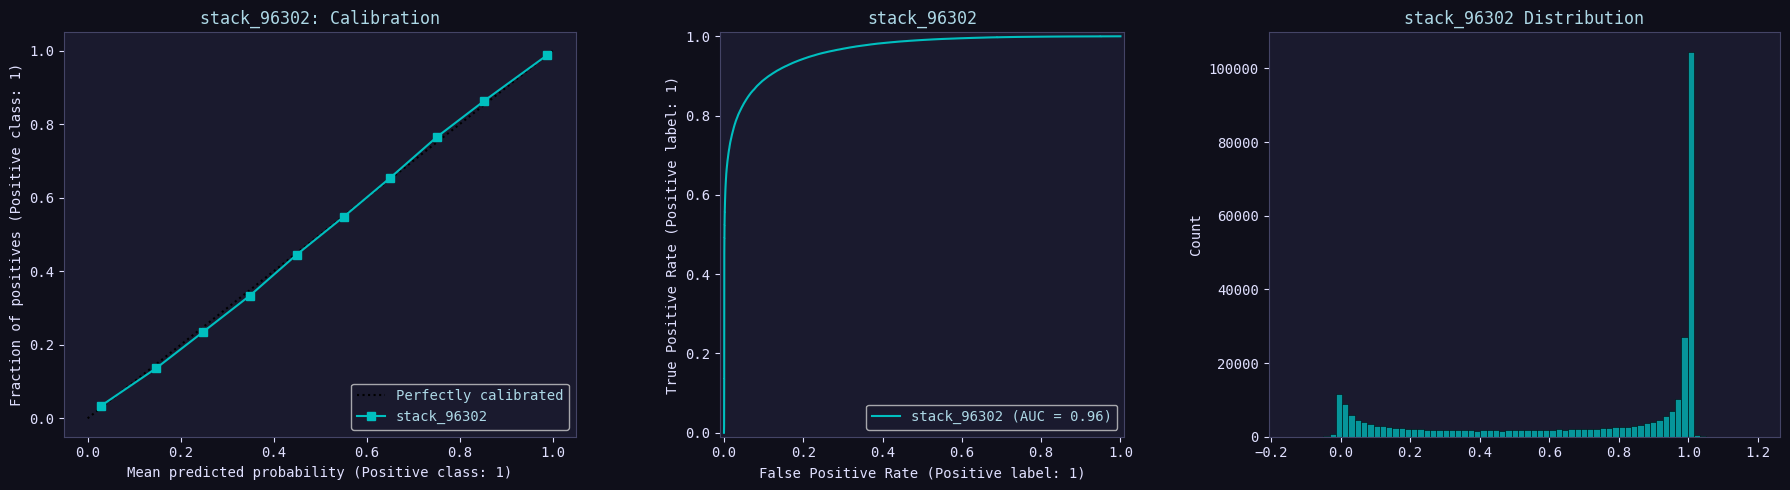

In [76]:
## -- Define Training Parameters --
stack_oof_preds  = np.zeros(len(oof_final))
stack_test_preds = np.zeros(len(test_final))
fold_scores = []

X = oof_final.copy()
y = train[TARGET]

## -- Initiate Training --
t0 = time()
print(f"Stacking models: {X.shape[1]}")
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f"Fold {fold}/{skf.n_splits} | ", end='')
    
    X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
    X_test = test_final.copy()

    meta_model = Ridge(alpha=1.0, random_state=0)
    meta_model.fit(X_train, y_train)
    
    stack_oof_preds[val_idx] = meta_model.predict(X_valid)
    oof_score = np.round(roc_auc_score(y_valid, meta_model.predict(X_valid)), 5)
    
    fold_scores.append(oof_score)
    print(f"Score: {oof_score}")

    stack_test_preds += meta_model.predict(X_test) / skf.n_splits

## -- After all folds --
stack_score = np.round(roc_auc_score(y, stack_oof_preds), 5)
stack_name = 'stack_' + str(stack_score).split('.')[1]

oof_final[stack_name]    = stack_oof_preds
test_final[stack_name]   = stack_test_preds
model_scores[stack_name] = stack_score

print(f"|{'-'*30}")
print(f"| OOF Score: {stack_score}")
print(f"| AVG Score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
print(f"|{'-'*30}")
print(f"| Duration: {(time()-t0):.2f} secs")

_, axs = plt.subplots(1, 3, figsize=(18, 5))

CalibrationDisplay.from_predictions(y, stack_oof_preds.clip(0, 1), n_bins=10, name=stack_name, ax=axs[0])
axs[0].set_title(f"{stack_name}: Calibration")

# Left: ROC curve
RocCurveDisplay.from_predictions(y, stack_oof_preds, name=stack_name, ax=axs[1])
axs[1].set_title(f"{stack_name}")
# axs[1].grid(False)

sns.histplot(stack_test_preds, ax=axs[2])
axs[2].set_title(f"{stack_name} Distribution")

plt.tight_layout()
plt.show()

# ~ HILLCLIMB

In [77]:
try:
    from hillclimbers import climb_hill, partial
except:
    !uv pip install -q -U hillclimbers
    from hillclimbers import climb_hill, partial

In [78]:
%%time

## -- Run hillclimber --
hc_test_preds, hc_oof_preds = climb_hill(
        train=train,
        target=TARGET,
        oof_pred_df=oof_final.drop(columns=[stack_name]),
        test_pred_df=test_final.drop(columns=[stack_name]),
        eval_metric=partial(roc_auc_score),
        objective="maximize",
        return_oof_preds=True,
        negative_weights=True,
        precision=0.01,
        plot_hill=True,
        plot_hist=False,
)

   /\  
  /__\  hillclimbers 
 /    \
/______\ 

Models to be ensembled | (8 total): 

cat_962795:  0.96279 (best solo model)
xgb_960448:  0.96045
lgb_954902:  0.95490
hist_954704: 0.95470
rfc_941533:  0.94153
mlp_939198:  0.93920
log_918556:  0.91856
knn_889254:  0.88925

[Data preparation completed successfully] - [Initiate hill climbing] 

Iteration: 1 | Model added: hist_954704 | Best weight: -0.15 | Best roc_auc_score: 0.96295
Iteration: 2 | Model added: xgb_960448 | Best weight: 0.20 | Best roc_auc_score: 0.96311
Iteration: 3 | Model added: lgb_954902 | Best weight: -0.12 | Best roc_auc_score: 0.96321
Iteration: 4 | Model added: mlp_939198 | Best weight: 0.01 | Best roc_auc_score: 0.96321
Iteration: 5 | Model added: knn_889254 | Best weight: -0.01 | Best roc_auc_score: 0.96321
Iteration: 6 | Model added: rfc_941533 | Best weight: 0.01 | Best roc_auc_score: 0.96322


CPU times: user 10min 21s, sys: 1.87 s, total: 10min 23s
Wall time: 10min 23s


In [79]:
hc_score = np.round(roc_auc_score(y, hc_oof_preds), 5)
hc_name = 'hill_' + str(hc_score).split('.')[1]

oof_final[hc_name]  = hc_oof_preds
test_final[hc_name] = hc_test_preds

model_scores[hc_name] = hc_score
model_scores.sort_values(inplace=True)
model_scores

knn_889254     0.889254
log_918556     0.918556
mlp_939198     0.939198
rfc_941533     0.941533
hist_954704    0.954704
lgb_954902     0.954902
xgb_960448     0.960448
cat_962795     0.962795
stack_96302    0.963020
hill_96322     0.963220
dtype: float64

,xgb_960448,lgb_954902,cat_962795,rfc_941533,hist_954704,log_918556,mlp_939198,knn_889254,stack_96302,hill_96322
0,0.843310,0.802104,0.849571,0.63,0.758197,0.640170,0.588926,0.4,0.883183,0.865627
1,0.038319,0.078133,0.040705,0.09,0.080940,0.340158,0.092151,0.4,0.009561,0.027827
2,0.393804,0.465878,0.449288,0.31,0.467459,0.374322,0.295689,0.0,0.425217,0.434117
3,0.382039,0.333688,0.258956,0.50,0.345998,0.480437,0.221028,0.4,0.258456,0.266426
4,0.999908,0.999580,0.999792,1.00,0.999813,0.980901,0.999995,1.0,1.000326,0.999842


,xgb_960448,lgb_954902,cat_962795,rfc_941533,hist_954704,log_918556,mlp_939198,knn_889254,stack_96302,hill_96322
0,0.998750,0.996985,0.999332,0.994,0.996671,0.948299,0.989214,0.84,1.004091,1.001258
1,0.933783,0.960547,0.942565,0.848,0.943556,0.877985,0.884848,0.68,0.941941,0.939427
2,0.941250,0.954297,0.935687,0.994,0.957091,0.972546,0.983535,0.96,0.928851,0.932683
3,0.984366,0.968274,0.987234,0.976,0.970843,0.933066,0.971080,1.00,0.994225,0.990631
4,0.996467,0.988814,0.997999,1.000,0.990293,0.988265,0.991284,1.00,1.000366,0.999709


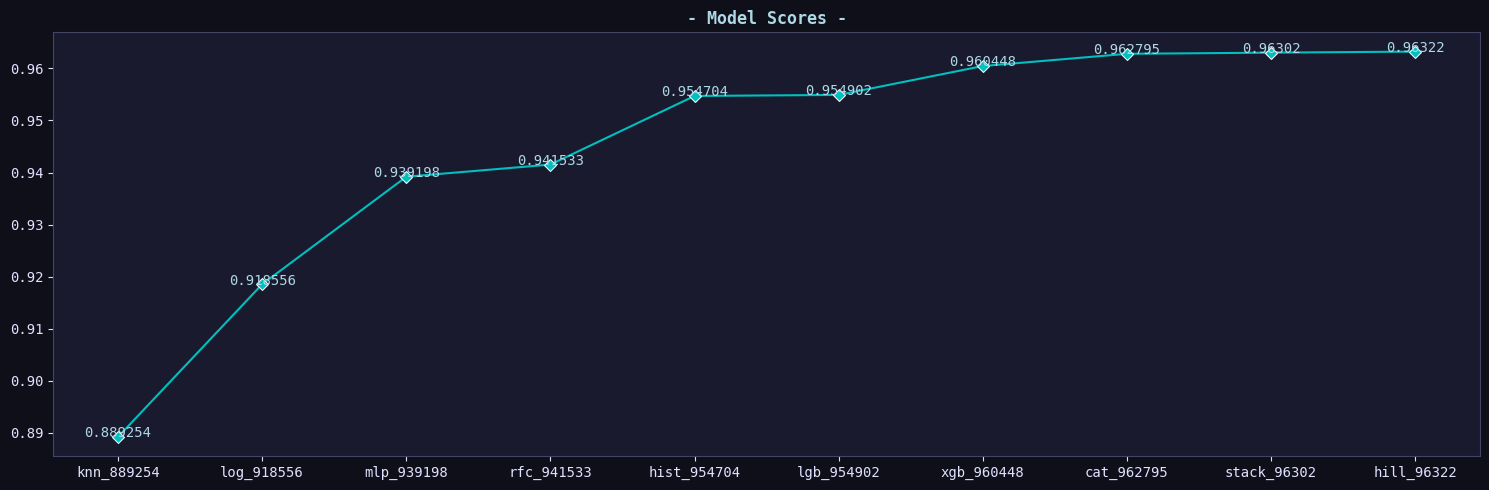

In [80]:
display(oof_final.head())
print()
display(test_final.head())
print()
plt.figure(figsize=(15, 5))
sns.lineplot(model_scores.sort_values(), marker='D')
plt.tick_params(axis='x')
plt.title('- Model Scores -', fontweight='bold')

for i, s in enumerate(model_scores.values):
    plt.text(model_scores.index[i], s+1e-3, s, va='center_baseline', ha='center')

plt.tight_layout()
plt.show()

# SUBMISSION

In [81]:
## -- Export stacking --
s_score = str(stack_score).split('.')[1]
s_oof = oof_final[stack_name].to_numpy().ravel()
s_test = test_final[stack_name].to_numpy().ravel()

stack_oof  = f"oof_BASE_stack_{s_score}.npy"
stack_pred = f"test_BASE_stack_{s_score}.npy"

np.save(stack_oof, s_oof)
np.save(stack_pred, s_test)

print(stack_oof, stack_pred)

oof_BASE_stack_96302.npy test_BASE_stack_96302.npy


In [82]:
## -- Export hillclimb --
h_score = str(hc_score).split('.')[1]
h_oof = oof_final[hc_name].to_numpy().ravel()
h_test = test_final[hc_name].to_numpy().ravel()

hill_oof  = f"oof_BASE_hill_{h_score}.npy"
hill_pred = f"test_BASE_hill_{h_score}.npy"

np.save(hill_oof, h_oof)
np.save(hill_pred, h_test)

print(hill_oof, hill_pred)

oof_BASE_hill_96322.npy test_BASE_hill_96322.npy


In [83]:
## -- Create Submission files --
for i, c in enumerate(test_final.columns):
    submit[TARGET] = test_final[c].values.ravel()
    submit.to_csv(f"submit_BASE_{c}.csv", index=False)
    print(f"--> submit_BASE_{c}.csv file saved!")

--> submit_BASE_xgb_960448.csv file saved!
--> submit_BASE_lgb_954902.csv file saved!
--> submit_BASE_cat_962795.csv file saved!
--> submit_BASE_rfc_941533.csv file saved!
--> submit_BASE_hist_954704.csv file saved!
--> submit_BASE_log_918556.csv file saved!
--> submit_BASE_mlp_939198.csv file saved!
--> submit_BASE_knn_889254.csv file saved!
--> submit_BASE_stack_96302.csv file saved!
--> submit_BASE_hill_96322.csv file saved!
